# Exploratory Data Analysis


## 1. Setup and Data Loading


In [447]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')


In [448]:
# Load the dataset
data = pd.read_json("data/energy_features_dataset.jsonl", lines=True)

## 2. Dataset Overview


In [449]:
# Display basic dataset information
data.info()
print(f"Shape: {data.shape}")
print(f"Memory: {data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20709 entries, 0 to 20708
Data columns (total 63 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   prompt                           20709 non-null  object        
 1   model                            20709 non-null  object        
 2   timestamp                        20709 non-null  datetime64[ns]
 3   duration                         20709 non-null  float64       
 4   time_to_first_token              20709 non-null  float64       
 5   prompt_tokens                    20709 non-null  int64         
 6   completion_tokens                20709 non-null  int64         
 7   total_tokens                     20709 non-null  int64         
 8   tokens_per_second                20709 non-null  float64       
 9   energy_consumed_wh               20709 non-null  float64       
 10  response                         20709 non-null  object   

In [450]:
# Check for missing values and data quality
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

print(f"Missing values: {missing_df[missing_df['Missing Count'] > 0].shape[0]} features")
print(f"Duplicates: {data.duplicated().sum()}")
print(f"Models: {data['model'].nunique()}")
data['model'].value_counts()


Missing values: 0 features
Duplicates: 0
Models: 3


model
mistral-large-latest      6904
llama-3.1-8b-instant      6903
gpt-4o-mini-2024-07-18    6902
Name: count, dtype: int64

In [451]:
# Display comprehensive summary statistics
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols].describe()


,duration,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,tokens_per_second,energy_consumed_wh,syntactic_tree_depth,clause_count,flesch_kincaid_grade,...,special_char_ratio,response_length_chars,response_length_words,response_efficiency,response_speed,has_code,has_urls,has_emails,has_numbers,has_quotes
count,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,...,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000
mean,1.410409,1.407245,83.428992,45.168574,128.597566,152.426790,0.034287,5.563282,6.738809,7.772531,...,0.040843,202.238640,32.107007,4776.449253,35.658149,0.254962,0.004056,0.000290,0.454585,0.312763
std,2.678725,2.670026,118.680900,11.942494,118.146595,182.004568,0.132695,3.049273,11.922437,7.258165,...,0.065539,65.792528,10.305763,7807.719819,25.469997,0.435850,0.063561,0.017019,0.497945,0.463630
min,0.270000,0.271000,8.000000,1.000000,13.000000,1.400000,0.000100,1.000000,0.000000,-2.620000,...,0.000000,1.000000,1.000000,0.694830,0.010039,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.700000,0.699000,20.000000,50.000000,68.000000,50.900000,0.004800,3.000000,1.000000,3.890270,...,0.016129,182.000000,29.000000,1335.504886,18.867925,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.070000,1.069000,44.000000,50.000000,92.000000,85.100000,0.008400,5.000000,2.000000,6.960000,...,0.028721,218.000000,35.000000,3474.576271,28.985507,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.510000,1.511000,79.000000,50.000000,124.000000,206.000000,0.019700,7.000000,6.000000,10.315634,...,0.047619,244.000000,39.000000,6406.250000,42.553191,1.000000,0.000000,0.000000,1.000000,1.000000
max,298.840000,298.836000,1721.000000,50.000000,1771.000000,2900.400000,4.165300,73.000000,102.000000,184.705641,...,0.895062,818.000000,49.000000,450000.000000,128.571429,1.000000,1.000000,1.000000,1.000000,1.000000


In [452]:
# Display first few rows and sample data
data.head()


,prompt,model,timestamp,duration,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,tokens_per_second,energy_consumed_wh,...,special_char_ratio,response_length_chars,response_length_words,response_efficiency,response_speed,has_code,has_urls,has_emails,has_numbers,has_quotes
0,how can identity protection services help prot...,gpt-4o-mini-2024-07-18,2025-10-19 20:18:09,2.03,2.029,18,50,68,33.5,0.0150,...,0.000000,296,41,2733.333333,20.197044,0,0,0,0,0
1,how can identity protection services help prot...,llama-3.1-8b-instant,2025-10-19 20:18:16,0.43,0.427,46,50,96,224.5,0.0062,...,0.000000,263,37,5967.741935,86.046512,0,0,0,0,0
2,how can identity protection services help prot...,mistral-large-latest,2025-10-19 20:18:24,1.44,1.435,14,50,64,44.5,0.0096,...,0.000000,277,41,4270.833333,28.472222,0,0,0,0,0
3,Beside OFAC's selective sanction that target t...,gpt-4o-mini-2024-07-18,2025-10-19 20:22:13,1.34,1.337,52,50,102,76.3,0.0113,...,0.026432,280,41,3628.318584,30.597015,0,0,0,0,1
4,Beside OFAC's selective sanction that target t...,llama-3.1-8b-instant,2025-10-19 20:22:18,0.45,0.447,80,50,130,290.3,0.0019,...,0.026432,311,43,22631.578947,95.555556,0,0,0,0,1


## 3. Energy Consumption Analysis


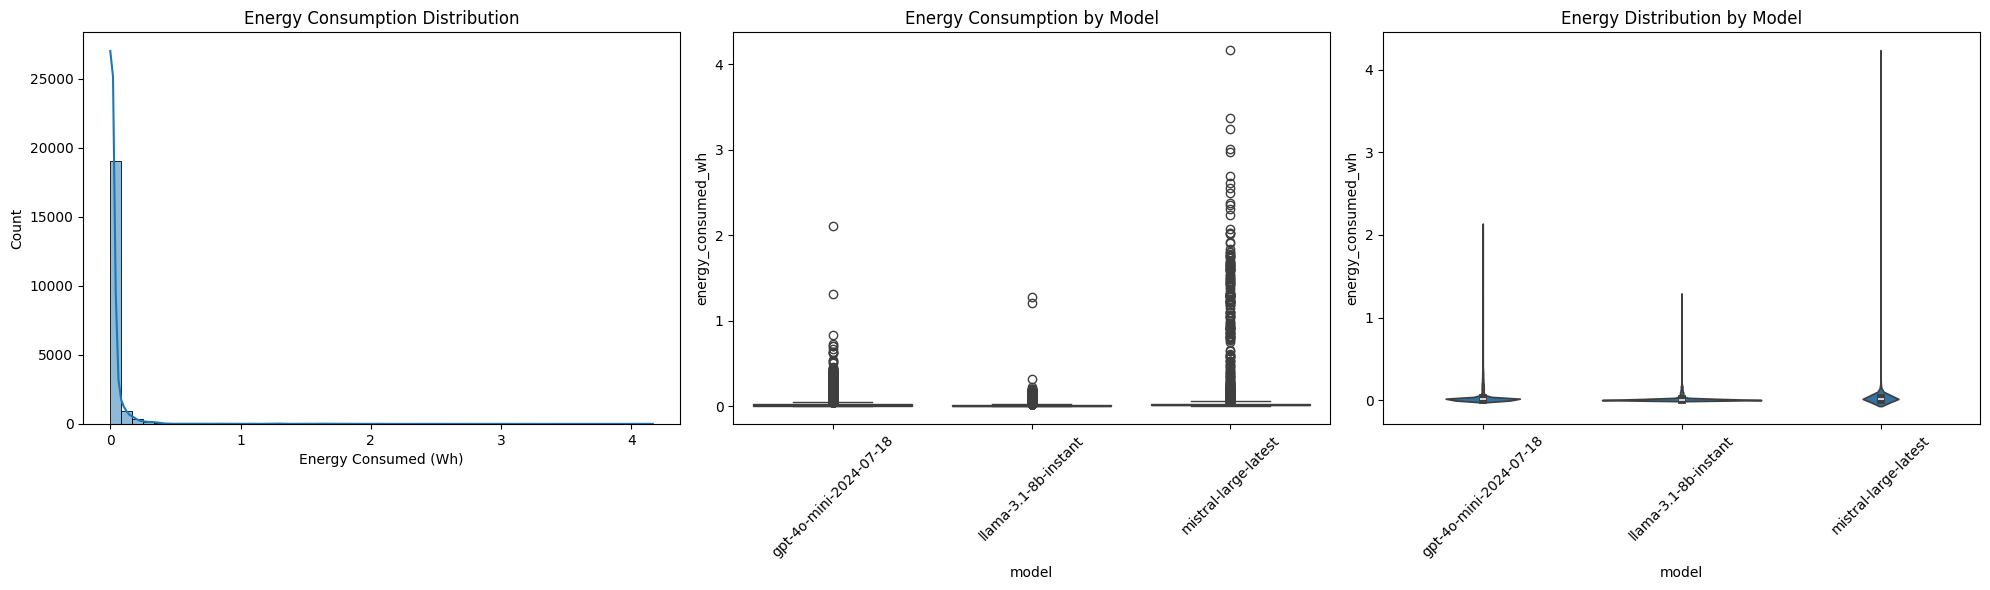

In [453]:
# Analyze energy consumption distribution
data["energy_consumed_wh"].describe()

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.histplot(data=data, x="energy_consumed_wh", bins=50, kde=True)
plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Consumed (Wh)")

plt.subplot(1, 3, 2)
sns.boxplot(data=data, x="model", y="energy_consumed_wh")
plt.title("Energy Consumption by Model")
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.violinplot(data=data, x="model", y="energy_consumed_wh")
plt.title("Energy Distribution by Model")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


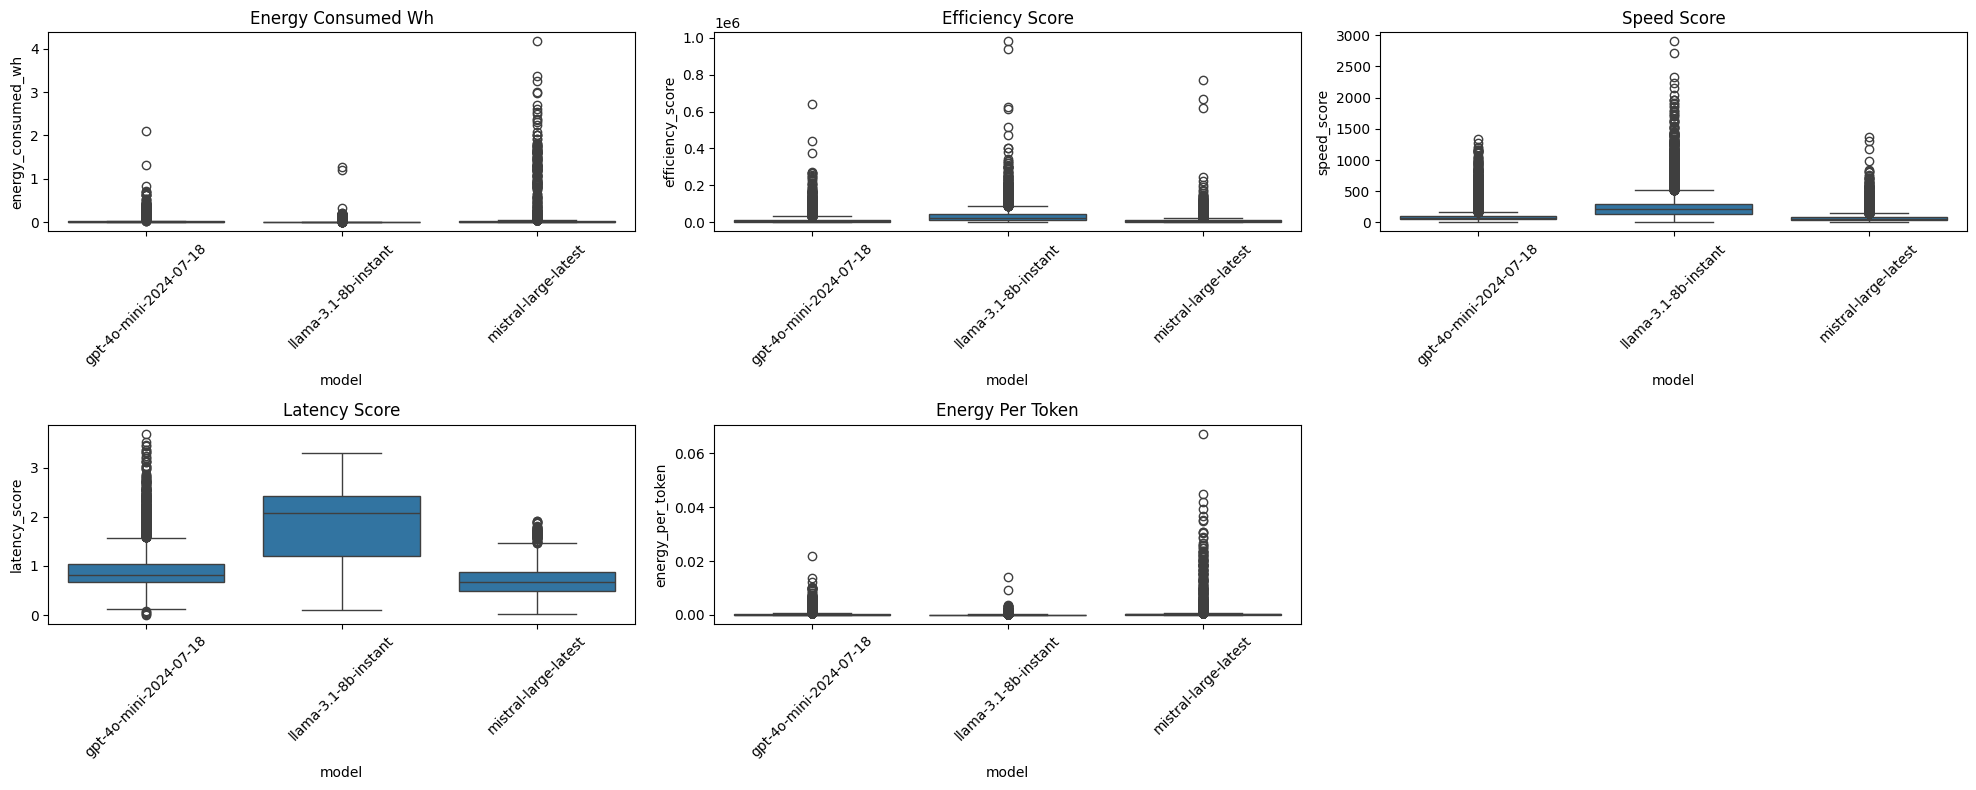

In [454]:
# Analyze performance metrics and efficiency
if 'efficiency_score' not in data.columns:
    data['efficiency_score'] = data['total_tokens'] / data['energy_consumed_wh']
if 'speed_score' not in data.columns:
    data['speed_score'] = data['tokens_per_second']
if 'latency_score' not in data.columns:
    data['latency_score'] = 1 / data['time_to_first_token']

performance_metrics = ['energy_consumed_wh', 'efficiency_score', 'speed_score', 'latency_score', 'energy_per_token']
data[performance_metrics].describe()

plt.figure(figsize=(20, 8))
for i, metric in enumerate(performance_metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=data, x="model", y=metric)
    plt.title(f"{metric.replace('_', ' ').title()}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


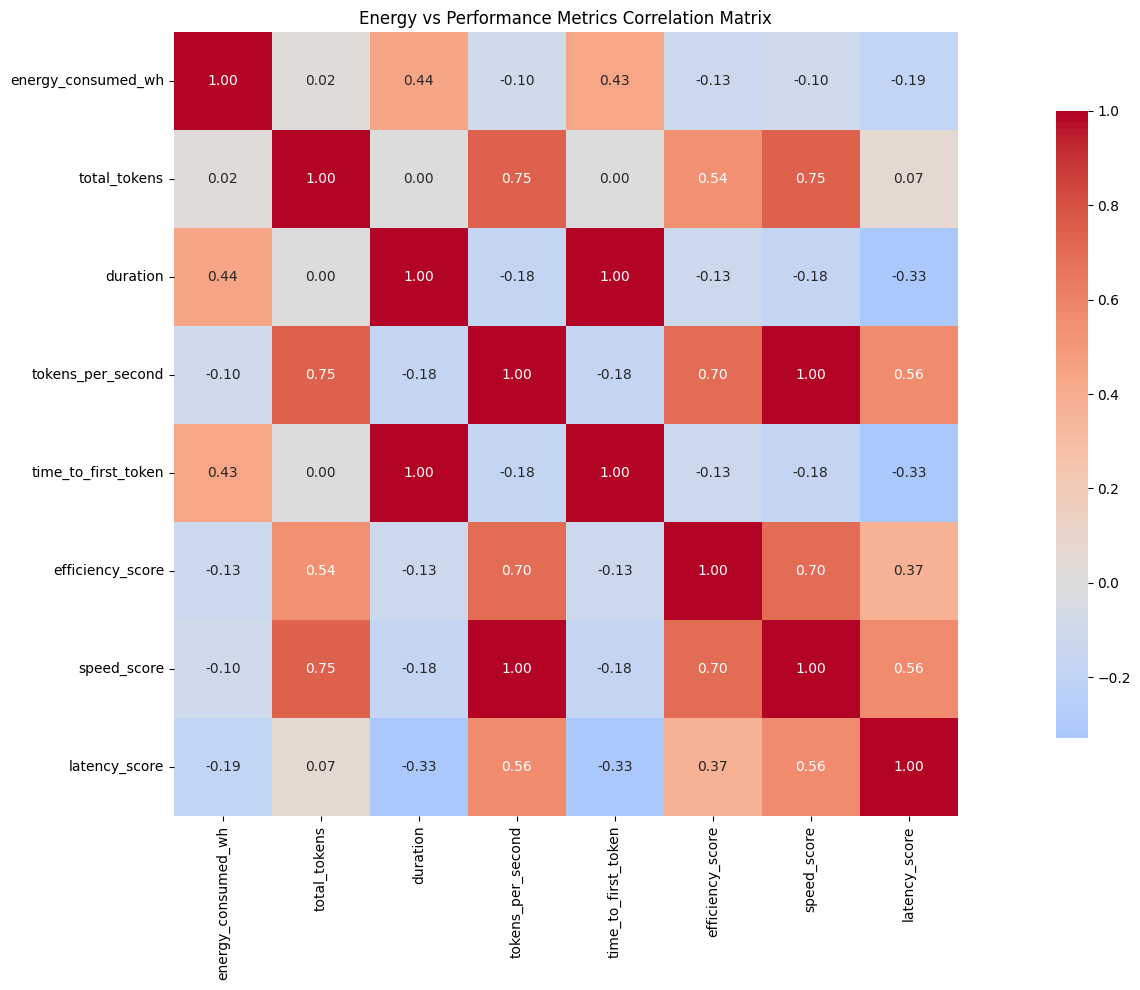

In [455]:
# Analyze correlations between energy and performance metrics
key_metrics = ['energy_consumed_wh', 'total_tokens', 'duration', 'tokens_per_second', 
               'time_to_first_token', 'efficiency_score', 'speed_score', 'latency_score']

correlation_matrix = data[key_metrics].corr()
correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title("Energy vs Performance Metrics Correlation Matrix")
plt.tight_layout()
plt.show()


Outliers: 2925 (14.1%)


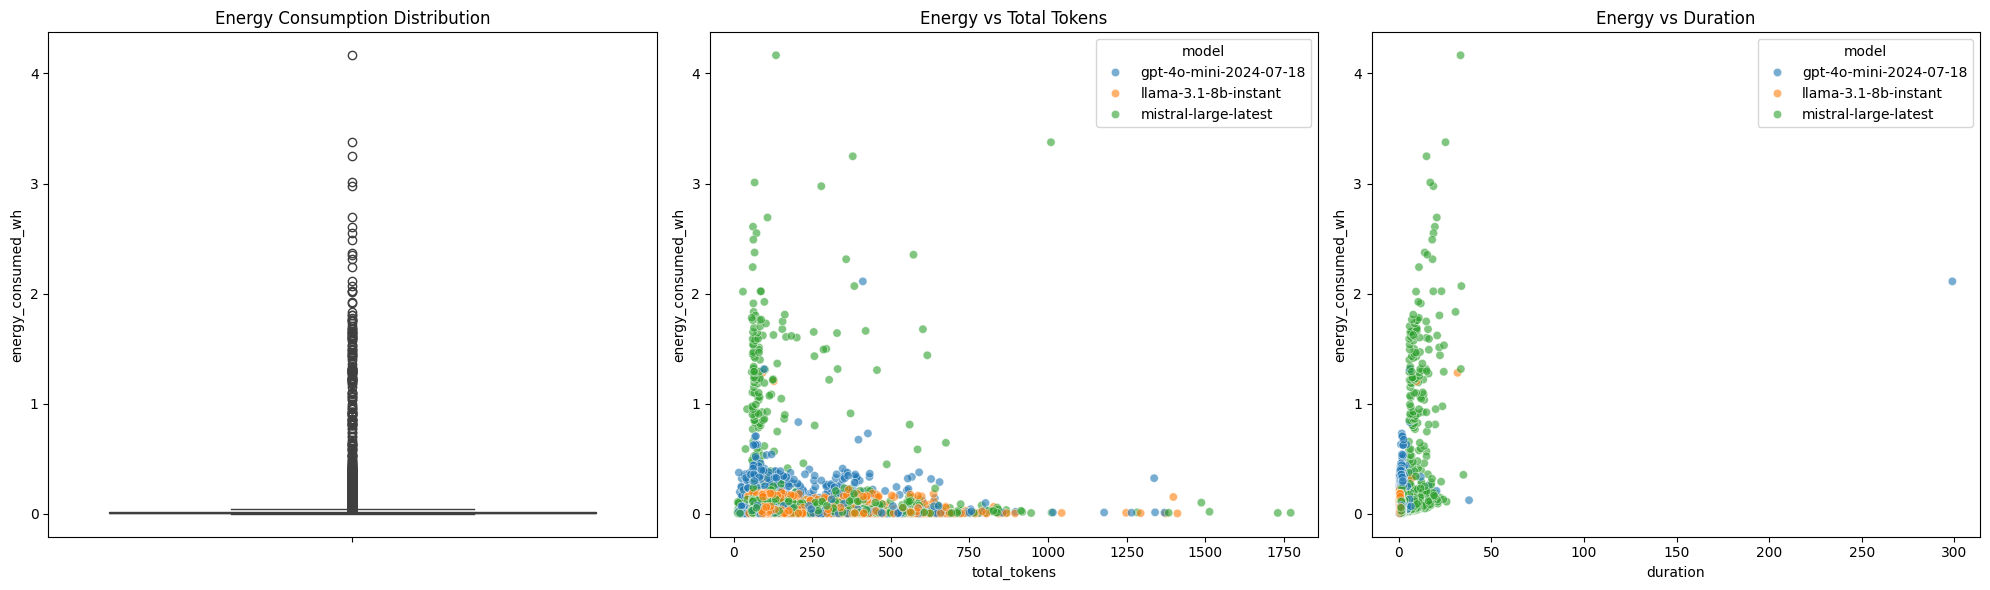

In [456]:
# Analyze outliers and extreme values
Q1 = data['energy_consumed_wh'].quantile(0.25)
Q3 = data['energy_consumed_wh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['energy_consumed_wh'] < lower_bound) | (data['energy_consumed_wh'] > upper_bound)]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.boxplot(data=data, y='energy_consumed_wh')
plt.title("Energy Consumption Distribution")

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='total_tokens', y='energy_consumed_wh', hue='model', alpha=0.6)
plt.title("Energy vs Total Tokens")

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='duration', y='energy_consumed_wh', hue='model', alpha=0.6)
plt.title("Energy vs Duration")

plt.tight_layout()
plt.show()


In [ ]:
# Feature importance analysis for energy consumption
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
exclude_features = ['energy_consumed_wh', 'efficiency_score', 'speed_score', 'latency_score', 'timestamp']
feature_cols = [col for col in numeric_features if col not in exclude_features]

X = data[feature_cols].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(15)

plt.figure(figsize=(20, 10))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title("Top 15 Feature Importance for Energy Consumption")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
# Lexical features analysis
lexical_features = [
    'avg_word_frequency', 'lexical_diversity', 'vocabulary_richness', 
    'type_token_ratio', 'avg_word_length', 'prompt_length_words'
]

available_lexical = [f for f in lexical_features if f in data.columns]

if available_lexical:
    corr_features = ['energy_consumed_wh'] + available_lexical
    correlation_matrix = data[corr_features].corr()
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    energy_corr


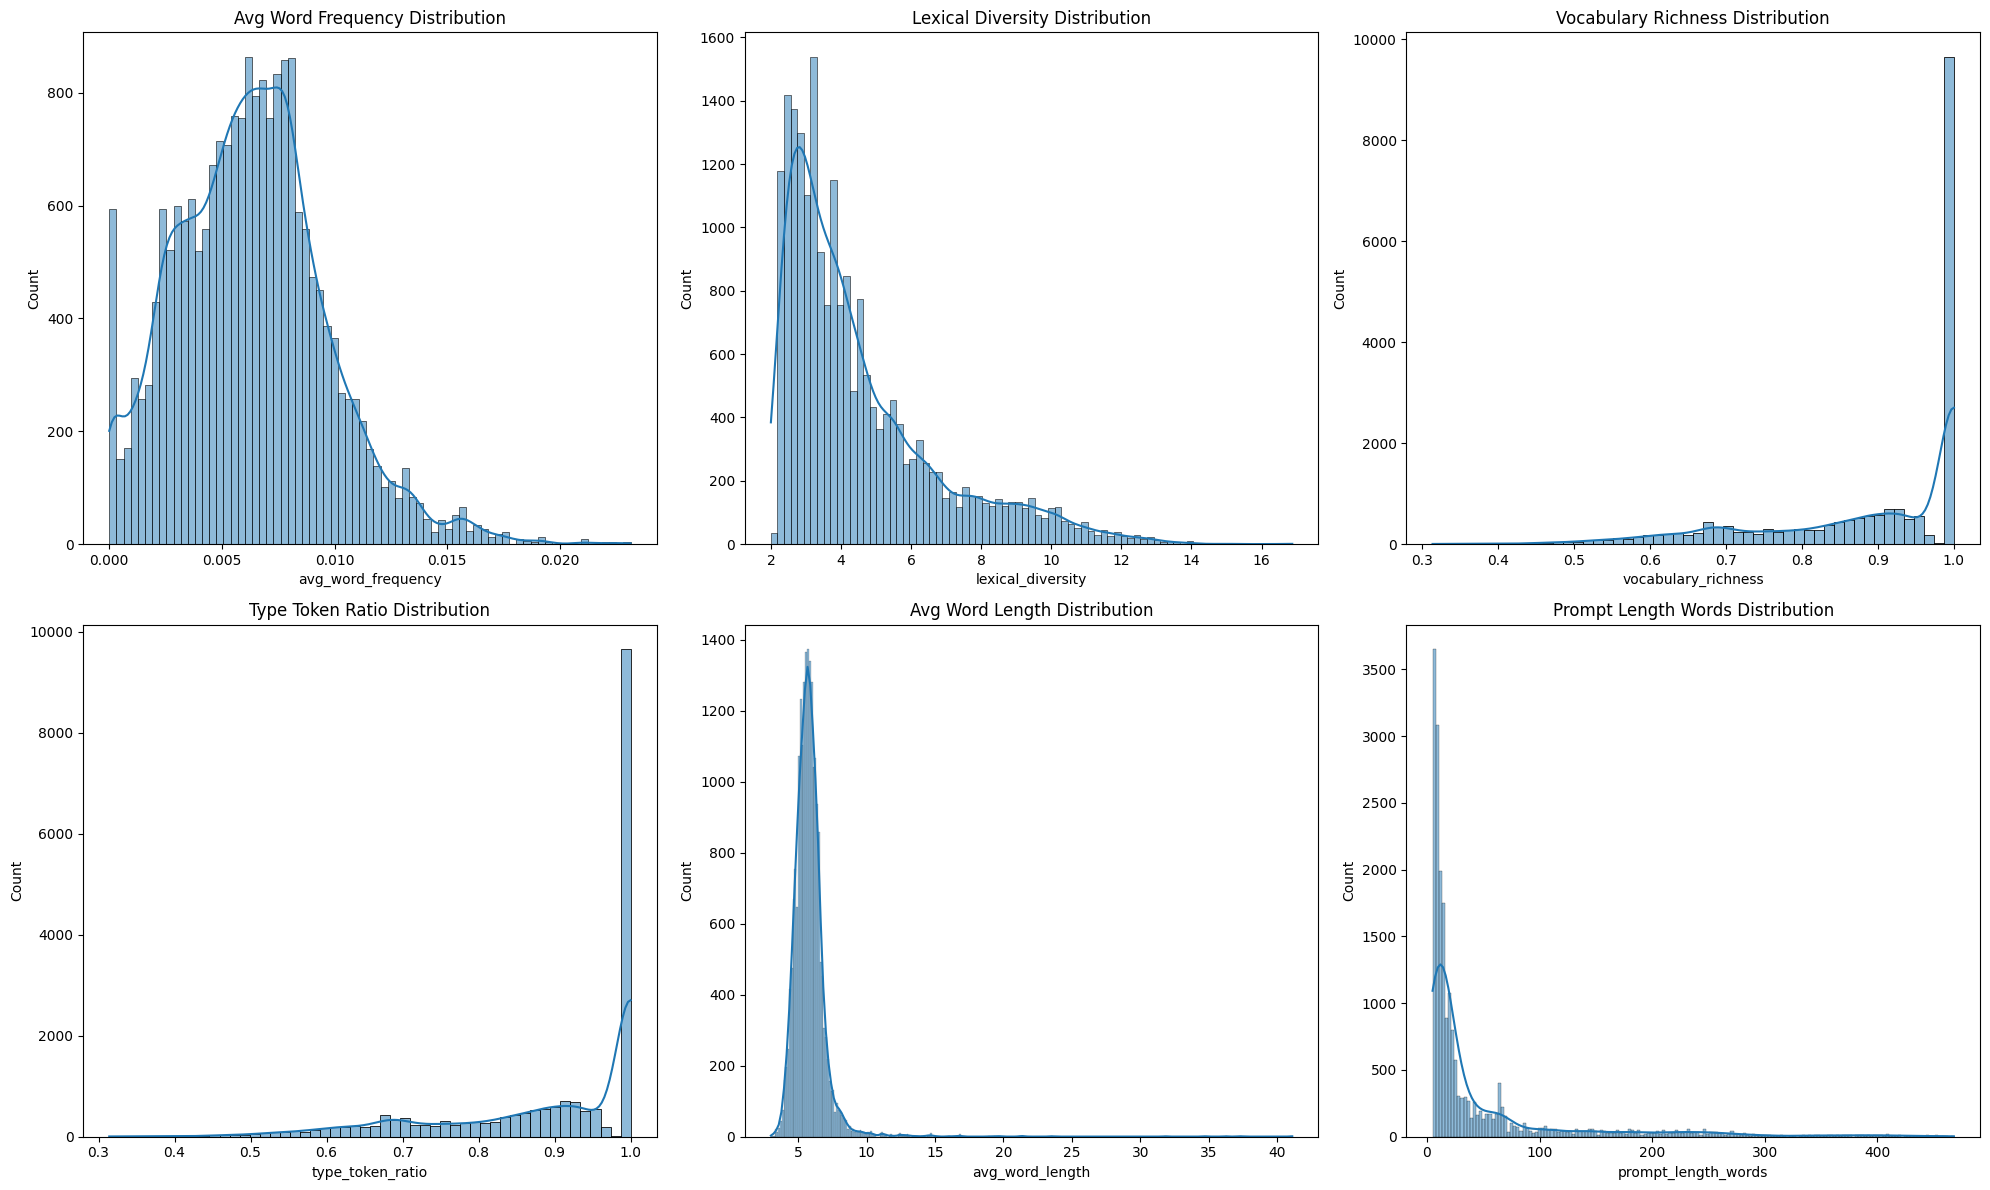

In [ ]:
# Lexical features distribution plots
if available_lexical:
    plt.figure(figsize=(20, 12))
    
    for i, feature in enumerate(available_lexical[:6], 1):
        plt.subplot(2, 3, i)
        sns.histplot(data=data, x=feature, kde=True)
        plt.title(f'{feature.replace("_", " ").title()} Distribution')
    
    plt.tight_layout()
    plt.show()


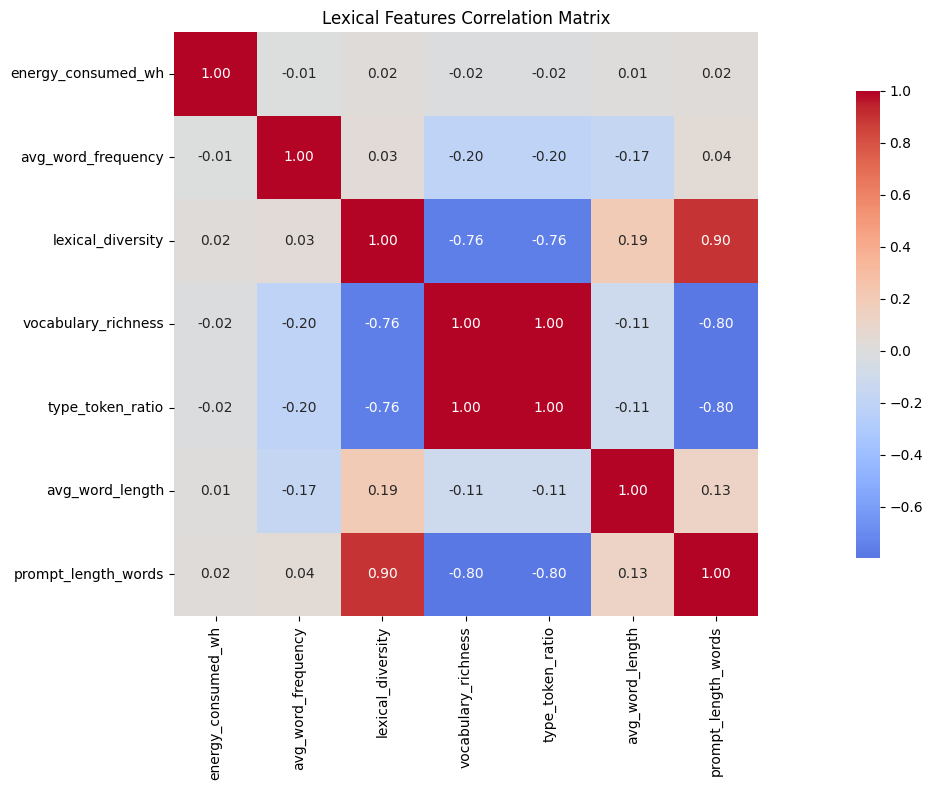

In [ ]:
# Lexical features correlation heatmap
if available_lexical:
    plt.figure(figsize=(20, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title("Lexical Features Correlation Matrix")
    plt.tight_layout()
    plt.show()


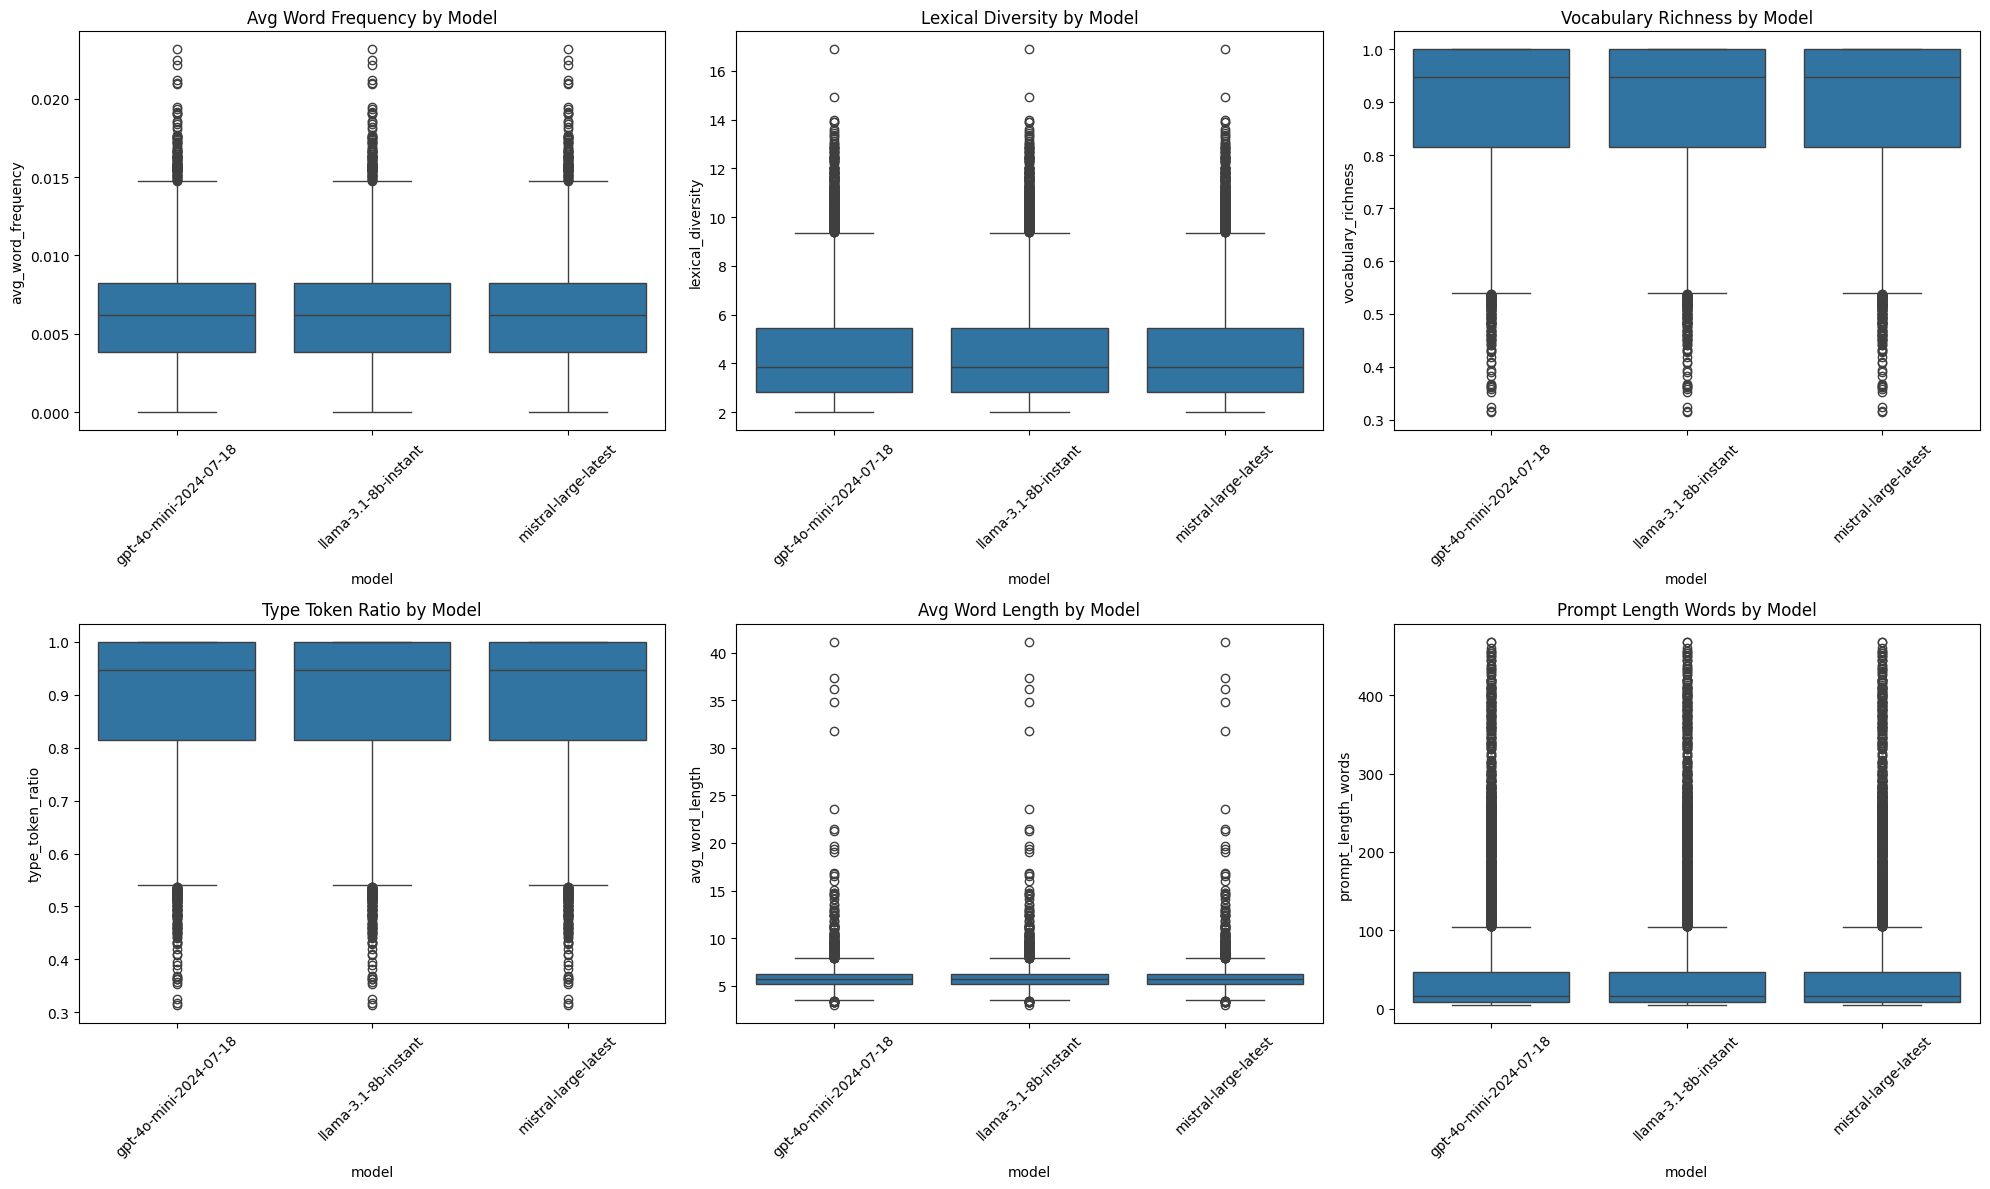

In [ ]:
# Lexical features by model
if available_lexical:
    plt.figure(figsize=(20, 12))
    for i, feature in enumerate(available_lexical[:6], 1):
        plt.subplot(2, 3, i)
        sns.boxplot(data=data, x='model', y=feature)
        plt.title(f'{feature.replace("_", " ").title()} by Model')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
# Semantic features analysis
semantic_features = [
    'named_entity_density', 'semantic_category_diversity', 'information_density',
    'abstract_thinking_density', 'problem_solving_density', 'communication_density',
    'emotional_psychological_density', 'decision_making_density', 'time_change_density'
]

available_semantic = [f for f in semantic_features if f in data.columns]

if available_semantic:
    corr_features = ['energy_consumed_wh'] + available_semantic
    correlation_matrix = data[corr_features].corr()
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    energy_corr


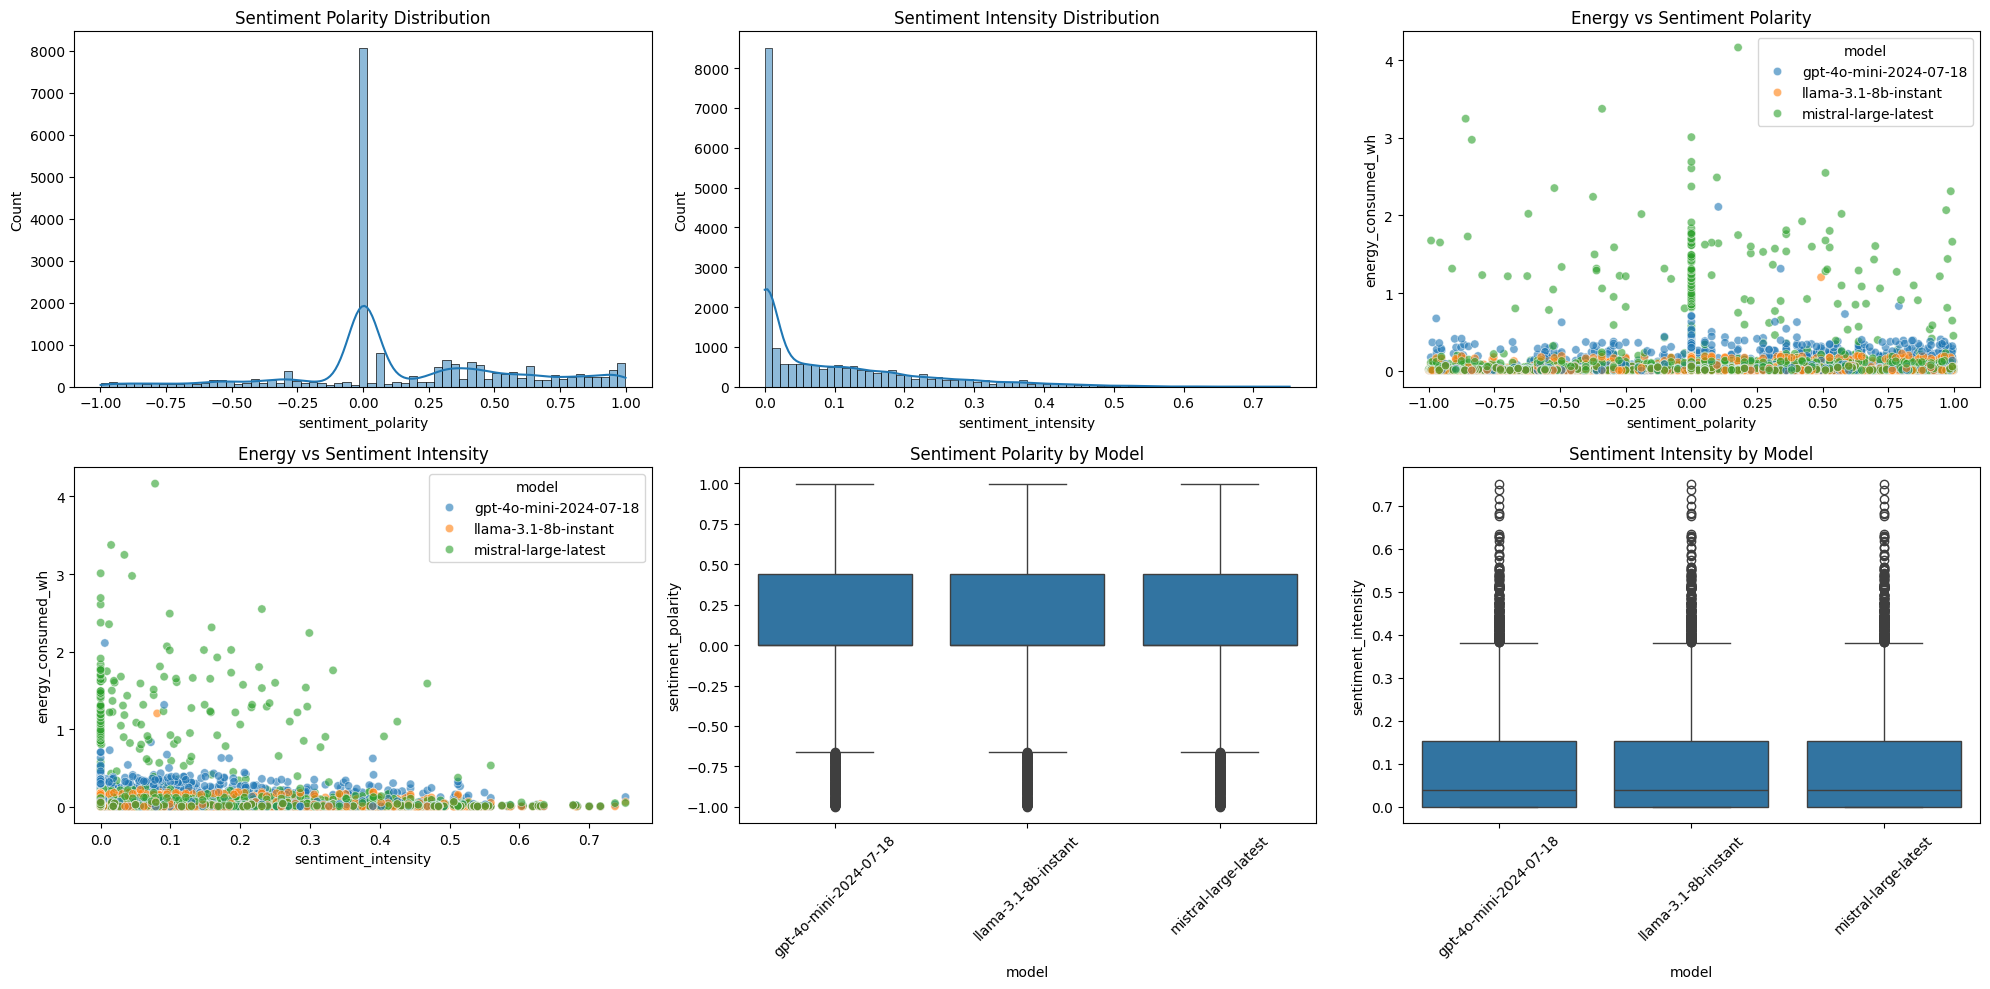

In [ ]:
# Comprehensive sentiment features analysis
sentiment_features = [
    'sentiment_polarity', 'sentiment_intensity'
]

available_sentiment = [f for f in sentiment_features if f in data.columns]

if available_sentiment:
    corr_features = ['energy_consumed_wh'] + available_sentiment
    correlation_matrix = data[corr_features].corr()
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    energy_corr
    
    plt.figure(figsize=(20, 10))
    
    for i, feature in enumerate(available_sentiment, 1):
        plt.subplot(2, 3, i)
        sns.histplot(data=data, x=feature, kde=True)
        plt.title(f'{feature.replace("_", " ").title()} Distribution')
    
    for i, feature in enumerate(available_sentiment, 3):
        plt.subplot(2, 3, i)
        sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
        plt.title(f'Energy vs {feature.replace("_", " ").title()}')
    
    for i, feature in enumerate(available_sentiment, 5):
        if i <= 6:
            plt.subplot(2, 3, i)
            sns.boxplot(data=data, x='model', y=feature)
            plt.title(f'{feature.replace("_", " ").title()} by Model')
            plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


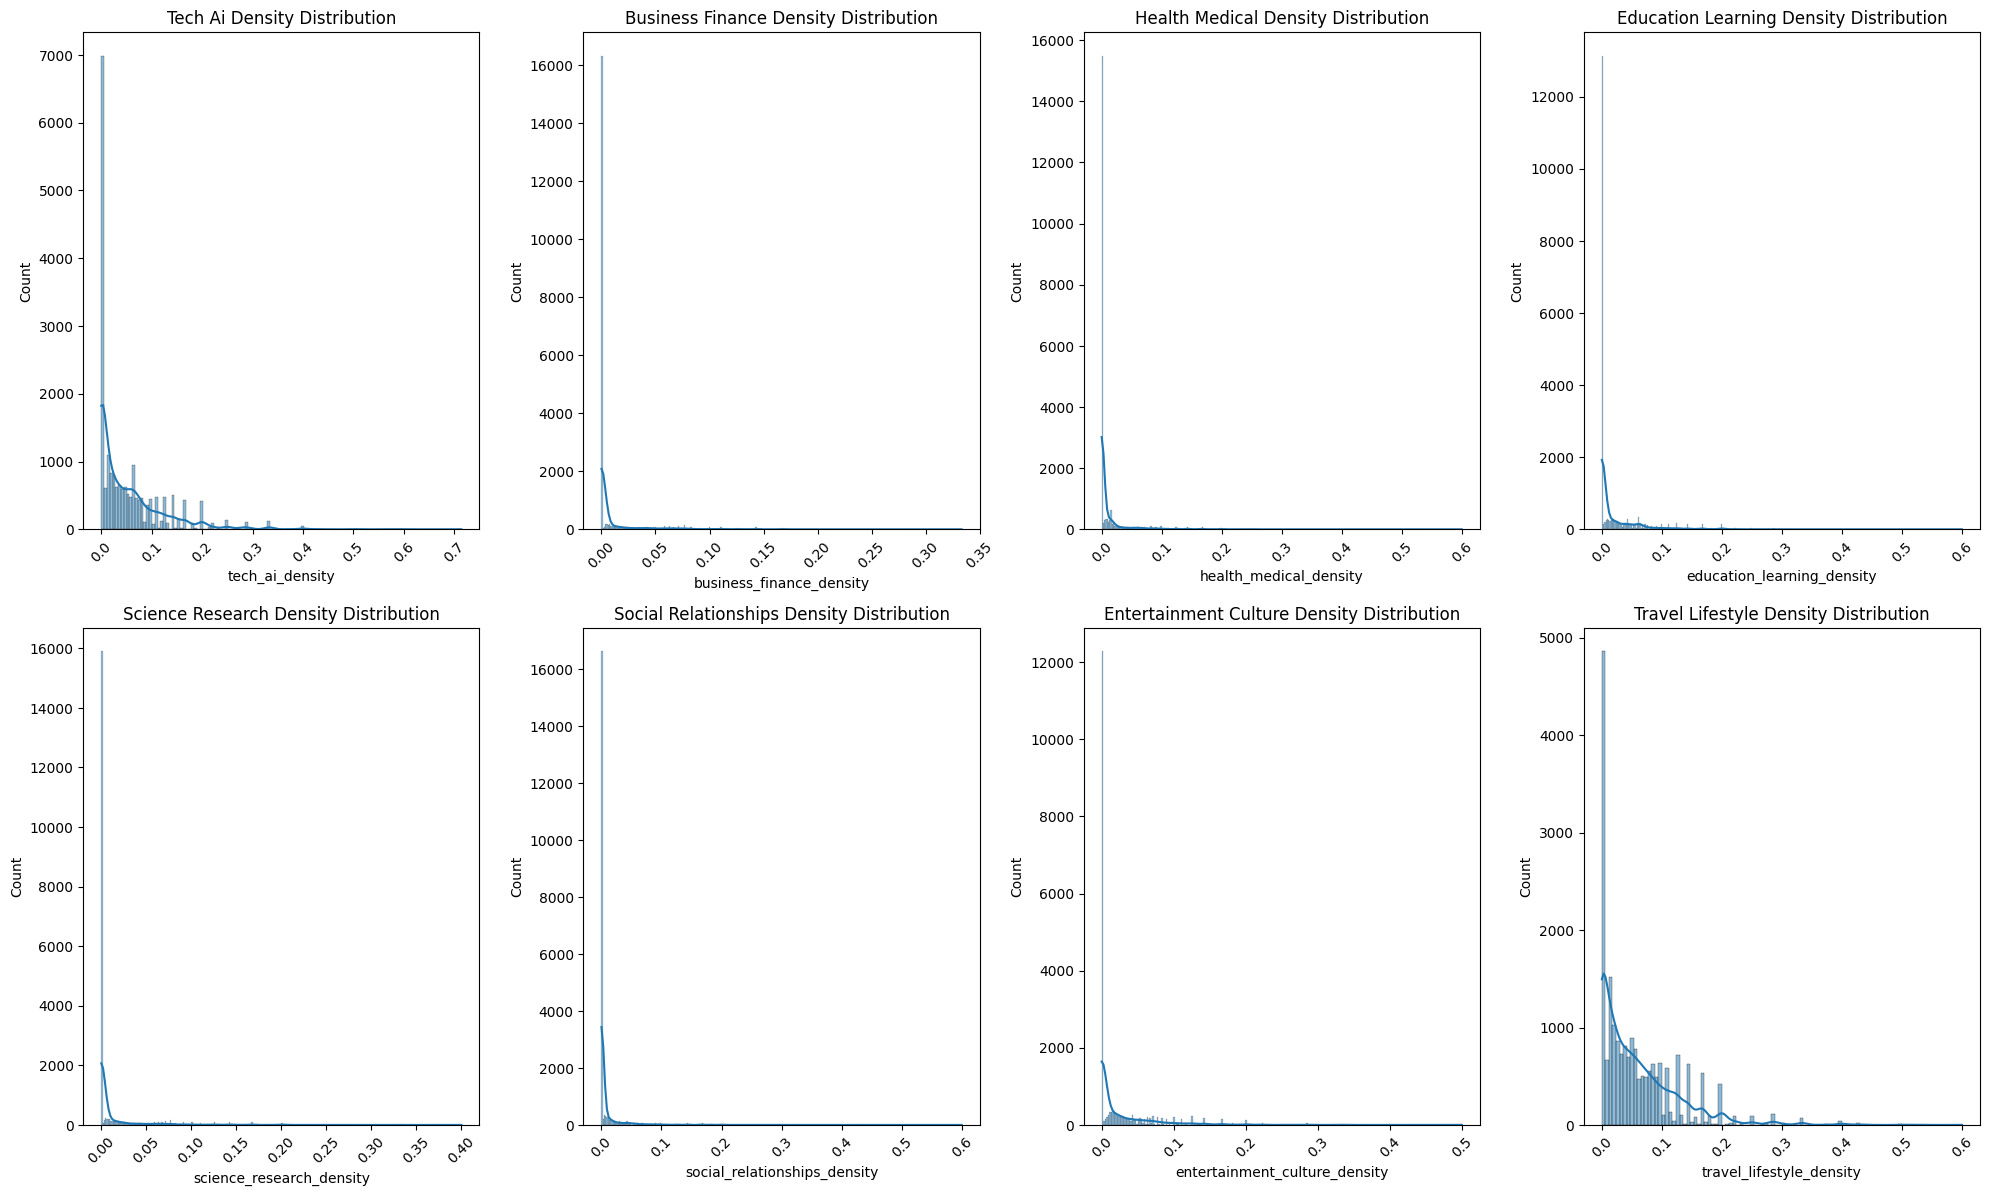

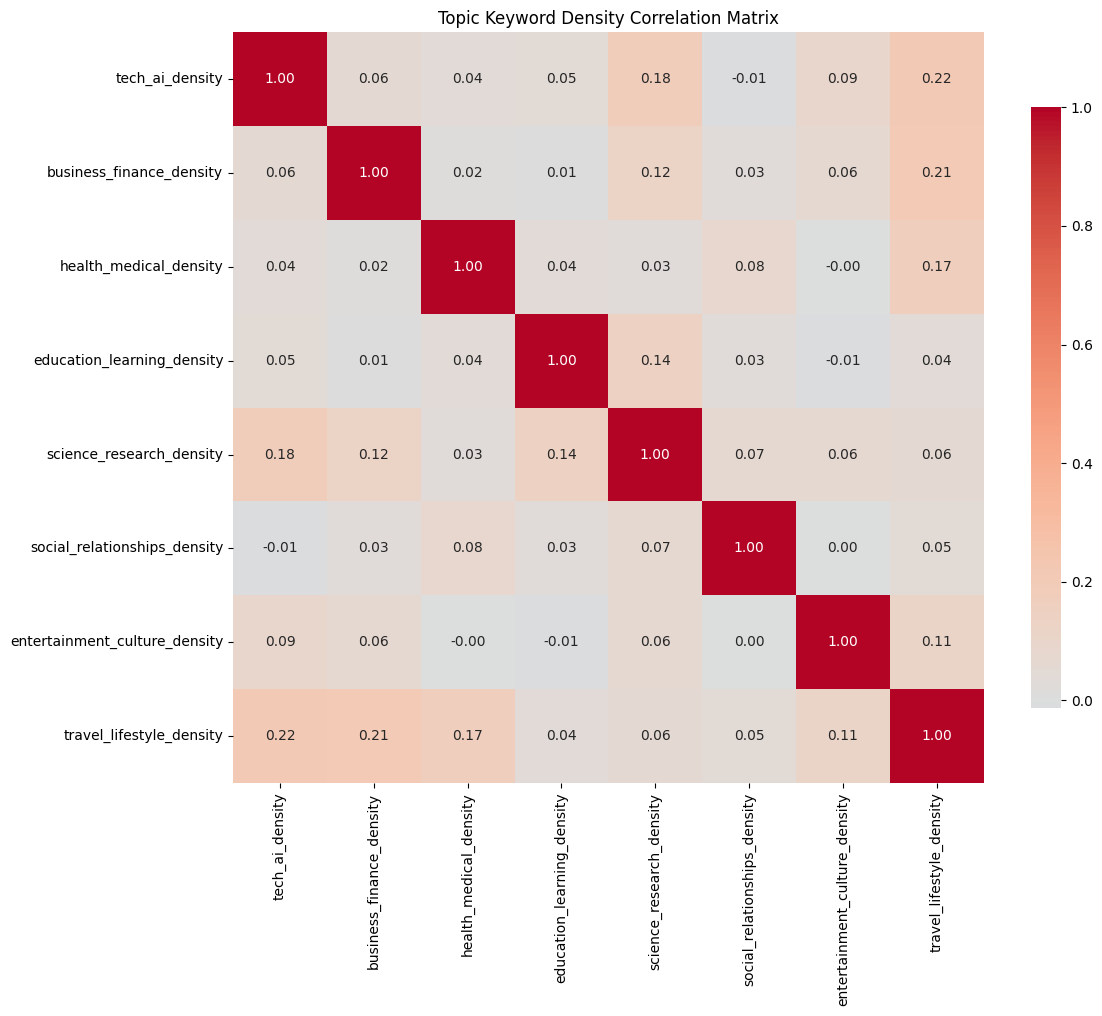

In [ ]:
# Comprehensive topic keyword density analysis
topic_features = [
    'tech_ai_density', 'business_finance_density', 'health_medical_density',
    'education_learning_density', 'science_research_density', 'social_relationships_density',
    'entertainment_culture_density', 'travel_lifestyle_density'
]

available_topic = [f for f in topic_features if f in data.columns]

if available_topic:
    corr_features = ['energy_consumed_wh'] + available_topic
    correlation_matrix = data[corr_features].corr()
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    energy_corr
    
    plt.figure(figsize=(20, 12))
    
    for i, feature in enumerate(available_topic, 1):
        plt.subplot(2, 4, i)
        sns.histplot(data=data, x=feature, kde=True)
        plt.title(f'{feature.replace("_", " ").title()} Distribution')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(20, 10))
    topic_corr = data[available_topic].corr()
    sns.heatmap(topic_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title("Topic Keyword Density Correlation Matrix")
    plt.tight_layout()
    plt.show()


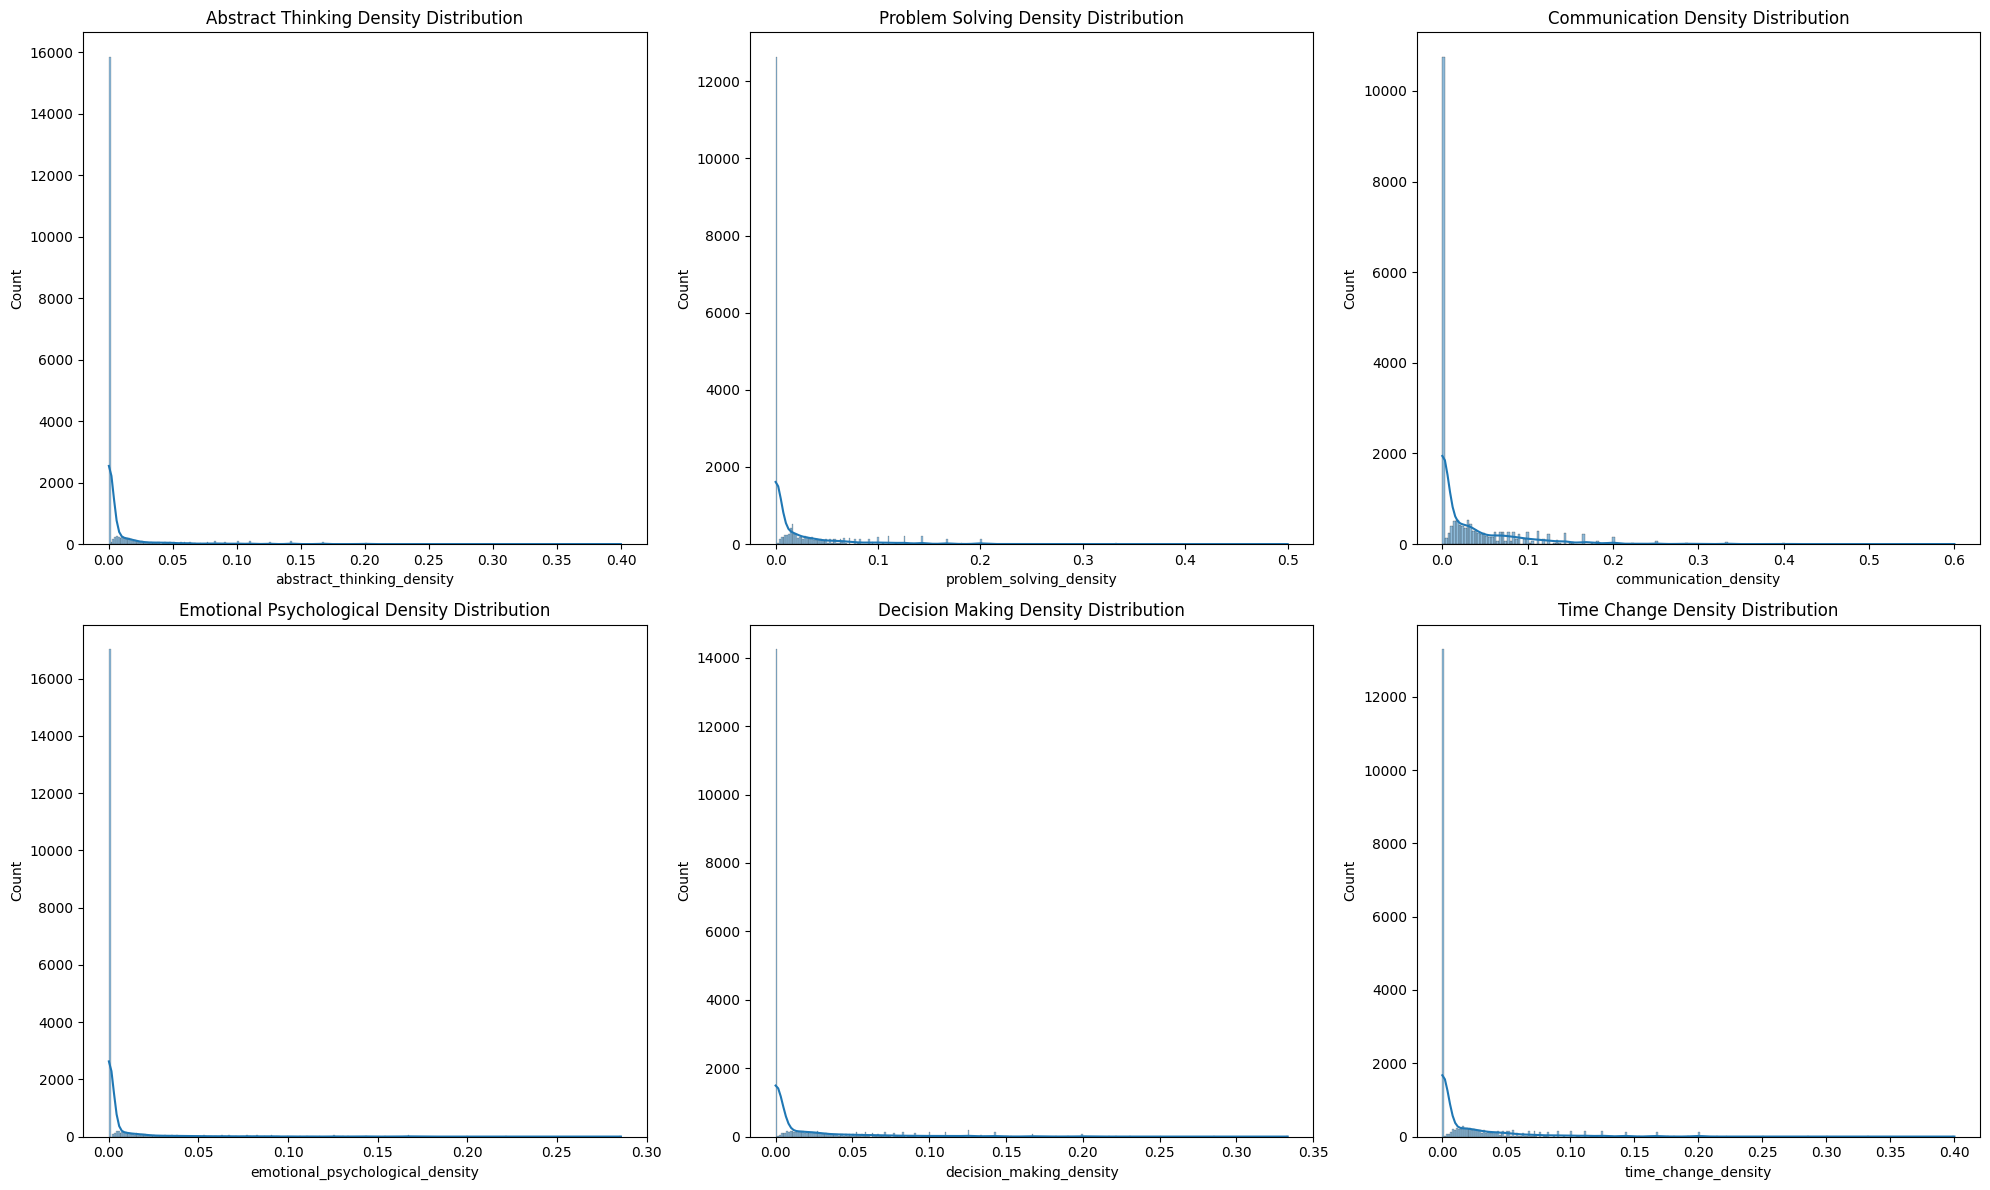

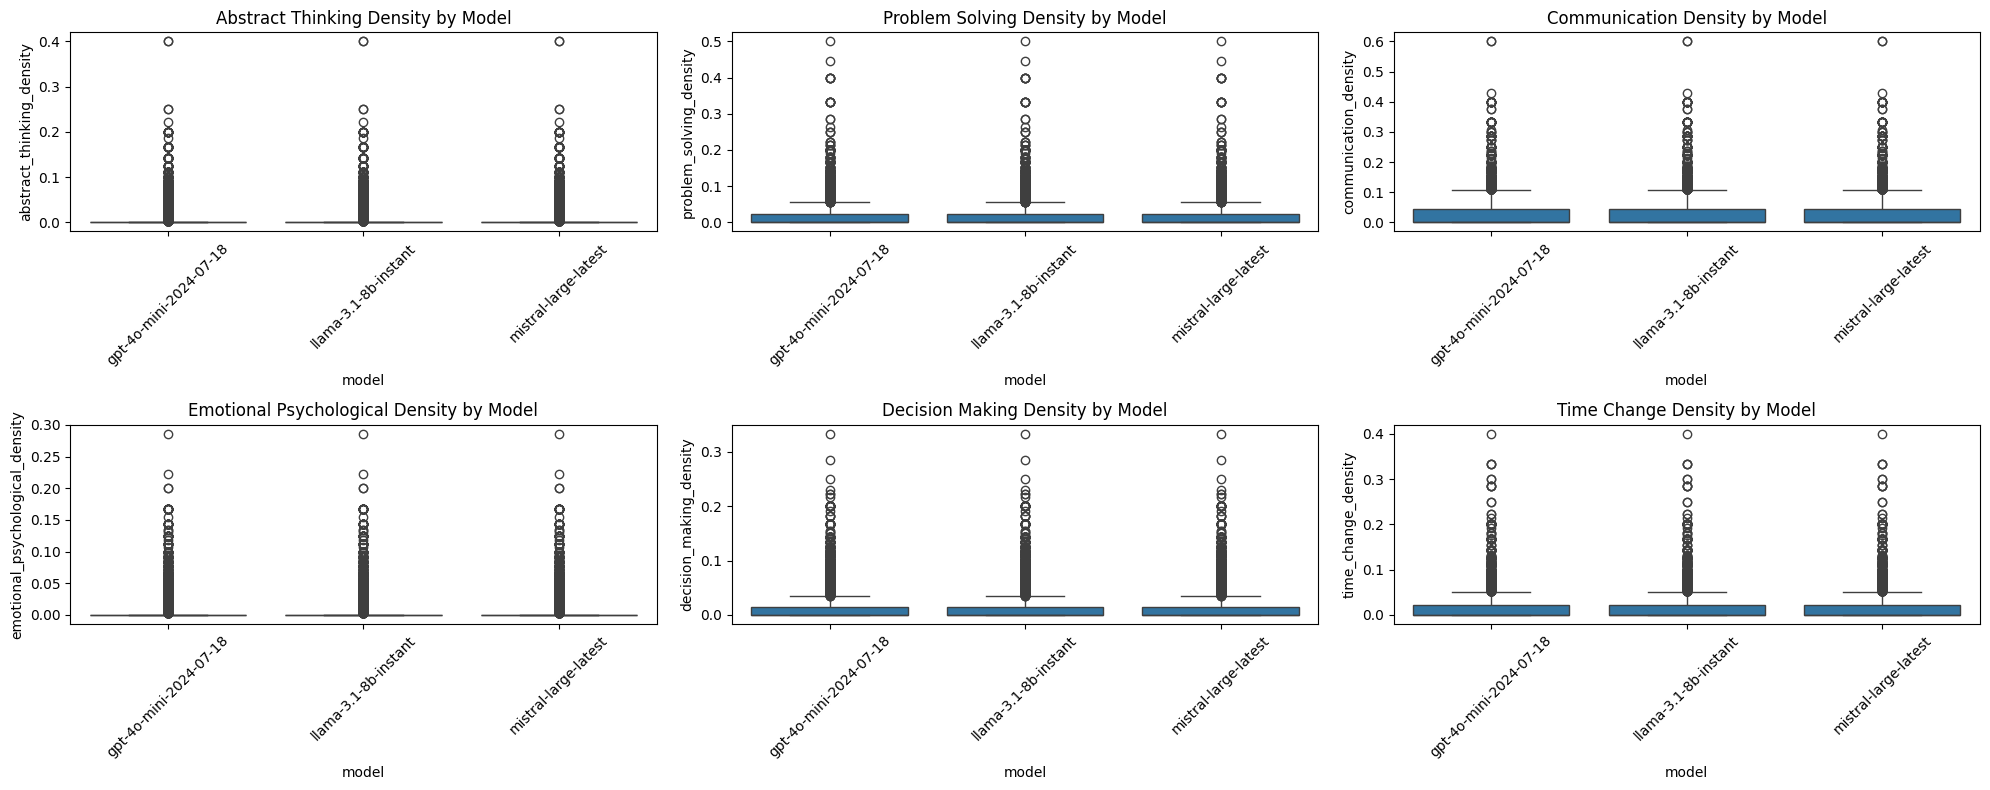

In [ ]:
# Comprehensive concept density analysis
concept_features = [
    'abstract_thinking_density', 'problem_solving_density', 'communication_density',
    'emotional_psychological_density', 'decision_making_density', 'time_change_density'
]

available_concept = [f for f in concept_features if f in data.columns]

if available_concept:
    corr_features = ['energy_consumed_wh'] + available_concept
    correlation_matrix = data[corr_features].corr()
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    energy_corr
    
    plt.figure(figsize=(20, 12))
    
    for i, feature in enumerate(available_concept, 1):
        plt.subplot(2, 3, i)
        sns.histplot(data=data, x=feature, kde=True)
        plt.title(f'{feature.replace("_", " ").title()} Distribution')
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(20, 8))
    for i, feature in enumerate(available_concept, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(data=data, x='model', y=feature)
        plt.title(f'{feature.replace("_", " ").title()} by Model')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


Total features: 60


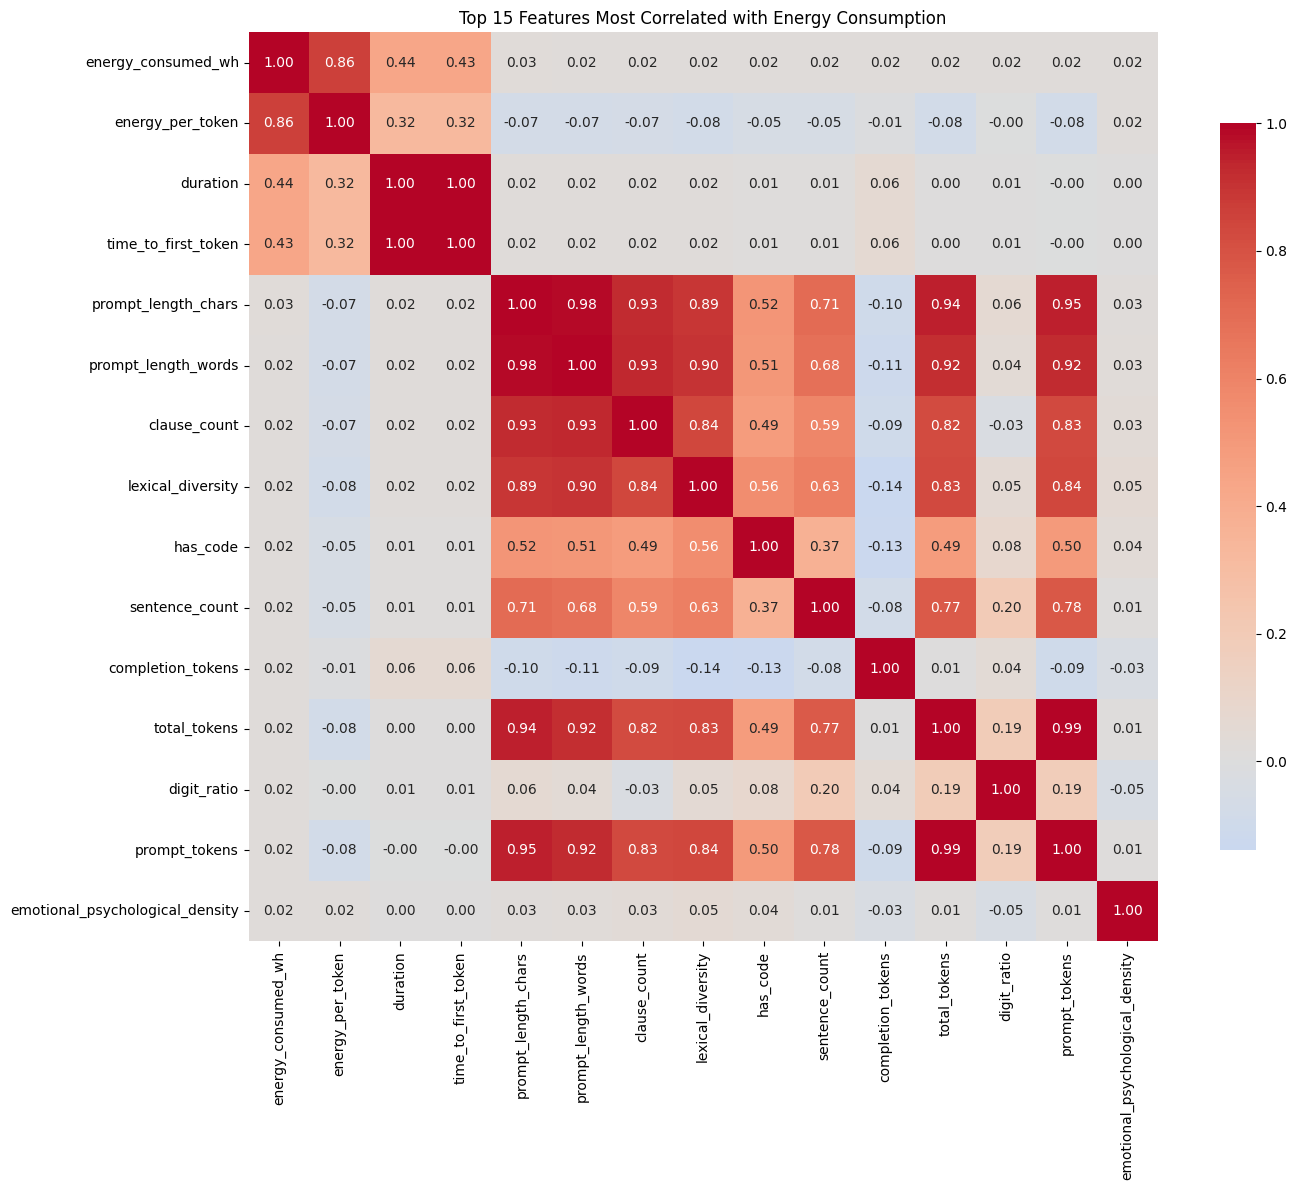

Strong correlations (|r| > 0.5): 1


energy_per_token    0.863441
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Comprehensive correlation analysis with all features
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = data[numeric_features].corr()

energy_correlations = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
print(f"Total features: {len(numeric_features)}")
energy_correlations.head(20)

top_features = energy_correlations.head(15).index.tolist()
plt.figure(figsize=(20, 12))
top_corr_matrix = data[top_features].corr()
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title("Top 15 Features Most Correlated with Energy Consumption")
plt.tight_layout()
plt.show()

strong_corr = energy_correlations[(energy_correlations.abs() > 0.5) & (energy_correlations.index != 'energy_consumed_wh')]
print(f"Strong correlations (|r| > 0.5): {len(strong_corr)}")
strong_corr


In [ ]:
# Comprehensive statistical summaries
model_stats = data.groupby('model').agg({
    'energy_consumed_wh': ['count', 'mean', 'std', 'min', 'max'],
    'total_tokens': ['mean', 'std'],
    'duration': ['mean', 'std'],
    'tokens_per_second': ['mean', 'std'],
    'efficiency_score': ['mean', 'std']
}).round(3)
model_stats

percentiles = [10, 25, 50, 75, 90, 95, 99]
energy_percentiles = data['energy_consumed_wh'].quantile([p/100 for p in percentiles])
print("Energy Consumption Percentiles:")
for p, val in zip(percentiles, energy_percentiles):
    print(f"{p}th percentile: {val:.3f} Wh")

numeric_cols = data.select_dtypes(include=[np.number]).columns
skewness = data[numeric_cols].skew().sort_values(ascending=False)
print(f"Most skewed features: {skewness.head(5).to_dict()}")

missing_analysis = data.isnull().sum()
missing_percent = (missing_analysis / len(data)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_analysis,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)
print(f"Features with missing data: {missing_summary[missing_summary['Missing Count'] > 0].shape[0]}")


Energy Consumption Percentiles:
10th percentile: 0.003 Wh
25th percentile: 0.005 Wh
50th percentile: 0.008 Wh
75th percentile: 0.020 Wh
90th percentile: 0.065 Wh
95th percentile: 0.126 Wh
99th percentile: 0.358 Wh
Most skewed features: {'time_to_first_token': 68.66341159380823, 'duration': 68.06721098133583, 'has_emails': 58.72818675557295, 'response_efficiency': 29.937735108385155, 'exclamation_count': 17.382854665883244}
Features with missing data: 0


In [ ]:
# Comprehensive insights and patterns
efficiency_analysis = data.groupby('model').agg({
    'energy_consumed_wh': 'mean',
    'total_tokens': 'mean',
    'efficiency_score': 'mean',
    'speed_score': 'mean'
}).round(3)
efficiency_analysis['energy_per_token'] = efficiency_analysis['energy_consumed_wh'] / efficiency_analysis['total_tokens']
efficiency_analysis.sort_values('efficiency_score', ascending=False)

energy_median = data['energy_consumed_wh'].median()
high_energy = data[data['energy_consumed_wh'] > energy_median]
low_energy = data[data['energy_consumed_wh'] <= energy_median]

print(f"High Energy Group: {len(high_energy)} samples")
print(f"Low Energy Group: {len(low_energy)} samples")

key_features = ['total_tokens', 'duration', 'tokens_per_second', 'prompt_length_words', 'sentence_count']
comparison = pd.DataFrame({
    'High Energy Mean': high_energy[key_features].mean(),
    'Low Energy Mean': low_energy[key_features].mean(),
    'Difference': high_energy[key_features].mean() - low_energy[key_features].mean()
}).round(3)
comparison

print(f"Total samples: {len(data)}")
print(f"Models: {data['model'].nunique()}")
print(f"Energy range: {data['energy_consumed_wh'].min():.3f} to {data['energy_consumed_wh'].max():.3f} Wh")
print(f"Token range: {data['total_tokens'].min()} to {data['total_tokens'].max()} tokens")


High Energy Group: 10330 samples
Low Energy Group: 10379 samples
Total samples: 20709
Models: 3
Energy range: 0.000 to 4.165 Wh
Token range: 13 to 1771 tokens


In [ ]:
# Analyze energy consumption by syntactic tree depth
if 'syntactic_tree_depth' in data.columns:
    data.groupby("syntactic_tree_depth")["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by clause count
if 'clause_count' in data.columns:
    data.groupby("clause_count")["energy_consumed_wh"].mean()


In [ ]:
# Compare readability scores with average energy usage
if 'flesch_kincaid_grade' in data.columns:
    data.groupby(pd.cut(data["flesch_kincaid_grade"], bins=5))["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by word frequency range
if 'avg_word_frequency' in data.columns:
    data.groupby(pd.qcut(data["avg_word_frequency"], q=5))["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by lexical diversity range
if 'lexical_diversity' in data.columns:
    data.groupby(pd.qcut(data["lexical_diversity"], q=5))["energy_consumed_wh"].mean()


In [ ]:
# Compare vocabulary richness levels with mean energy usage
if 'vocabulary_richness' in data.columns:
    data.groupby(pd.qcut(data["vocabulary_richness"], q=5))["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by named entity density range
if 'named_entity_density' in data.columns:
    data.groupby(pd.qcut(data["named_entity_density"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by semantic category diversity
if 'semantic_category_diversity' in data.columns:
    data.groupby("semantic_category_diversity")["energy_consumed_wh"].mean()


In [ ]:
# Compare models on semantic features and energy usage
semantic_cols = ['named_entity_density', 'semantic_category_diversity', 'energy_consumed_wh']
available_semantic_cols = [col for col in semantic_cols if col in data.columns]
if available_semantic_cols:
    data.groupby("model")[available_semantic_cols].mean()


In [ ]:
# Analyze energy consumption by sentiment polarity range
if 'sentiment_polarity' in data.columns:
    data.groupby(pd.qcut(data["sentiment_polarity"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


In [ ]:
# Analyze energy consumption by sentiment intensity range
if 'sentiment_intensity' in data.columns:
    data.groupby(pd.qcut(data["sentiment_intensity"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


In [ ]:
# Compare models on sentiment and energy usage
sentiment_cols = ['sentiment_polarity', 'sentiment_intensity', 'energy_consumed_wh']
available_sentiment_cols = [col for col in sentiment_cols if col in data.columns]
if available_sentiment_cols:
    data.groupby("model")[available_sentiment_cols].mean()


In [ ]:
# Analyze topic keyword densities and energy consumption
topic_cols = [
    "tech_ai_density", "business_finance_density", "health_medical_density",
    "education_learning_density", "science_research_density", "social_relationships_density",
    "entertainment_culture_density", "travel_lifestyle_density"
]
available_topic_cols = [col for col in topic_cols if col in data.columns]
if available_topic_cols:
    corr_features = ["energy_consumed_wh"] + available_topic_cols
    data[corr_features].corr()


In [ ]:
# Analyze concept densities and energy consumption
concept_cols = [
    "abstract_thinking_density", "problem_solving_density", "communication_density",
    "emotional_psychological_density", "decision_making_density", "time_change_density"
]
available_concept_cols = [col for col in concept_cols if col in data.columns]
if available_concept_cols:
    corr_features = ["energy_consumed_wh"] + available_concept_cols
    data[corr_features].corr()


In [ ]:
# Calculate correlation matrix for numeric features
corr = data.corr(numeric_only=True)


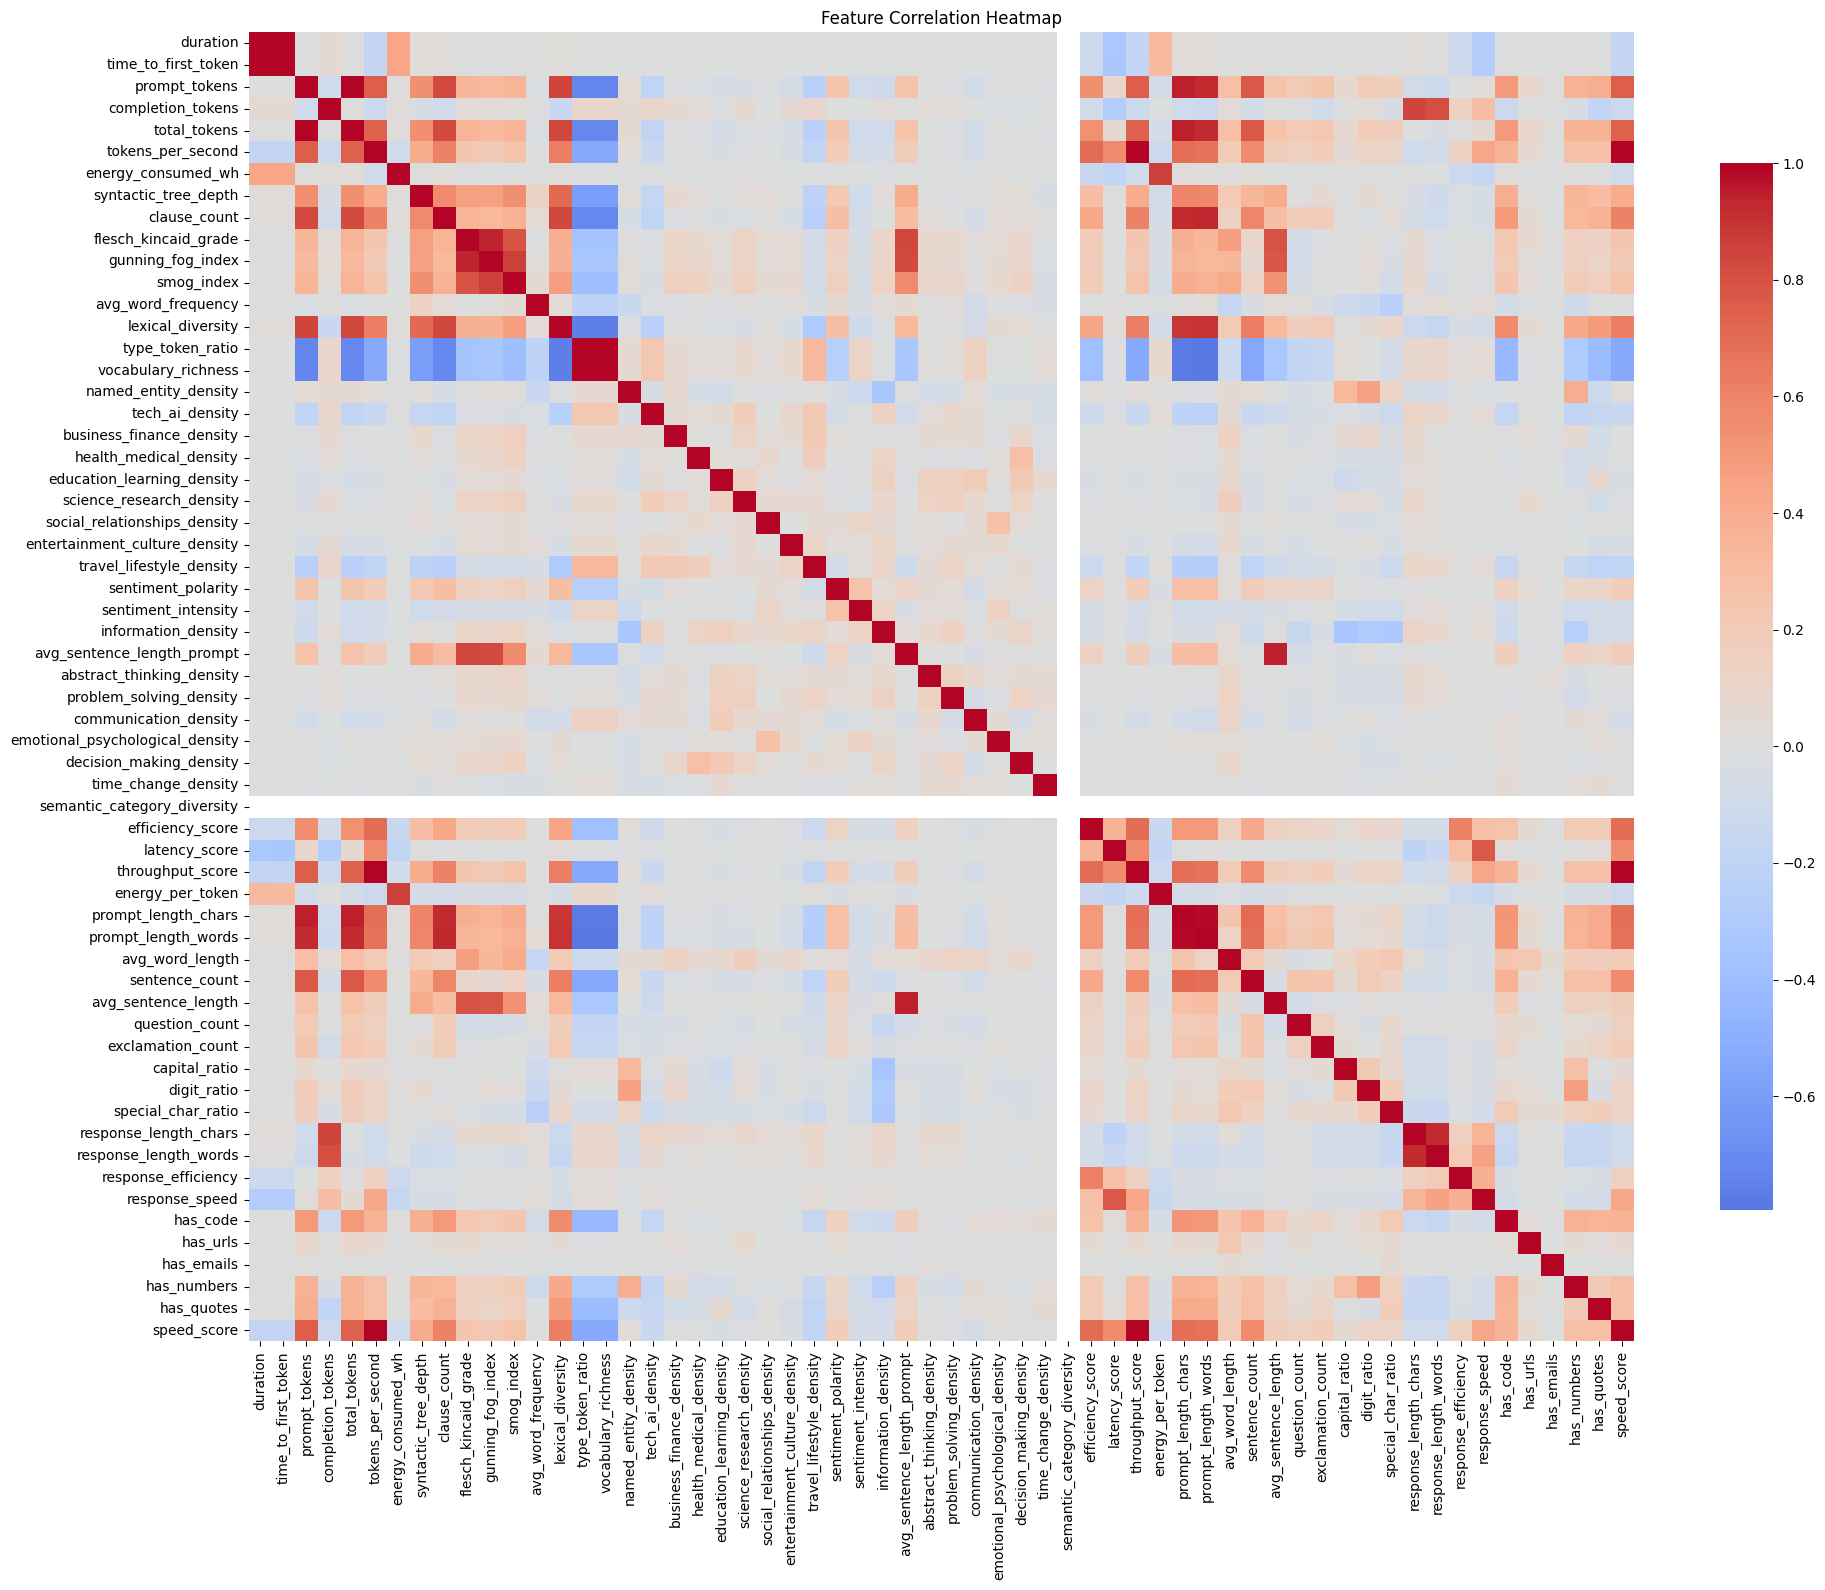

In [ ]:
# Visualize full correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


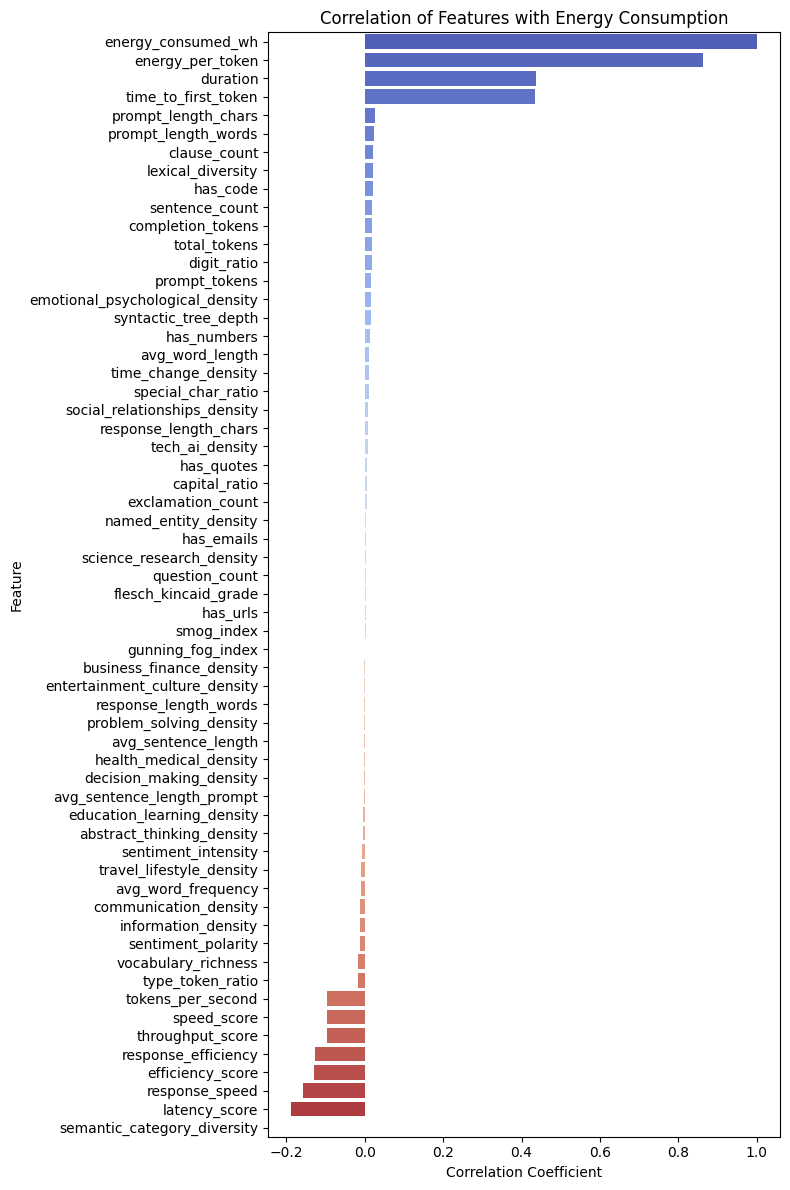

In [ ]:
# Visualize correlations specifically with energy consumption
energy_corr = corr["energy_consumed_wh"].sort_values(ascending=False)

plt.figure(figsize=(20, 12))
sns.barplot(x=energy_corr.values, y=energy_corr.index, palette="coolwarm")
plt.title("Correlation of Features with Energy Consumption")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# Summary statistics for key numeric features
data.select_dtypes(include=["number"]).describe()


,duration,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,tokens_per_second,energy_consumed_wh,syntactic_tree_depth,clause_count,flesch_kincaid_grade,...,response_length_chars,response_length_words,response_efficiency,response_speed,has_code,has_urls,has_emails,has_numbers,has_quotes,speed_score
count,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,...,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000
mean,1.410409,1.407245,83.428992,45.168574,128.597566,152.426790,0.034287,5.563282,6.738809,7.772531,...,202.238640,32.107007,4776.449253,35.658149,0.254962,0.004056,0.000290,0.454585,0.312763,152.426790
std,2.678725,2.670026,118.680900,11.942494,118.146595,182.004568,0.132695,3.049273,11.922437,7.258165,...,65.792528,10.305763,7807.719819,25.469997,0.435850,0.063561,0.017019,0.497945,0.463630,182.004568
min,0.270000,0.271000,8.000000,1.000000,13.000000,1.400000,0.000100,1.000000,0.000000,-2.620000,...,1.000000,1.000000,0.694830,0.010039,0.000000,0.000000,0.000000,0.000000,0.000000,1.400000
25%,0.700000,0.699000,20.000000,50.000000,68.000000,50.900000,0.004800,3.000000,1.000000,3.890270,...,182.000000,29.000000,1335.504886,18.867925,0.000000,0.000000,0.000000,0.000000,0.000000,50.900000
50%,1.070000,1.069000,44.000000,50.000000,92.000000,85.100000,0.008400,5.000000,2.000000,6.960000,...,218.000000,35.000000,3474.576271,28.985507,0.000000,0.000000,0.000000,0.000000,0.000000,85.100000
75%,1.510000,1.511000,79.000000,50.000000,124.000000,206.000000,0.019700,7.000000,6.000000,10.315634,...,244.000000,39.000000,6406.250000,42.553191,1.000000,0.000000,0.000000,1.000000,1.000000,206.000000
max,298.840000,298.836000,1721.000000,50.000000,1771.000000,2900.400000,4.165300,73.000000,102.000000,184.705641,...,818.000000,49.000000,450000.000000,128.571429,1.000000,1.000000,1.000000,1.000000,1.000000,2900.400000


In [ ]:
# Model-wise summary statistics for energy consumption and token usage
data.groupby("model")[["energy_consumed_wh", "duration", "tokens_per_second", "total_tokens"]].describe()


energy_consumed_wh                                      \
                                    count      mean       std     min     25%   
model                                                                           
gpt-4o-mini-2024-07-18             6902.0  0.035223  0.077673  0.0001  0.0059   
llama-3.1-8b-instant               6903.0  0.015528  0.036513  0.0001  0.0032   
mistral-large-latest               6904.0  0.052107  0.211628  0.0001  0.0074   

                                               duration            ...  \
                           50%     75%     max    count      mean  ...   
model                                                              ...   
gpt-4o-mini-2024-07-18  0.0094  0.0204  2.1108   6902.0  1.369587  ...   
llama-3.1-8b-instant    0.0045  0.0095  1.2799   6903.0  0.628898  ...   
mistral-large-latest    0.0121  0.0284  4.1653   6904.0  2.232617  ...   

                       tokens_per_second         total_tokens              \
                                     75%     max        count        mean   
model                                                                       
gpt-4o-mini-2024-07-18             97.50  1330.1       6902.0  116.774993   
llama-3.1-8b-instant              287.75  2900.4       6903.0  147.363465   
mistral-large-latest               79.20  1369.5       6904.0  121.653534   

                                                                      
                               std   min   25%    50%    75%     max  
model                                                                 
gpt-4o-mini-2024-07-18  112.628476  16.0  66.0   75.0  110.0  1370.0  
llama-3.1-8b-instant    115.890523  43.0  94.0  103.0  141.0  1411.0  
mistral-large-latest    123.383658  13.0  64.0   75.0  112.0  1771.0  

[3 rows x 32 columns]

In [ ]:
# Average performance metrics per model
data.groupby("model")[["energy_consumed_wh", "duration", "tokens_per_second", "total_tokens"]].mean()


,energy_consumed_wh,duration,tokens_per_second,total_tokens
model,,,,
gpt-4o-mini-2024-07-18,0.035223,1.369587,106.649406,116.774993
llama-3.1-8b-instant,0.015528,0.628898,270.510648,147.363465
mistral-large-latest,0.052107,2.232617,80.124160,121.653534


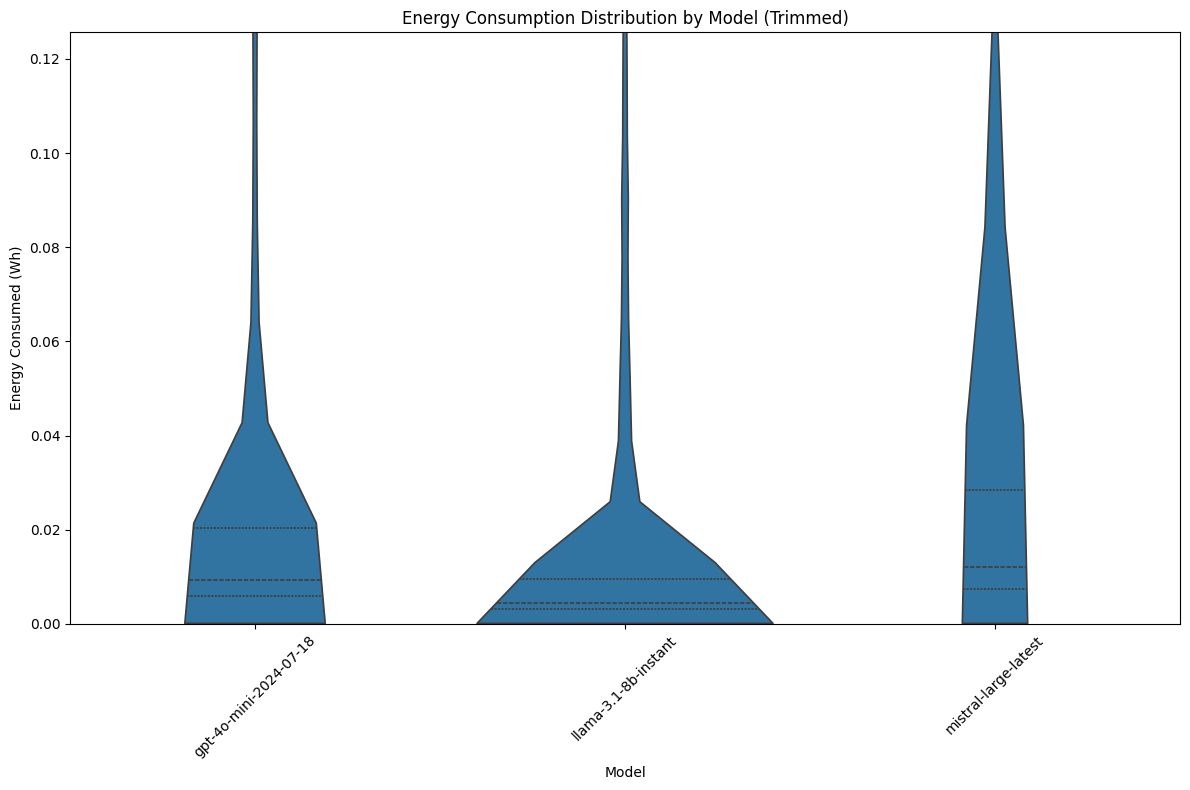

In [ ]:
# Visualize model-wise energy consumption distribution
plt.figure(figsize=(20, 8))
sns.violinplot(x="model", y="energy_consumed_wh", data=data, inner="quartile", cut=0)
plt.ylim(0, data["energy_consumed_wh"].quantile(0.95))
plt.title("Energy Consumption Distribution by Model (Trimmed)")
plt.xlabel("Model")
plt.ylabel("Energy Consumed (Wh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Compare model efficiency (energy per token)
data["energy_per_token"] = data["energy_consumed_wh"] / data["total_tokens"]
data.groupby("model")["energy_per_token"].mean().sort_values()


model
llama-3.1-8b-instant      0.000137
gpt-4o-mini-2024-07-18    0.000434
mistral-large-latest      0.000599
Name: energy_per_token, dtype: float64

In [ ]:
# Identify and document key insights about energy-efficient and energy-intensive prompt characteristics
lowest_energy = data.nsmallest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]]
highest_energy = data.nlargest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]]

print("Lowest Energy Prompts:")
lowest_energy

print("\nHighest Energy Prompts:")
highest_energy


Lowest Energy Prompts:

Highest Energy Prompts:


,prompt,model,energy_consumed_wh,total_tokens
15203,reword as one sentence: Sprout biomass increas...,mistral-large-latest,4.1653,135
17738,search for errors on my code: --Persistencia d...,mistral-large-latest,3.3750,1009
17963,You are MedicalControllerGPT. You analyze doct...,mistral-large-latest,3.2474,379
20636,type an email congratulating the CEO of a part...,mistral-large-latest,3.0095,67
20222,"In this activity, you’ll be asked a series of ...",mistral-large-latest,2.9756,279
16826,"I am reading a how-to page describing ""How to ...",mistral-large-latest,2.6911,108
14771,Do you know any famouse Slovenian?,mistral-large-latest,2.6072,62
18800,"""Eh, you've never used one before?"", said NAME...",mistral-large-latest,2.5488,73
20306,So it okay to talk about pain like that ?,mistral-large-latest,2.4896,63
16973,You are Brotherhood of NAME_1 from Fallout New...,mistral-large-latest,2.3730,67


In [ ]:
# Compare mean feature values for low vs high energy groups
low_energy_group = data[data["energy_consumed_wh"] <= data["energy_consumed_wh"].quantile(0.25)]
high_energy_group = data[data["energy_consumed_wh"] >= data["energy_consumed_wh"].quantile(0.75)]

energy_feature_comparison = (
    pd.DataFrame({
        "Low Energy Mean": low_energy_group.mean(numeric_only=True),
        "High Energy Mean": high_energy_group.mean(numeric_only=True),
        "Difference": high_energy_group.mean(numeric_only=True) - low_energy_group.mean(numeric_only=True)
    })
    .sort_values("Difference", ascending=False)
)

print("Feature Comparison (Low vs High Energy):")
energy_feature_comparison.head(20)


Feature Comparison (Low vs High Energy):


,Low Energy Mean,High Energy Mean,Difference
response_length_chars,184.681182,206.605446,21.924264
completion_tokens,41.264915,46.390112,5.125197
response_length_words,30.028391,32.492082,2.463691
duration,0.653773,2.444208,1.790435
time_to_first_token,0.652210,2.435502,1.783292
energy_consumed_wh,0.003347,0.114858,0.111511
exclamation_count,0.079800,0.091927,0.012127
sentiment_polarity,0.156255,0.166940,0.010685
type_token_ratio,0.887169,0.891576,0.004407
vocabulary_richness,0.887168,0.891575,0.004407


In [ ]:
# Correlation analysis for energy consumption
energy_corr = data.corr(numeric_only=True)["energy_consumed_wh"].sort_values(ascending=False)

print("Top Positive Correlations with Energy Consumption:")
energy_corr.head(10)

print("\nTop Negative Correlations with Energy Consumption:")
energy_corr.tail(10)


Top Positive Correlations with Energy Consumption:

Top Negative Correlations with Energy Consumption:


vocabulary_richness           -0.016818
type_token_ratio              -0.016818
tokens_per_second             -0.097188
speed_score                   -0.097188
throughput_score              -0.097200
response_efficiency           -0.127088
efficiency_score              -0.130158
response_speed                -0.158330
latency_score                 -0.187152
semantic_category_diversity         NaN
Name: energy_consumed_wh, dtype: float64

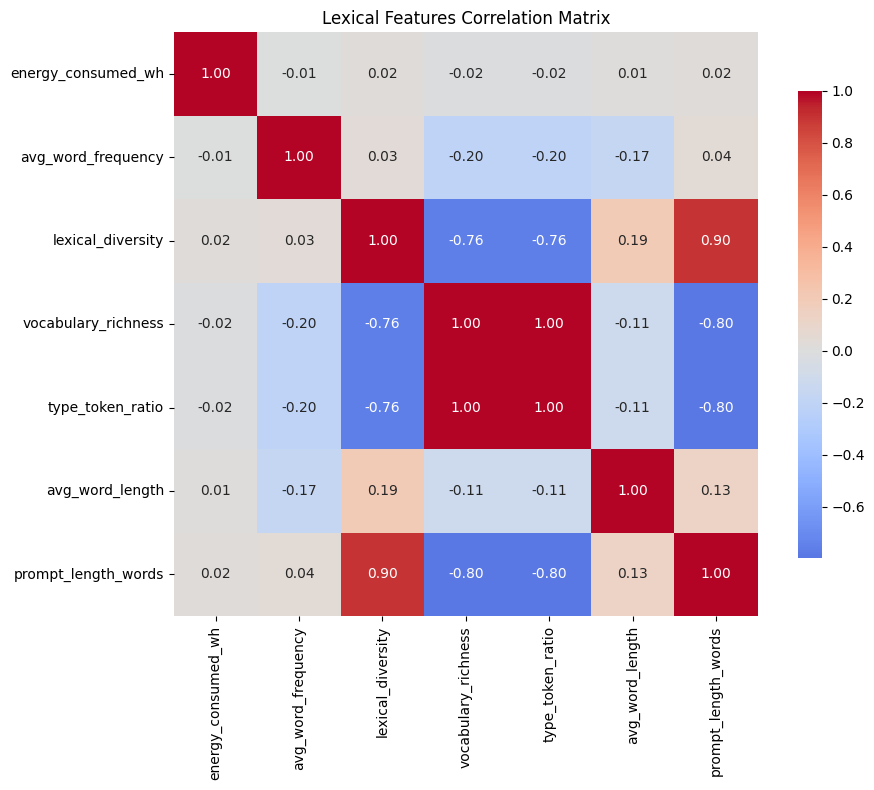

In [ ]:
# Lexical features correlation analysis
if available_lexical:
    corr_features = ['energy_consumed_wh'] + available_lexical
    correlation_matrix = data[corr_features].corr()
    
    plt.figure(figsize=(20, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title("Lexical Features Correlation Matrix")
    plt.tight_layout()
    plt.show()


## 4. Text Complexity Features Analysis


Text Complexity Features Analysis:
Available complexity features: ['syntactic_tree_depth', 'clause_count', 'flesch_kincaid_grade', 'gunning_fog_index', 'smog_index', 'avg_sentence_length_prompt', 'sentence_count', 'prompt_length_words', 'prompt_length_chars']

Correlation with Energy Consumption:
energy_consumed_wh            1.000000
prompt_length_chars           0.027317
prompt_length_words           0.024429
clause_count                  0.022093
sentence_count                0.019455
syntactic_tree_depth          0.015675
flesch_kincaid_grade          0.003740
smog_index                    0.002160
gunning_fog_index             0.001132
avg_sentence_length_prompt   -0.003148
Name: energy_consumed_wh, dtype: float64


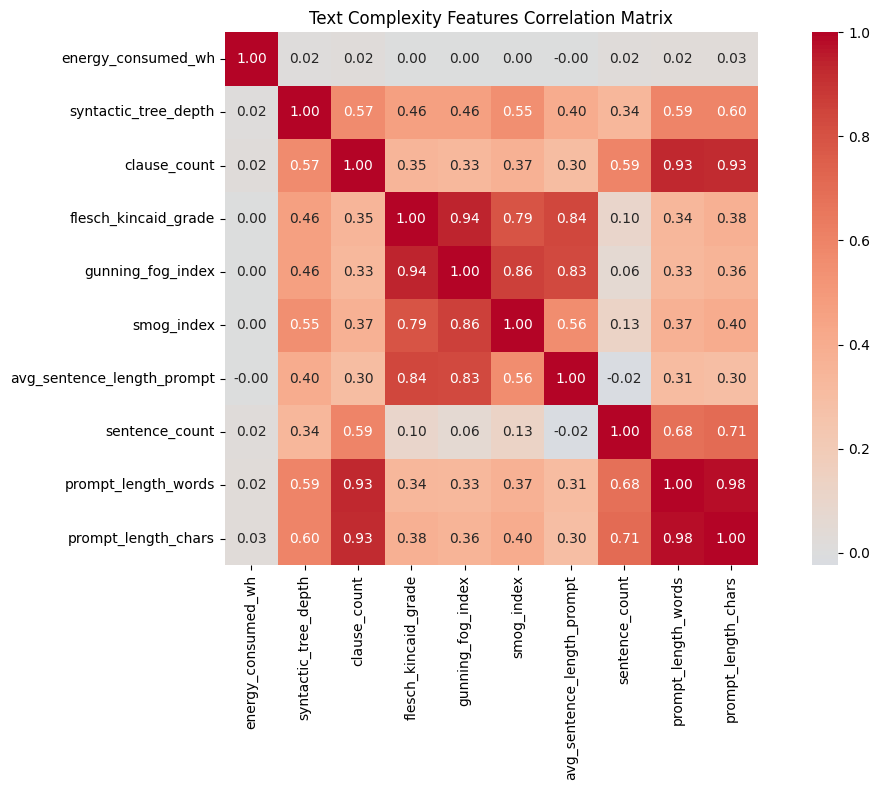

In [ ]:
# Comprehensive text complexity analysis
print("Text Complexity Features Analysis:")
print("=" * 45)

# Text complexity features
complexity_features = [
    'syntactic_tree_depth', 'clause_count', 'flesch_kincaid_grade', 
    'gunning_fog_index', 'smog_index', 'avg_sentence_length_prompt',
    'sentence_count', 'prompt_length_words', 'prompt_length_chars'
]

# Check which features exist in the dataset
available_features = [f for f in complexity_features if f in data.columns]
print(f"Available complexity features: {available_features}")

# Correlation analysis
if available_features:
    corr_features = ['energy_consumed_wh'] + available_features
    correlation_matrix = data[corr_features].corr()
    print("\nCorrelation with Energy Consumption:")
    energy_corr = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
    print(energy_corr)
    
    # Visualize correlations
    plt.figure(figsize=(20, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f')
    plt.title("Text Complexity Features Correlation Matrix")
    plt.tight_layout()
    plt.show()


Text Complexity Distribution Analysis:

Statistical Summary of Text Complexity Features:
       syntactic_tree_depth  clause_count  flesch_kincaid_grade  \
count          20709.000000  20709.000000          20709.000000   
mean               5.563282      6.738809              7.772531   
std                3.049273     11.922437              7.258165   
min                1.000000      0.000000             -2.620000   
25%                3.000000      1.000000              3.890270   
50%                5.000000      2.000000              6.960000   
75%                7.000000      6.000000             10.315634   
max               73.000000    102.000000            184.705641   

       gunning_fog_index    smog_index  avg_sentence_length_prompt  \
count       20709.000000  20709.000000                20709.000000   
mean           10.269570      9.533413                   13.537091   
std             7.601790      4.689387                   15.166989   
min             1.200000   

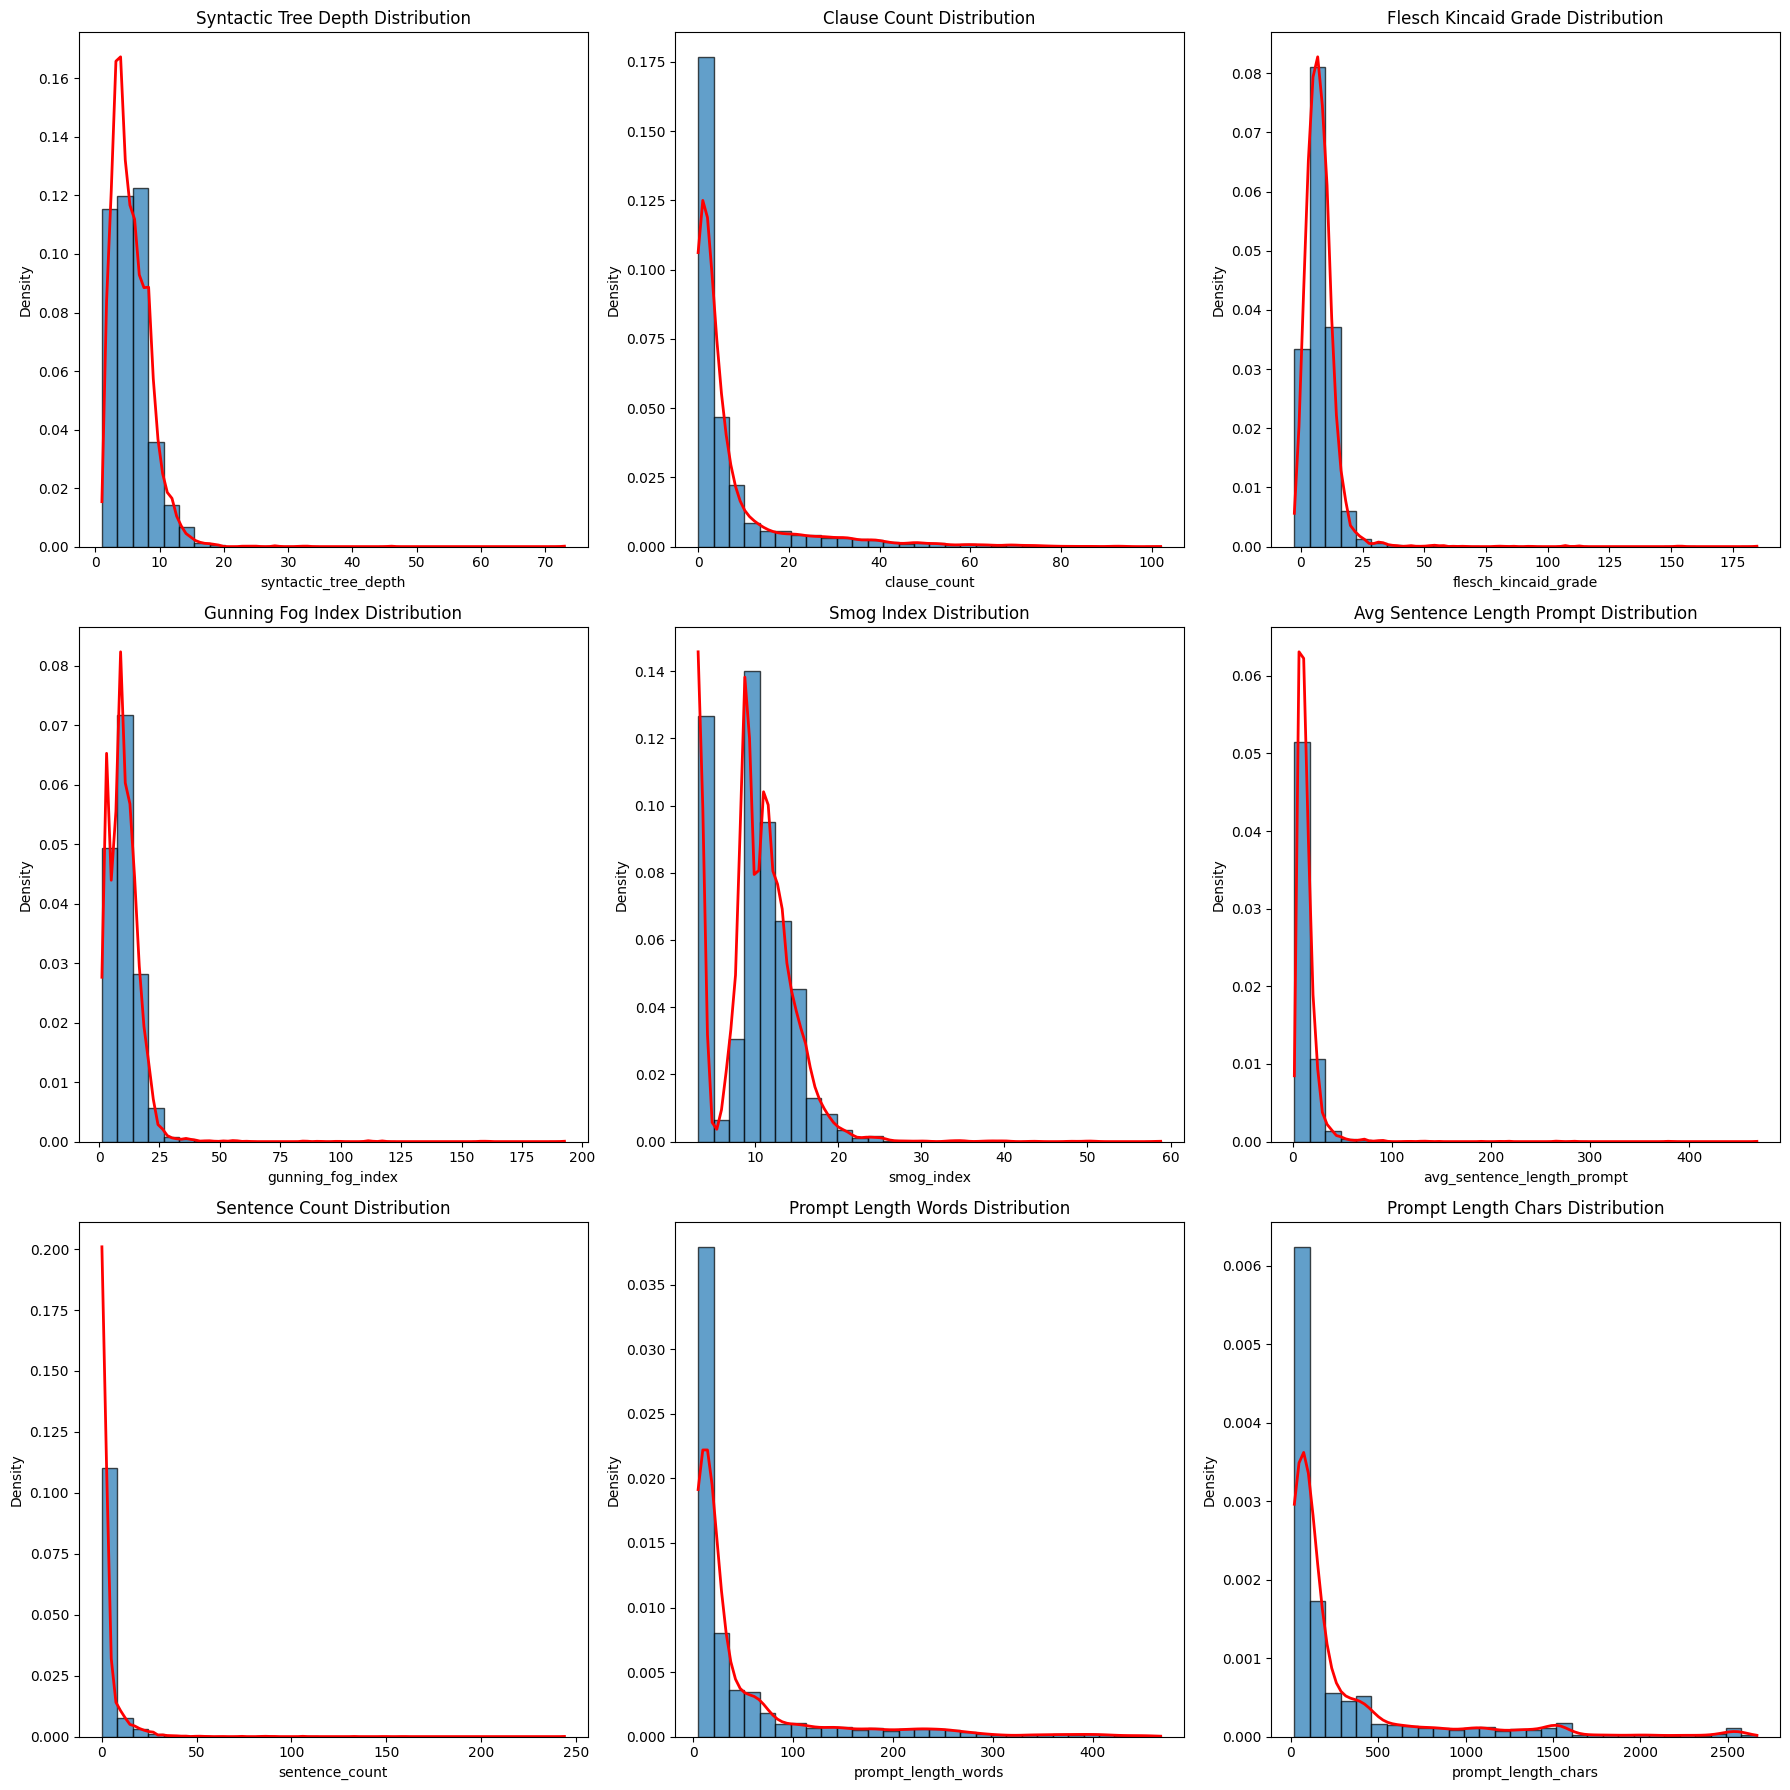

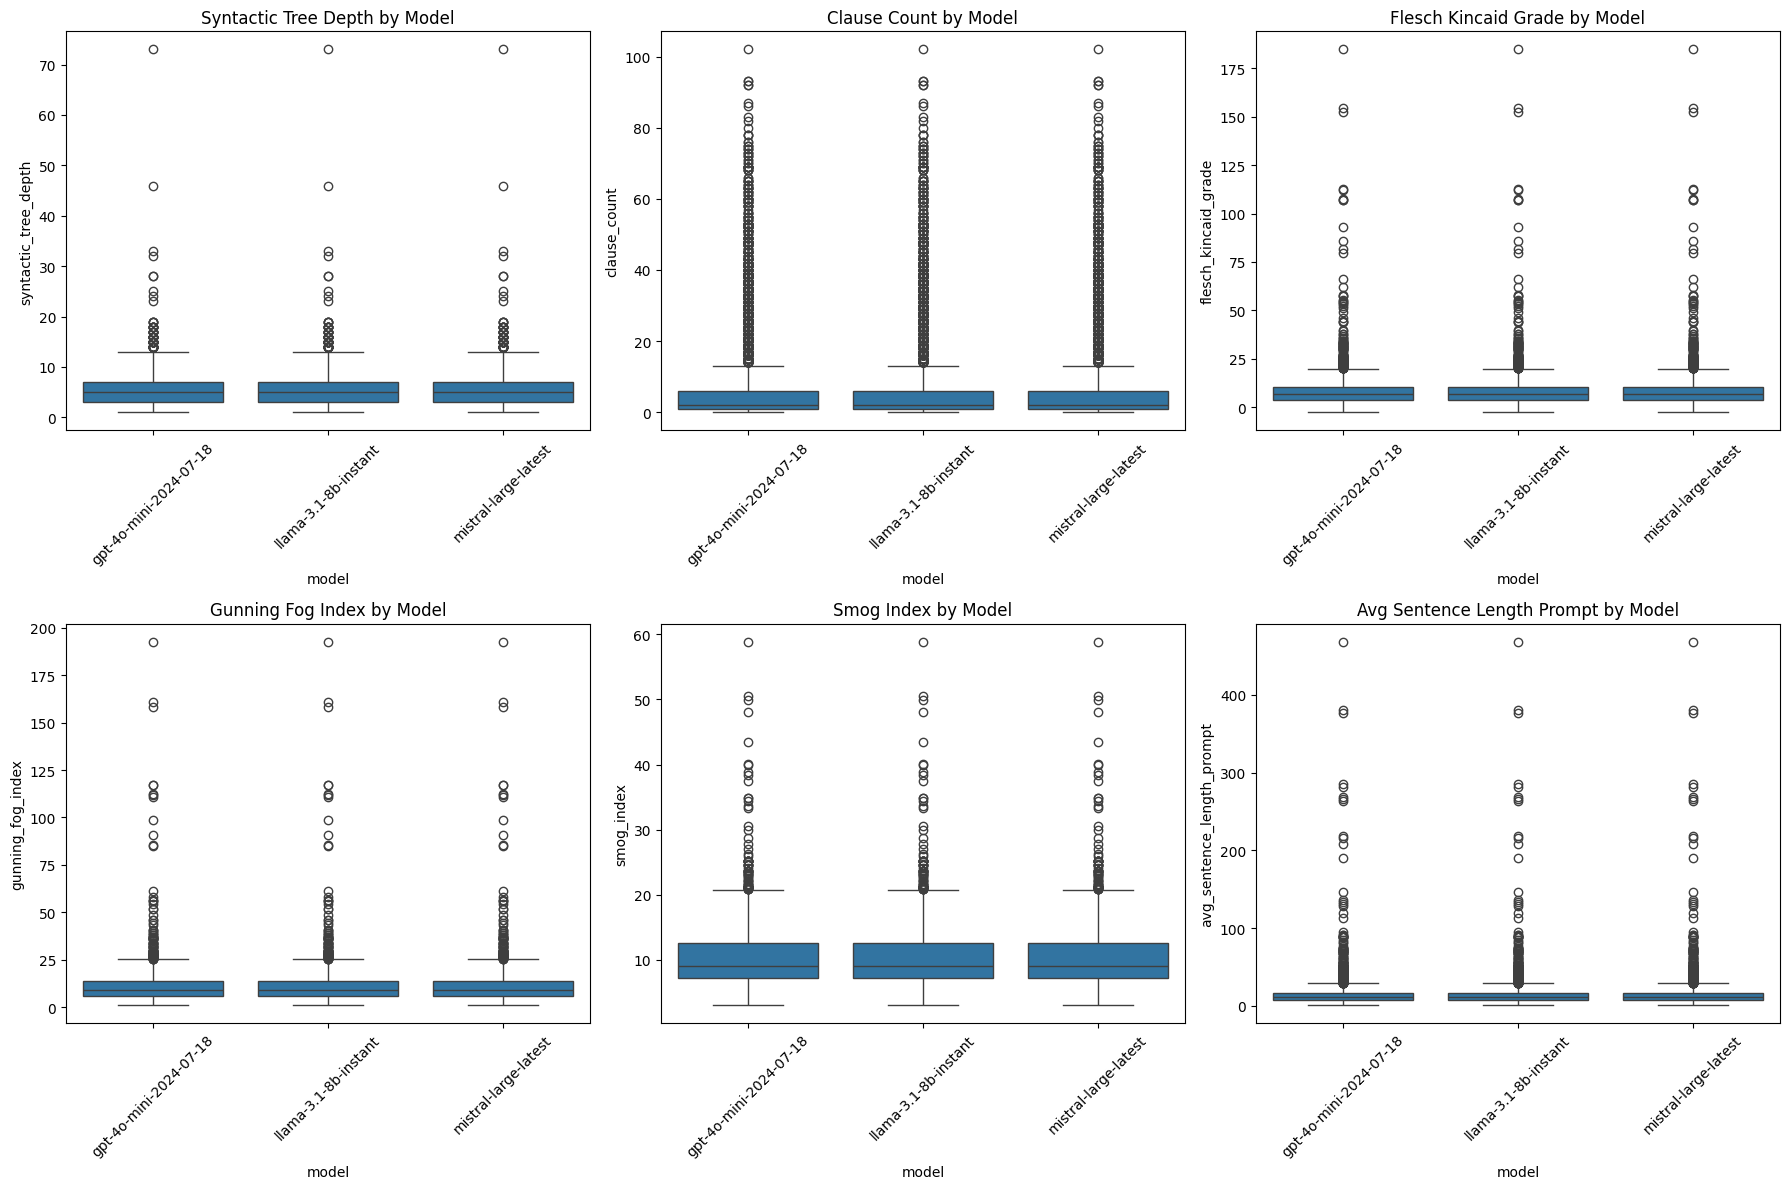

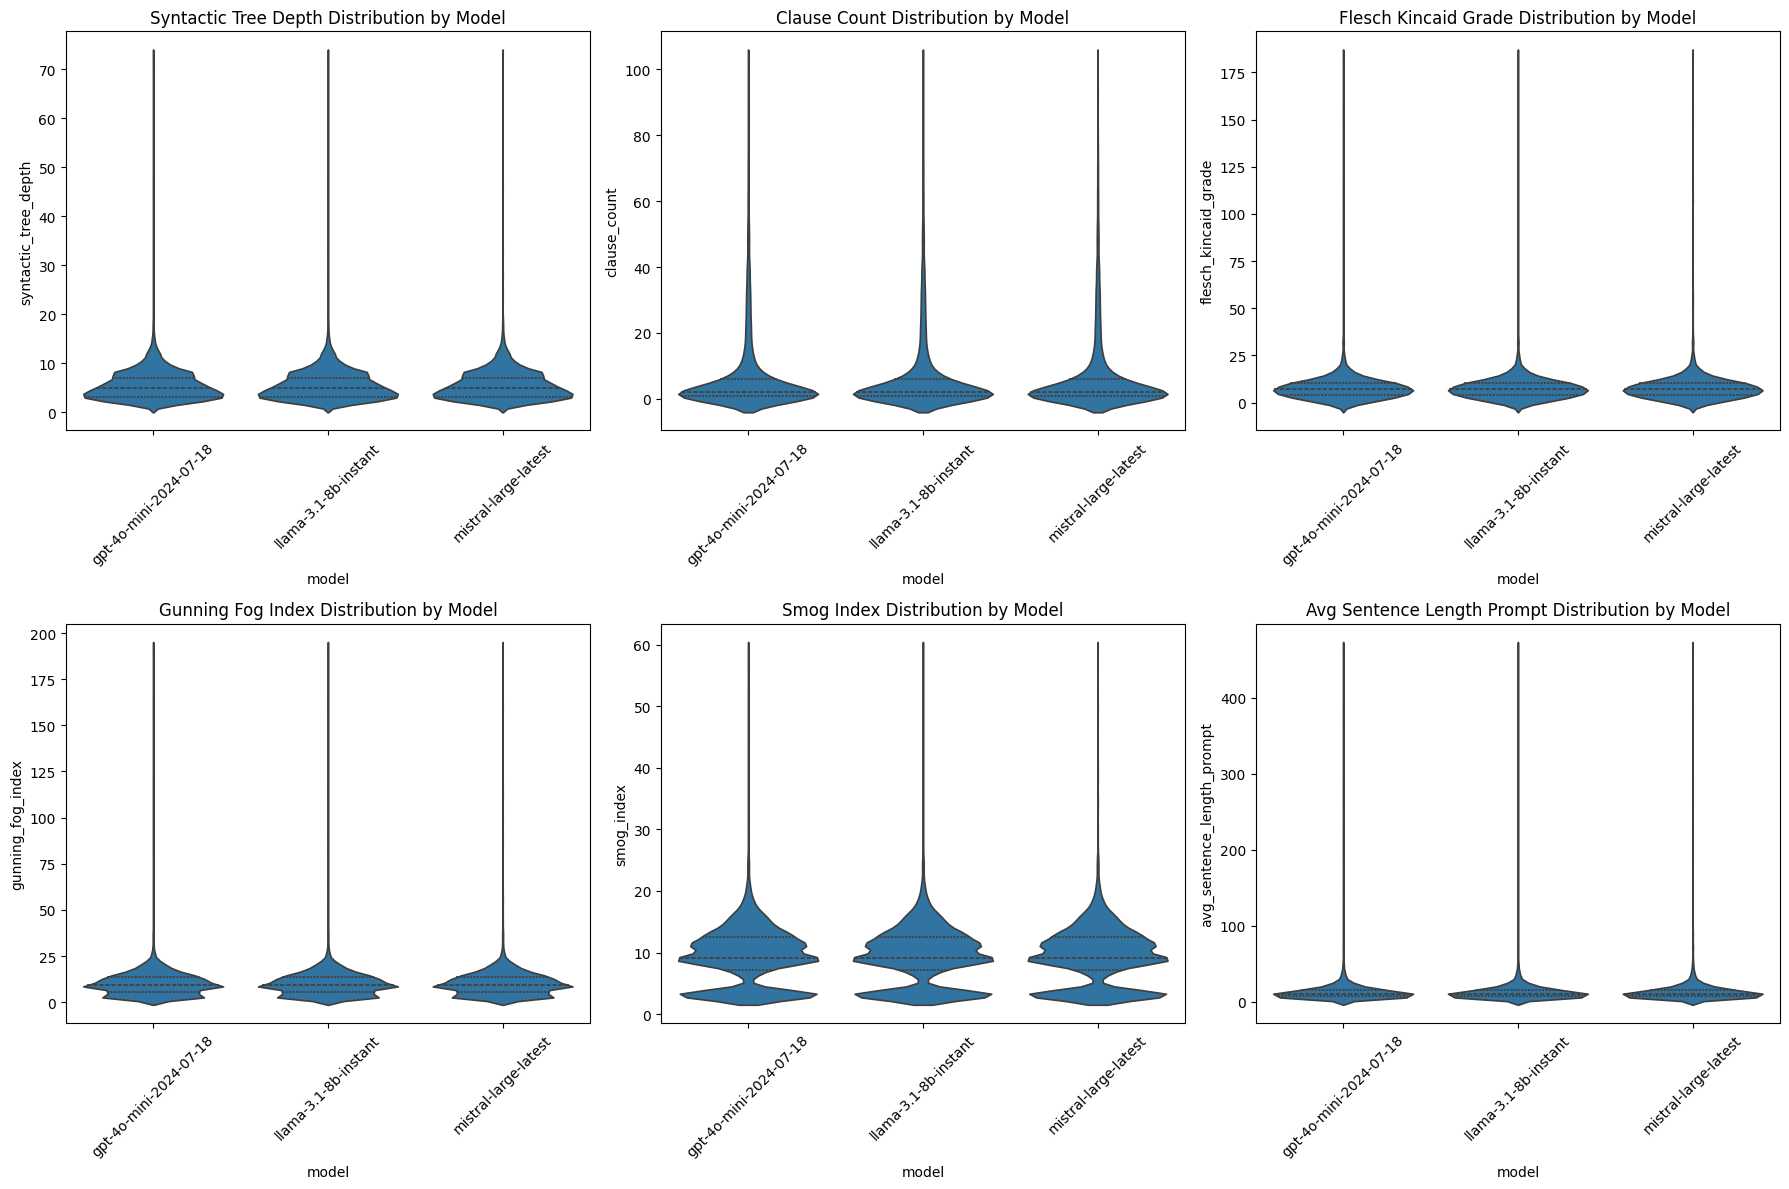

In [ ]:
# Comprehensive distribution analysis of text complexity features
print("Text Complexity Distribution Analysis:")
print("=" * 45)

if available_features:
    # Statistical summary for complexity features
    print("\nStatistical Summary of Text Complexity Features:")
    complexity_stats = data[available_features].describe()
    print(complexity_stats)
    
    # Create comprehensive distribution plots
    n_features = len(available_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.ravel()
    
    for i, feature in enumerate(available_features):
        # Histogram with KDE
        axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
        # Add KDE line
        from scipy import stats
        kde = stats.gaussian_kde(data[feature].dropna())
        x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
        axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
        axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Density')
    
    # Hide unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Box plots for complexity features by model
    if len(available_features) > 0:
        n_plot_features = min(len(available_features), 6)
        n_cols = 3
        n_rows = (n_plot_features + n_cols - 1) // n_cols
        
        plt.figure(figsize=(18, 6*n_rows))
        for i, feature in enumerate(available_features[:n_plot_features], 1):
            plt.subplot(n_rows, n_cols, i)
            sns.boxplot(data=data, x='model', y=feature)
            plt.title(f'{feature.replace("_", " ").title()} by Model')
            plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    # Violin plots for complexity features by model
    if len(available_features) > 0:
        n_plot_features = min(len(available_features), 6)
        n_cols = 3
        n_rows = (n_plot_features + n_cols - 1) // n_cols
        
        plt.figure(figsize=(18, 6*n_rows))
        for i, feature in enumerate(available_features[:n_plot_features], 1):
            plt.subplot(n_rows, n_cols, i)
            sns.violinplot(data=data, x='model', y=feature, inner='quartile')
            plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
            plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


Model-wise Text Complexity Analysis:

Model-wise Statistical Summary:
                       syntactic_tree_depth                clause_count  \
                                       mean    std min max         mean   
model                                                                     
gpt-4o-mini-2024-07-18                5.563  3.050   1  73        6.739   
llama-3.1-8b-instant                  5.563  3.049   1  73        6.739   
mistral-large-latest                  5.564  3.049   1  73        6.738   

                                        flesch_kincaid_grade         ...  \
                           std min  max                 mean    std  ...   
model                                                                ...   
gpt-4o-mini-2024-07-18  11.924   0  102                7.771  7.258  ...   
llama-3.1-8b-instant    11.923   0  102                7.773  7.259  ...   
mistral-large-latest    11.922   0  102                7.773  7.258  ...   

                      

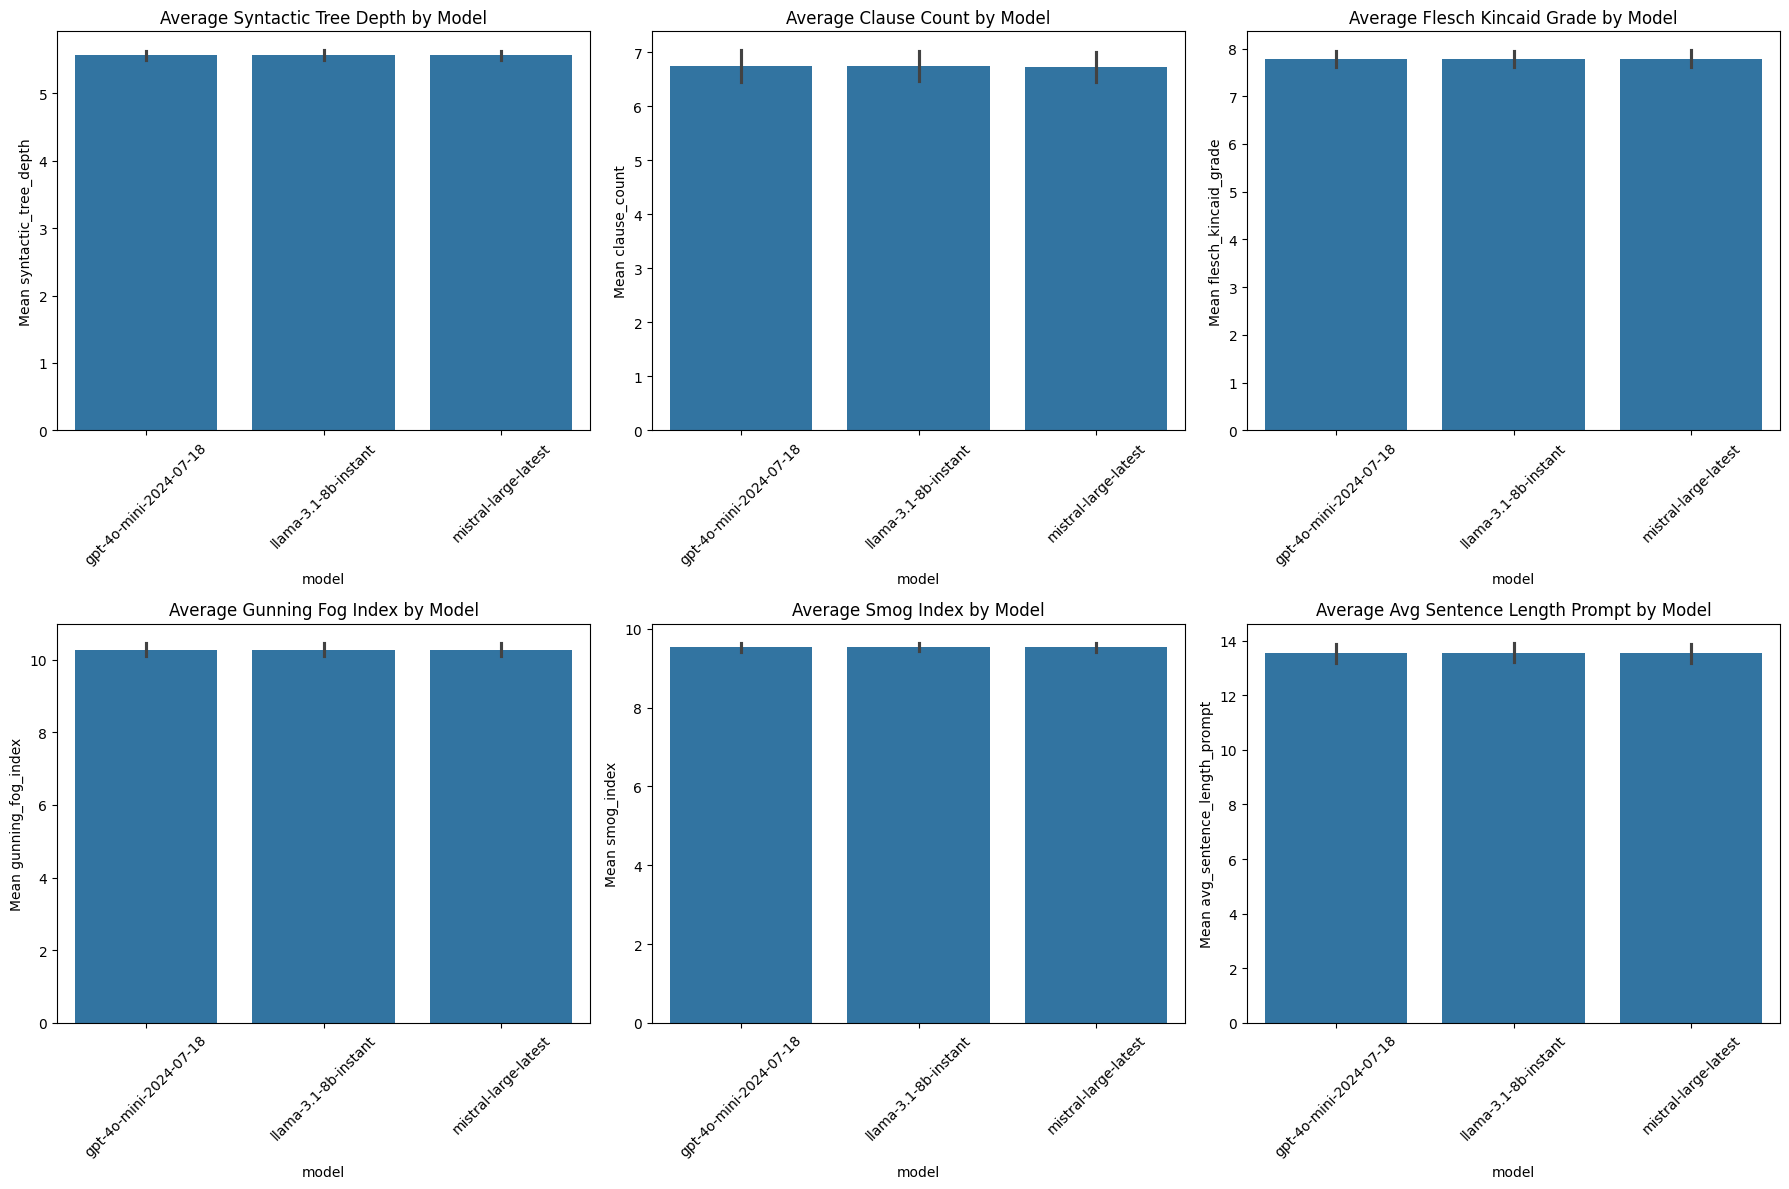


Statistical Significance Tests (ANOVA/Kruskal-Wallis):
syntactic_tree_depth:
  ANOVA: F=0.000, p=0.999940
  Kruskal-Wallis: H=0.000, p=0.999877

clause_count:
  ANOVA: F=0.000, p=0.999989
  Kruskal-Wallis: H=0.000, p=0.999981

flesch_kincaid_grade:
  ANOVA: F=0.000, p=0.999881
  Kruskal-Wallis: H=0.001, p=0.999725

gunning_fog_index:
  ANOVA: F=0.000, p=0.999873
  Kruskal-Wallis: H=0.001, p=0.999724

smog_index:
  ANOVA: F=0.000, p=0.999735
  Kruskal-Wallis: H=0.001, p=0.999683

avg_sentence_length_prompt:
  ANOVA: F=0.000, p=0.999947
  Kruskal-Wallis: H=0.000, p=0.999774

sentence_count:
  ANOVA: F=0.000, p=0.999974
  Kruskal-Wallis: H=0.000, p=0.999776

prompt_length_words:
  ANOVA: F=0.000, p=0.999983
  Kruskal-Wallis: H=0.000, p=0.999984

prompt_length_chars:
  ANOVA: F=0.000, p=0.999987
  Kruskal-Wallis: H=0.000, p=0.999962



In [ ]:
# Model-wise comparison analysis for text complexity features
print("Model-wise Text Complexity Analysis:")
print("=" * 45)

if available_features:
    # Model-wise statistical summary
    print("\nModel-wise Statistical Summary:")
    model_complexity_stats = data.groupby('model')[available_features].agg(['mean', 'std', 'min', 'max']).round(3)
    print(model_complexity_stats)
    
    # Model-wise comparison plots
    n_features = min(len(available_features), 6)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    plt.figure(figsize=(18, 6*n_rows))
    for i, feature in enumerate(available_features[:n_features], 1):
        plt.subplot(n_rows, n_cols, i)
        sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
        plt.title(f'Average {feature.replace("_", " ").title()} by Model')
        plt.xticks(rotation=45)
        plt.ylabel(f'Mean {feature}')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical significance testing between models
    from scipy.stats import f_oneway, kruskal
    
    print("\nStatistical Significance Tests (ANOVA/Kruskal-Wallis):")
    for feature in available_features:
        groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
        
        # ANOVA test
        f_stat, p_value_anova = f_oneway(*groups)
        
        # Kruskal-Wallis test (non-parametric)
        h_stat, p_value_kw = kruskal(*groups)
        
        print(f"{feature}:")
        print(f"  ANOVA: F={f_stat:.3f}, p={p_value_anova:.6f}")
        print(f"  Kruskal-Wallis: H={h_stat:.3f}, p={p_value_kw:.6f}")
        print()


Energy Consumption by Text Complexity Ranges:

Syntactic Tree Depth Analysis:
----------------------------------------
Energy consumption by syntactic_tree_depth groups:
                            count    mean     std     min     max
syntactic_tree_depth_group                                       
(0.927, 15.4]               20595  0.0341  0.1322  0.0001  4.1653
(15.4, 29.8]                  102  0.0703  0.2114  0.0016  1.4312
(29.8, 44.2]                    6  0.0056  0.0045  0.0025  0.0146
(44.2, 58.6]                    3  0.0064  0.0031  0.0030  0.0090
(58.6, 73.0]                    3  0.0176  0.0024  0.0156  0.0202


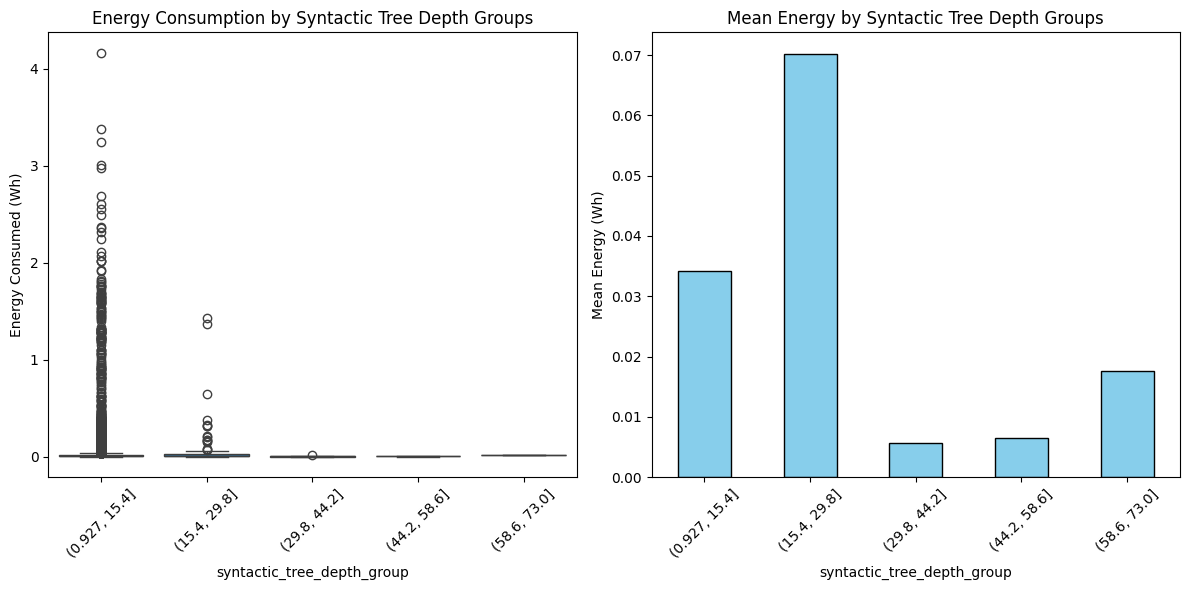


Clause Count Analysis:
----------------------------------------
Energy consumption by clause_count groups:
                    count    mean     std     min     max
clause_count_group                                       
(-0.103, 20.4]      18693  0.0333  0.1250  0.0001  4.1653
(20.4, 40.8]         1362  0.0430  0.1957  0.0013  3.3750
(40.8, 61.2]          462  0.0500  0.2055  0.0017  2.3529
(61.2, 81.6]          165  0.0257  0.0503  0.0018  0.4484
(81.6, 102.0]          27  0.0310  0.0695  0.0018  0.3342


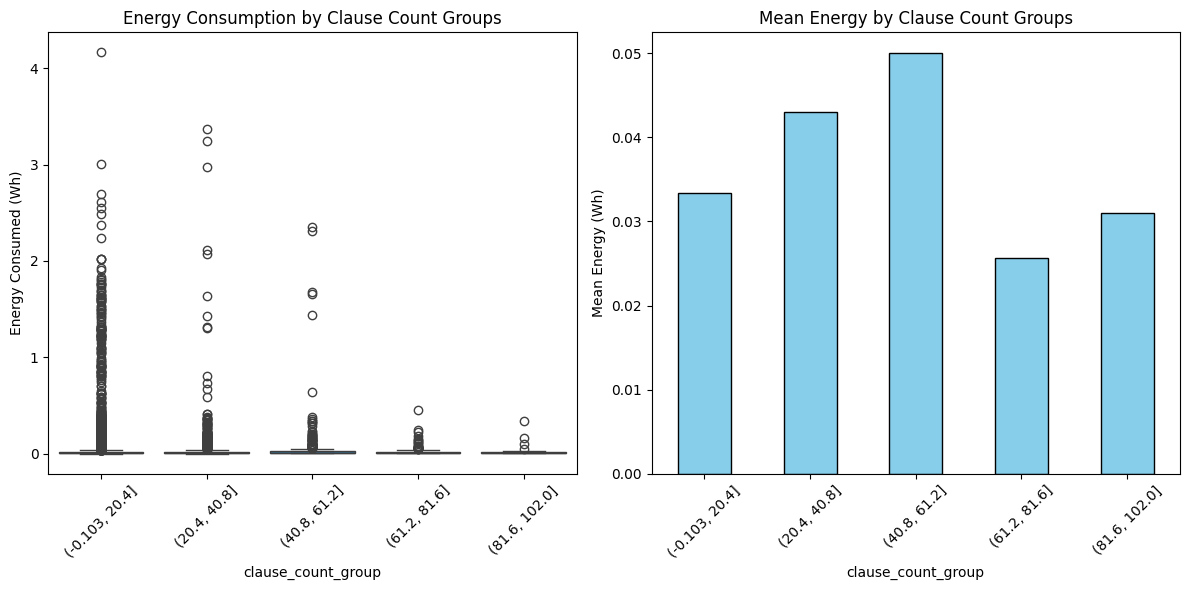


Flesch Kincaid Grade Analysis:
----------------------------------------
Energy consumption by flesch_kincaid_grade groups:
                            count    mean     std     min     max
flesch_kincaid_grade_group                                       
(-2.621, 3.209]              4146  0.0324  0.1179  0.0001  2.5488
(3.209, 5.849]               4140  0.0340  0.1144  0.0001  2.3730
(5.849, 8.276]               4140  0.0353  0.1435  0.0001  4.1653
(8.276, 11.109]              4143  0.0355  0.1434  0.0001  3.2474
(11.109, 184.706]            4140  0.0342  0.1411  0.0002  3.3750


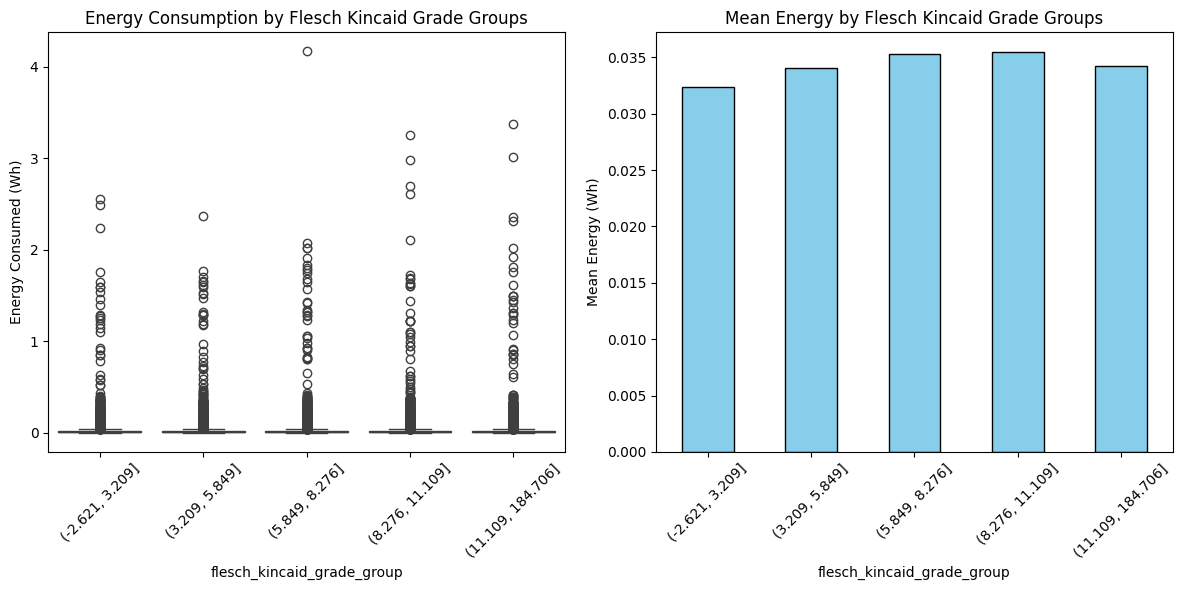


Gunning Fog Index Analysis:
----------------------------------------
Energy consumption by gunning_fog_index groups:
                         count    mean     std     min     max
gunning_fog_index_group                                       
(1.199, 4.4]              4338  0.0330  0.1221  0.0001  2.5488
(4.4, 8.2]                4149  0.0358  0.1301  0.0001  2.3730
(8.2, 11.267]             3945  0.0324  0.1115  0.0002  2.6072
(11.267, 14.358]          4137  0.0358  0.1579  0.0013  4.1653
(14.358, 192.585]         4140  0.0343  0.1369  0.0001  3.3750


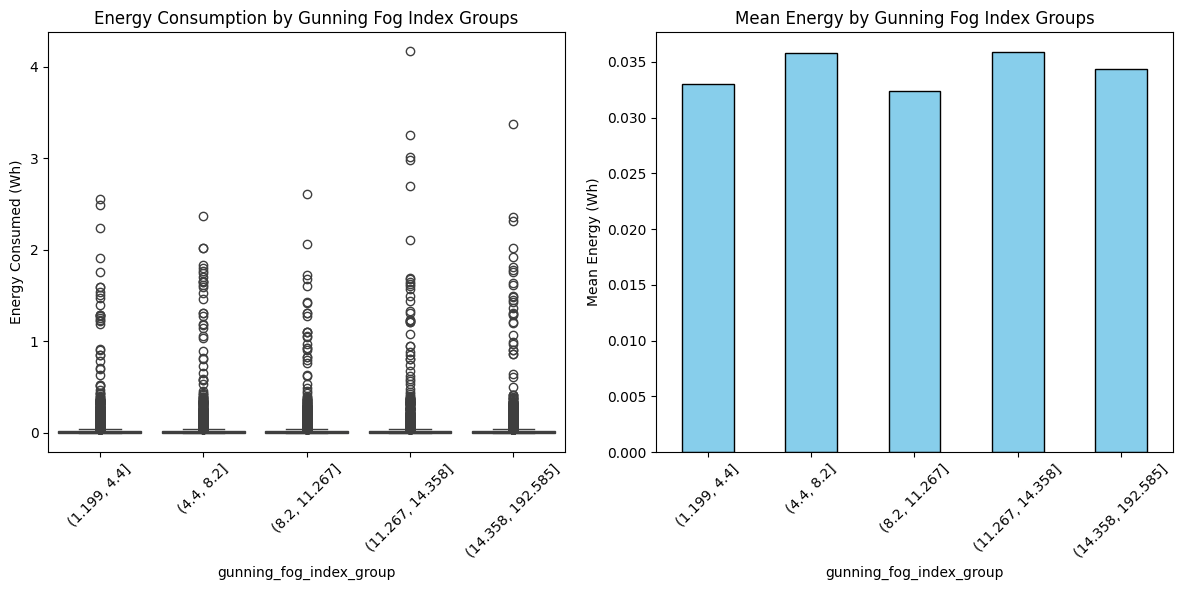


Smog Index Analysis:
----------------------------------------
Energy consumption by smog_index groups:
                  count    mean     std     min     max
smog_index_group                                       
(3.128, 8.842]    10338  0.0341  0.1215  0.0001  2.6072
(8.842, 11.208]    4134  0.0365  0.1536  0.0013  4.1653
(11.208, 13.024]   2766  0.0321  0.1469  0.0014  3.2474
(13.024, 58.81]    3471  0.0339  0.1255  0.0001  2.3529


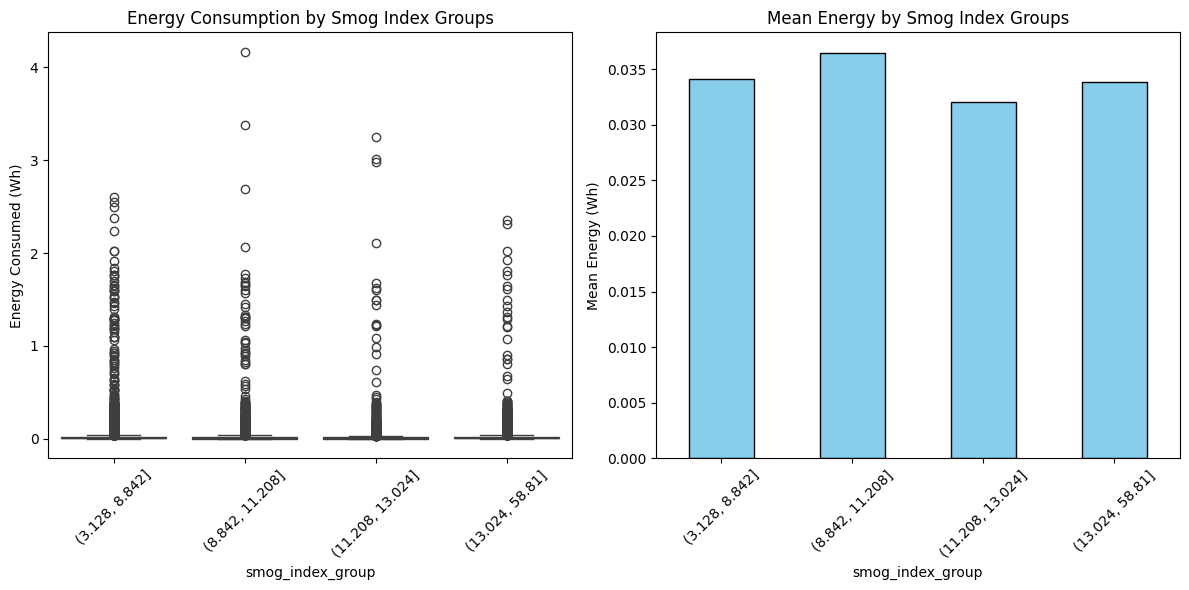


Avg Sentence Length Prompt Analysis:
----------------------------------------
Energy consumption by avg_sentence_length_prompt groups:
                                  count    mean     std     min     max
avg_sentence_length_prompt_group                                       
(1.493, 7.0]                       5136  0.0331  0.1208  0.0001  3.3750
(7.0, 9.0]                         3171  0.0357  0.1546  0.0001  4.1653
(9.0, 12.875]                      4125  0.0366  0.1336  0.0001  2.0682
(12.875, 17.0]                     4138  0.0348  0.1401  0.0002  3.0095
(17.0, 468.0]                      4139  0.0317  0.1194  0.0002  2.9756


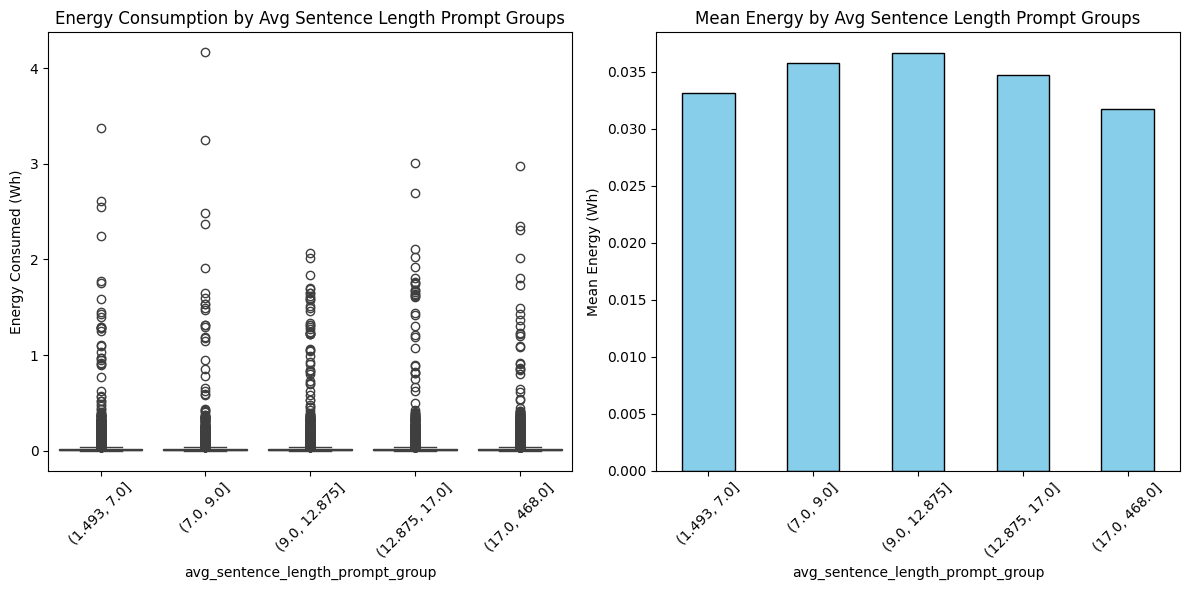


Sentence Count Analysis:
----------------------------------------
Energy consumption by sentence_count groups:
                      count    mean     std     min     max
sentence_count_group                                       
(-0.245, 48.8]        20646  0.0343  0.1329  0.0001  4.1653
(48.8, 97.6]             45  0.0275  0.0584  0.0017  0.3224
(97.6, 146.4]             9  0.0096  0.0033  0.0044  0.0150
(146.4, 195.2]            6  0.0086  0.0058  0.0022  0.0175
(195.2, 244.0]            3  0.0066  0.0038  0.0023  0.0094


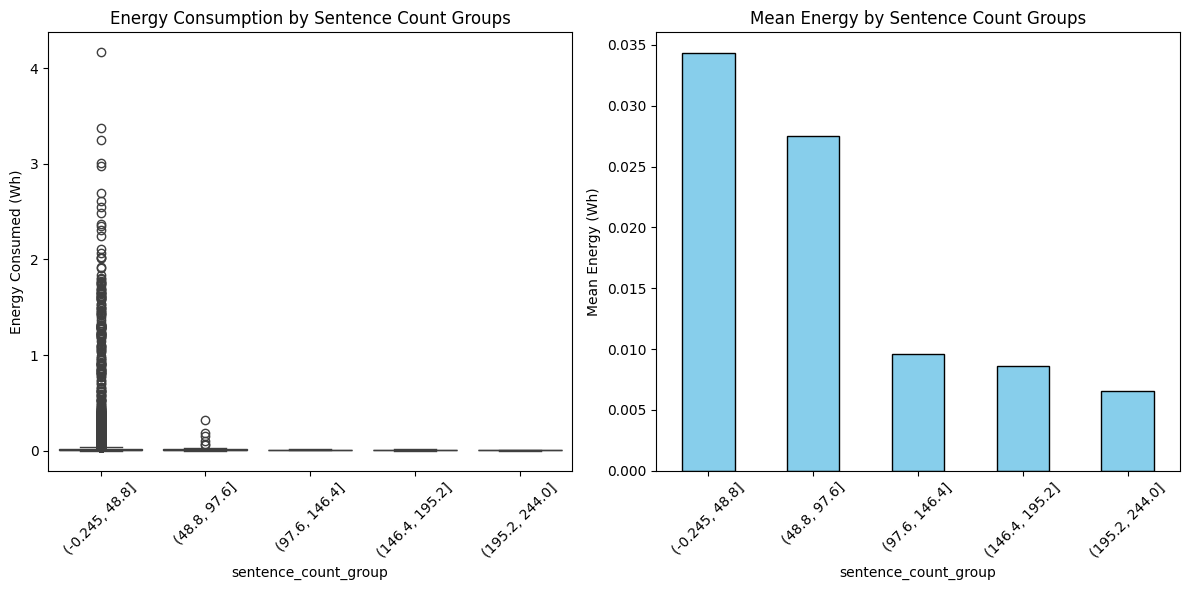


Prompt Length Words Analysis:
----------------------------------------
Energy consumption by prompt_length_words groups:
                           count    mean     std     min     max
prompt_length_words_group                                       
(4.999, 8.0]                4842  0.0321  0.1066  0.0001  2.6072
(8.0, 13.0]                 3879  0.0342  0.1365  0.0001  3.0095
(13.0, 21.0]                3709  0.0331  0.1176  0.0002  2.0176
(21.0, 63.0]                4205  0.0330  0.1371  0.0001  4.1653
(63.0, 468.0]               4074  0.0394  0.1620  0.0013  3.3750


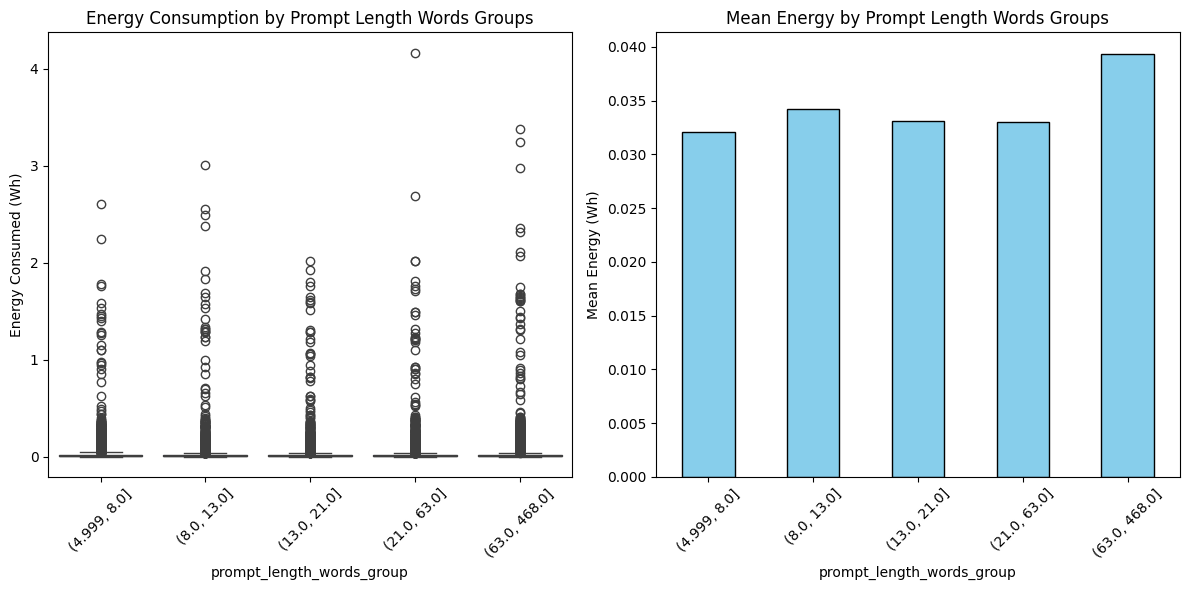


Prompt Length Chars Analysis:
----------------------------------------
Energy consumption by prompt_length_chars groups:
                           count    mean     std     min     max
prompt_length_chars_group                                       
(19.999, 43.0]              4296  0.0335  0.1170  0.0001  2.6072
(43.0, 72.0]                4086  0.0329  0.1216  0.0001  2.5488
(72.0, 126.0]               4083  0.0307  0.1151  0.0001  3.0095
(126.0, 393.0]              4104  0.0345  0.1405  0.0001  4.1653
(393.0, 2667.0]             4140  0.0399  0.1631  0.0013  3.3750


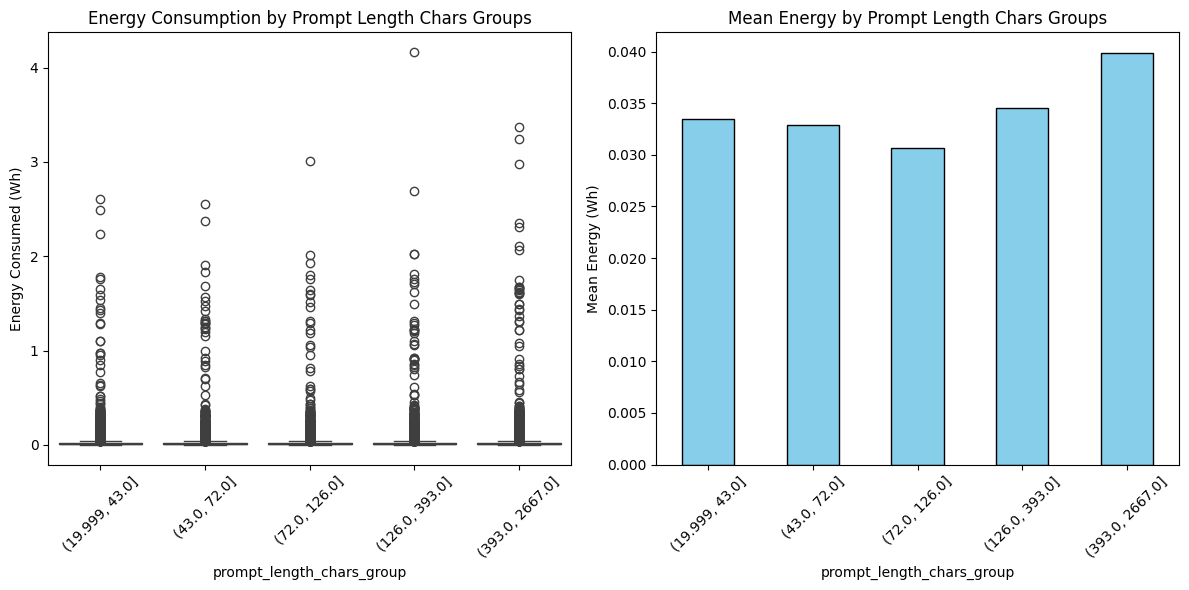

In [ ]:
# Energy consumption analysis by text complexity feature ranges
print("Energy Consumption by Text Complexity Ranges:")
print("=" * 50)

if available_features:
    # Analyze energy consumption by complexity feature quantiles
    for feature in available_features:
        print(f"\n{feature.replace('_', ' ').title()} Analysis:")
        print("-" * 40)
        
        # Create quantile-based groups
        try:
            # Use qcut for continuous features, cut for discrete
            if feature in ['syntactic_tree_depth', 'clause_count', 'sentence_count']:
                # Discrete features - use cut
                data[f'{feature}_group'] = pd.cut(data[feature], bins=5, include_lowest=True)
            else:
                # Continuous features - use qcut
                data[f'{feature}_group'] = pd.qcut(data[feature], q=5, duplicates='drop')
            
            # Calculate energy statistics by group
            energy_by_group = data.groupby(f'{feature}_group')['energy_consumed_wh'].agg([
                'count', 'mean', 'std', 'min', 'max'
            ]).round(4)
            
            print(f"Energy consumption by {feature} groups:")
            print(energy_by_group)
            
            # Visualize energy consumption by complexity groups
            plt.figure(figsize=(20, 6))
            
            # Box plot
            plt.subplot(1, 2, 1)
            sns.boxplot(data=data, x=f'{feature}_group', y='energy_consumed_wh')
            plt.title(f'Energy Consumption by {feature.replace("_", " ").title()} Groups')
            plt.xticks(rotation=45)
            plt.ylabel('Energy Consumed (Wh)')
            
            # Bar plot of means
            plt.subplot(1, 2, 2)
            energy_means = data.groupby(f'{feature}_group')['energy_consumed_wh'].mean()
            energy_means.plot(kind='bar', color='skyblue', edgecolor='black')
            plt.title(f'Mean Energy by {feature.replace("_", " ").title()} Groups')
            plt.xticks(rotation=45)
            plt.ylabel('Mean Energy (Wh)')
            
            plt.tight_layout()
            plt.show()
            
            # Clean up temporary column
            data.drop(f'{feature}_group', axis=1, inplace=True)
            
        except Exception as e:
            print(f"Error analyzing {feature}: {str(e)}")
            continue


Text Complexity Correlation Analysis:


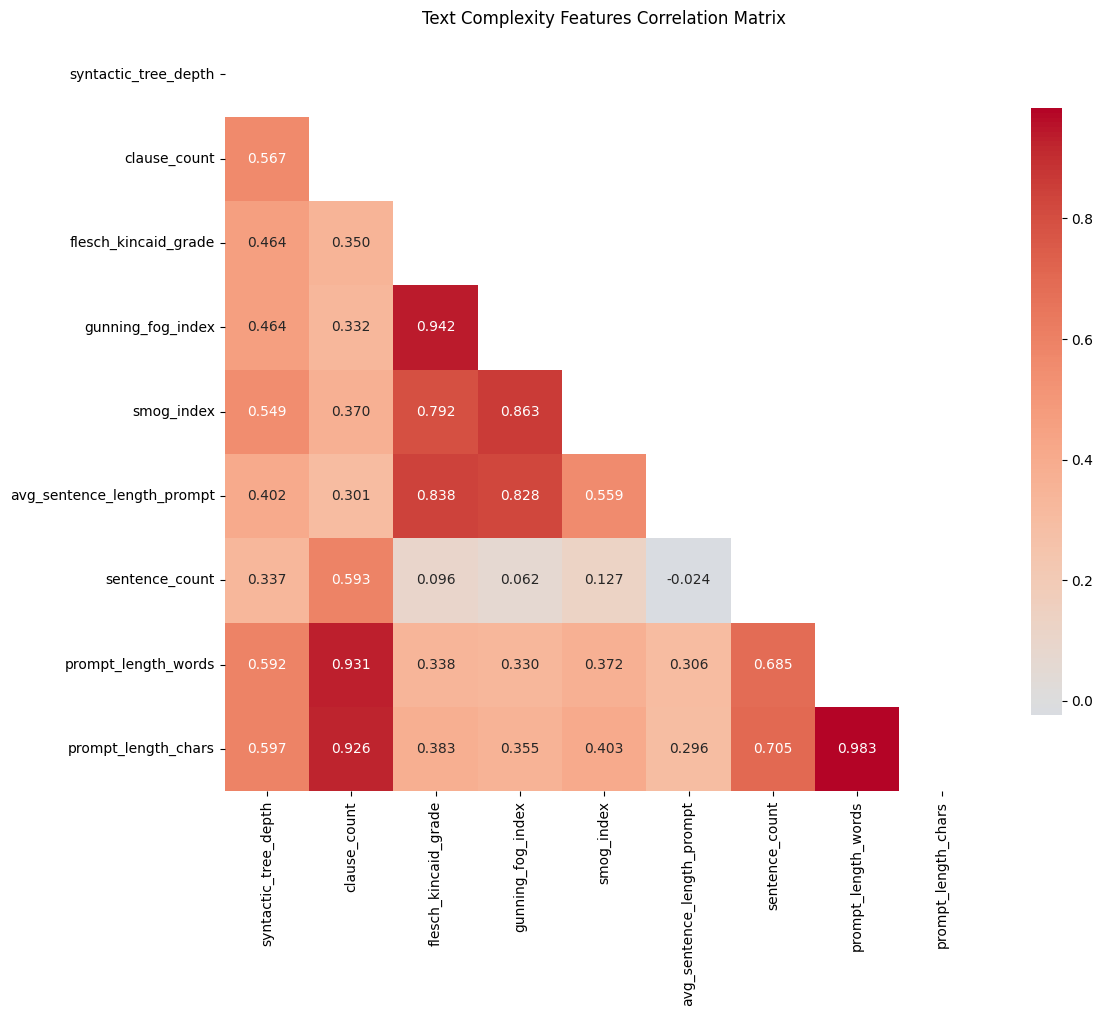

Correlation with Energy Consumption:
energy_consumed_wh            1.000000
prompt_length_chars           0.027317
prompt_length_words           0.024429
clause_count                  0.022093
sentence_count                0.019455
syntactic_tree_depth          0.015675
flesch_kincaid_grade          0.003740
smog_index                    0.002160
gunning_fog_index             0.001132
avg_sentence_length_prompt   -0.003148
Name: energy_consumed_wh, dtype: float64


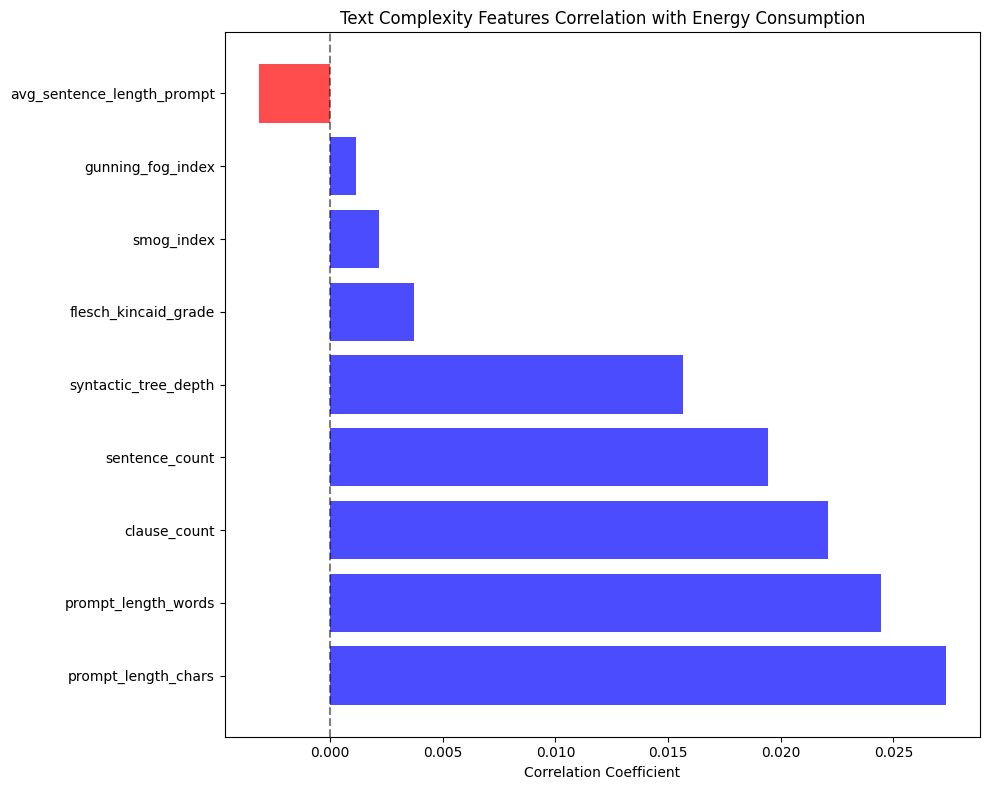

In [ ]:
# Comprehensive correlation analysis for text complexity features
print("Text Complexity Correlation Analysis:")
print("=" * 45)

if available_features:
    # Create correlation matrix for complexity features
    complexity_corr = data[available_features].corr()
    
    # Visualize correlation heatmap
    plt.figure(figsize=(20, 10))
    mask = np.triu(np.ones_like(complexity_corr, dtype=bool))
    sns.heatmap(complexity_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
    plt.title("Text Complexity Features Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
    # Correlation with energy consumption
    energy_complexity_corr = data[['energy_consumed_wh'] + available_features].corr()
    energy_correlations = energy_complexity_corr['energy_consumed_wh'].sort_values(ascending=False)
    
    print("Correlation with Energy Consumption:")
    print(energy_correlations)
    
    # Visualize energy correlations
    plt.figure(figsize=(20, 8))
    energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
    colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
    bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
    plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
    plt.xlabel('Correlation Coefficient')
    plt.title('Text Complexity Features Correlation with Energy Consumption')
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Scatter plots for top correlated features
    top_correlated = energy_correlations_clean.abs().nlargest(4).index.tolist()
    
    if len(top_correlated) > 0:
        n_plots = min(len(top_correlated), 4)
        n_cols = 2
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        plt.figure(figsize=(15, 6*n_rows))
        for i, feature in enumerate(top_correlated[:n_plots], 1):
            plt.subplot(n_rows, n_cols, i)
            sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
            plt.title(f'Energy vs {feature.replace("_", " ").title()}')
            plt.xlabel(feature)
            plt.ylabel('Energy Consumed (Wh)')
        
        plt.tight_layout()
        plt.show()


Text Complexity Insights and Patterns:
Feature Importance for Energy Consumption Prediction:
                      feature  importance
8         prompt_length_chars    0.244372
2        flesch_kincaid_grade    0.172733
3           gunning_fog_index    0.107876
5  avg_sentence_length_prompt    0.100708
1                clause_count    0.086007
7         prompt_length_words    0.080314
0        syntactic_tree_depth    0.078941
4                  smog_index    0.066391
6              sentence_count    0.062658


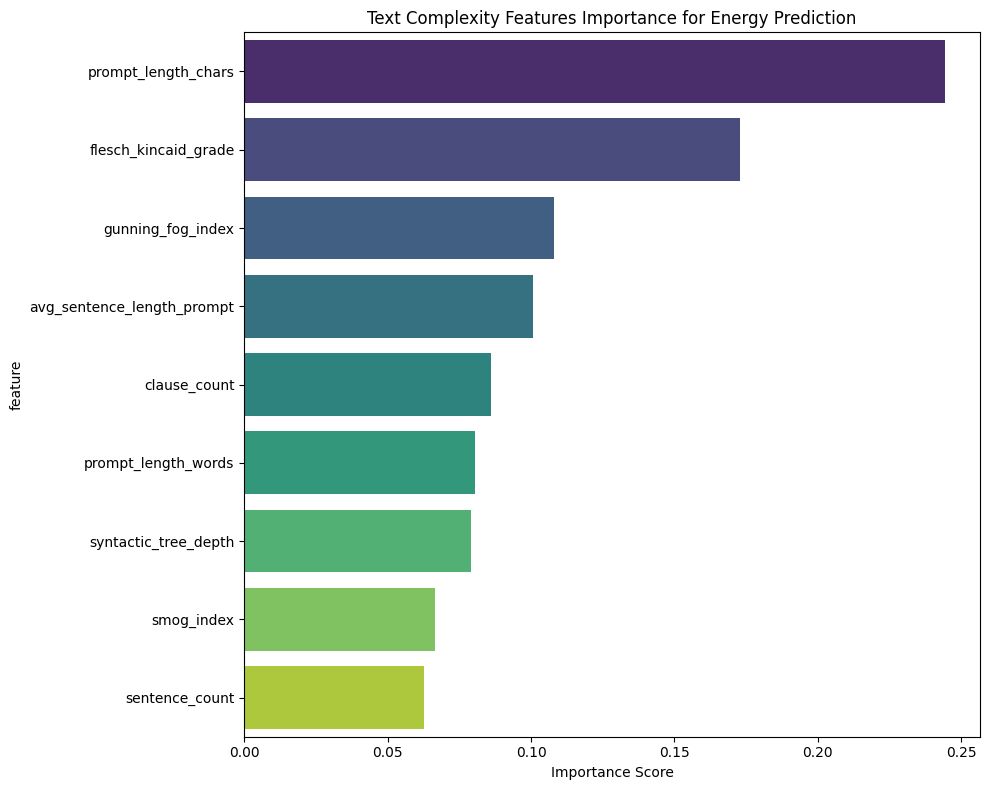


Model Performance:
R² Score: 0.3472
Mean Squared Error: 0.011495

High vs Low Complexity Analysis:
----------------------------------------
High Complexity Group: 5177 samples
Low Complexity Group: 5175 samples

Energy Consumption Comparison:
High Complexity: 0.0370 Wh (mean)
Low Complexity: 0.0322 Wh (mean)
Difference: 0.0049 Wh
T-test: t=1.8431, p=0.065345


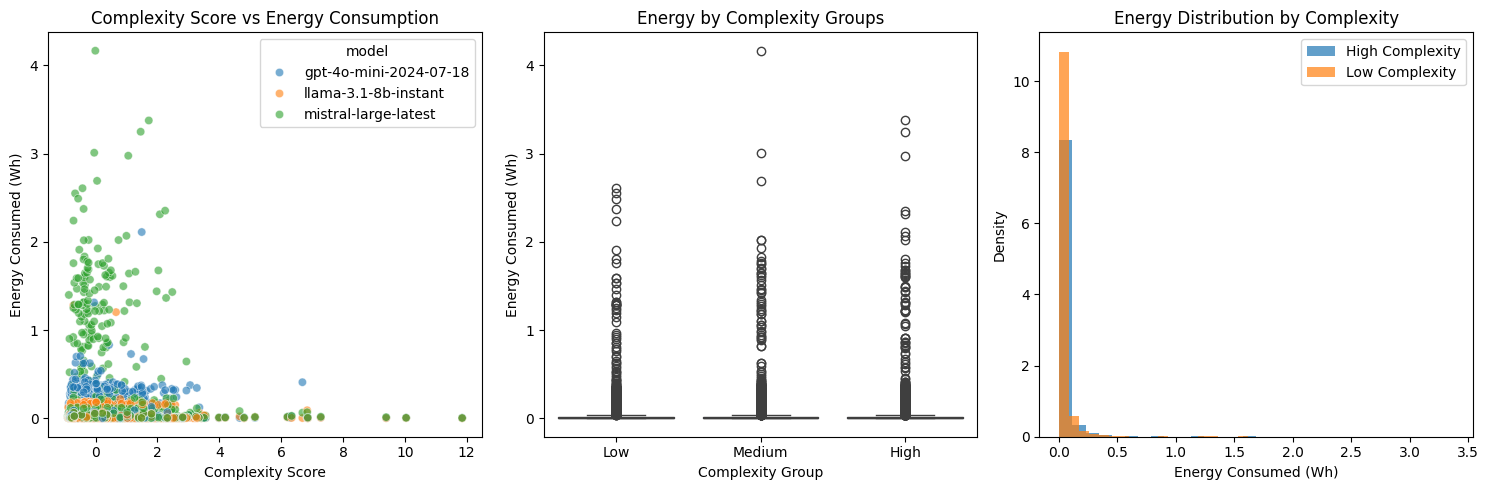


Key Insights:
--------------------
Top 3 complexity features correlated with energy:
  prompt_length_chars: 0.0273
  prompt_length_words: 0.0244
  clause_count: 0.0221

Top 3 most important features for prediction:
  prompt_length_chars: 0.2444
  flesch_kincaid_grade: 0.1727
  gunning_fog_index: 0.1079

Complexity patterns by model:
                          mean     std
model                                 
gpt-4o-mini-2024-07-18 -0.0001  0.7457
llama-3.1-8b-instant    0.0000  0.7456
mistral-large-latest    0.0000  0.7456


In [ ]:
# Comprehensive insights and patterns analysis for text complexity
print("Text Complexity Insights and Patterns:")
print("=" * 45)

if available_features:
    # Feature importance analysis using Random Forest
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score, mean_squared_error
    
    # Prepare data for feature importance analysis
    X = data[available_features].fillna(0)
    y = data['energy_consumed_wh']
    
    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Feature Importance for Energy Consumption Prediction:")
    print(feature_importance)
    
    # Visualize feature importance
    plt.figure(figsize=(20, 8))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title('Text Complexity Features Importance for Energy Prediction')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    
    # Model performance
    y_pred = rf.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    print(f"\nModel Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.6f}")
    
    # Analyze high vs low complexity groups
    print(f"\nHigh vs Low Complexity Analysis:")
    print("-" * 40)
    
    # Create complexity score (average of normalized features)
    complexity_score = data[available_features].apply(lambda x: (x - x.mean()) / x.std()).mean(axis=1)
    data['complexity_score'] = complexity_score
    
    # Define high and low complexity groups
    high_complexity = data[data['complexity_score'] > data['complexity_score'].quantile(0.75)]
    low_complexity = data[data['complexity_score'] < data['complexity_score'].quantile(0.25)]
    
    print(f"High Complexity Group: {len(high_complexity)} samples")
    print(f"Low Complexity Group: {len(low_complexity)} samples")
    
    # Compare energy consumption
    high_energy_mean = high_complexity['energy_consumed_wh'].mean()
    low_energy_mean = low_complexity['energy_consumed_wh'].mean()
    
    print(f"\nEnergy Consumption Comparison:")
    print(f"High Complexity: {high_energy_mean:.4f} Wh (mean)")
    print(f"Low Complexity: {low_energy_mean:.4f} Wh (mean)")
    print(f"Difference: {high_energy_mean - low_energy_mean:.4f} Wh")
    
    # Statistical test
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(high_complexity['energy_consumed_wh'], 
                               low_complexity['energy_consumed_wh'])
    print(f"T-test: t={t_stat:.4f}, p={p_value:.6f}")
    
    # Visualize complexity vs energy relationship
    plt.figure(figsize=(20, 5))
    
    # Scatter plot
    plt.subplot(1, 3, 1)
    sns.scatterplot(data=data, x='complexity_score', y='energy_consumed_wh', hue='model', alpha=0.6)
    plt.title('Complexity Score vs Energy Consumption')
    plt.xlabel('Complexity Score')
    plt.ylabel('Energy Consumed (Wh)')
    
    # Box plot by complexity groups
    plt.subplot(1, 3, 2)
    data['complexity_group'] = pd.qcut(data['complexity_score'], q=3, labels=['Low', 'Medium', 'High'])
    sns.boxplot(data=data, x='complexity_group', y='energy_consumed_wh')
    plt.title('Energy by Complexity Groups')
    plt.xlabel('Complexity Group')
    plt.ylabel('Energy Consumed (Wh)')
    
    # Distribution comparison
    plt.subplot(1, 3, 3)
    plt.hist(high_complexity['energy_consumed_wh'], alpha=0.7, label='High Complexity', bins=30, density=True)
    plt.hist(low_complexity['energy_consumed_wh'], alpha=0.7, label='Low Complexity', bins=30, density=True)
    plt.title('Energy Distribution by Complexity')
    plt.xlabel('Energy Consumed (Wh)')
    plt.ylabel('Density')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Key insights summary
    print(f"\nKey Insights:")
    print("-" * 20)
    
    # Top complexity features by correlation
    top_corr_features = energy_correlations_clean.abs().nlargest(3)
    print(f"Top 3 complexity features correlated with energy:")
    for feature, corr in top_corr_features.items():
        print(f"  {feature}: {corr:.4f}")
    
    # Most important features
    top_important = feature_importance.head(3)
    print(f"\nTop 3 most important features for prediction:")
    for _, row in top_important.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")
    
    # Complexity patterns by model
    print(f"\nComplexity patterns by model:")
    model_complexity = data.groupby('model')['complexity_score'].agg(['mean', 'std']).round(4)
    print(model_complexity)
    
    # Clean up temporary columns
    data.drop(['complexity_score', 'complexity_group'], axis=1, inplace=True, errors='ignore')


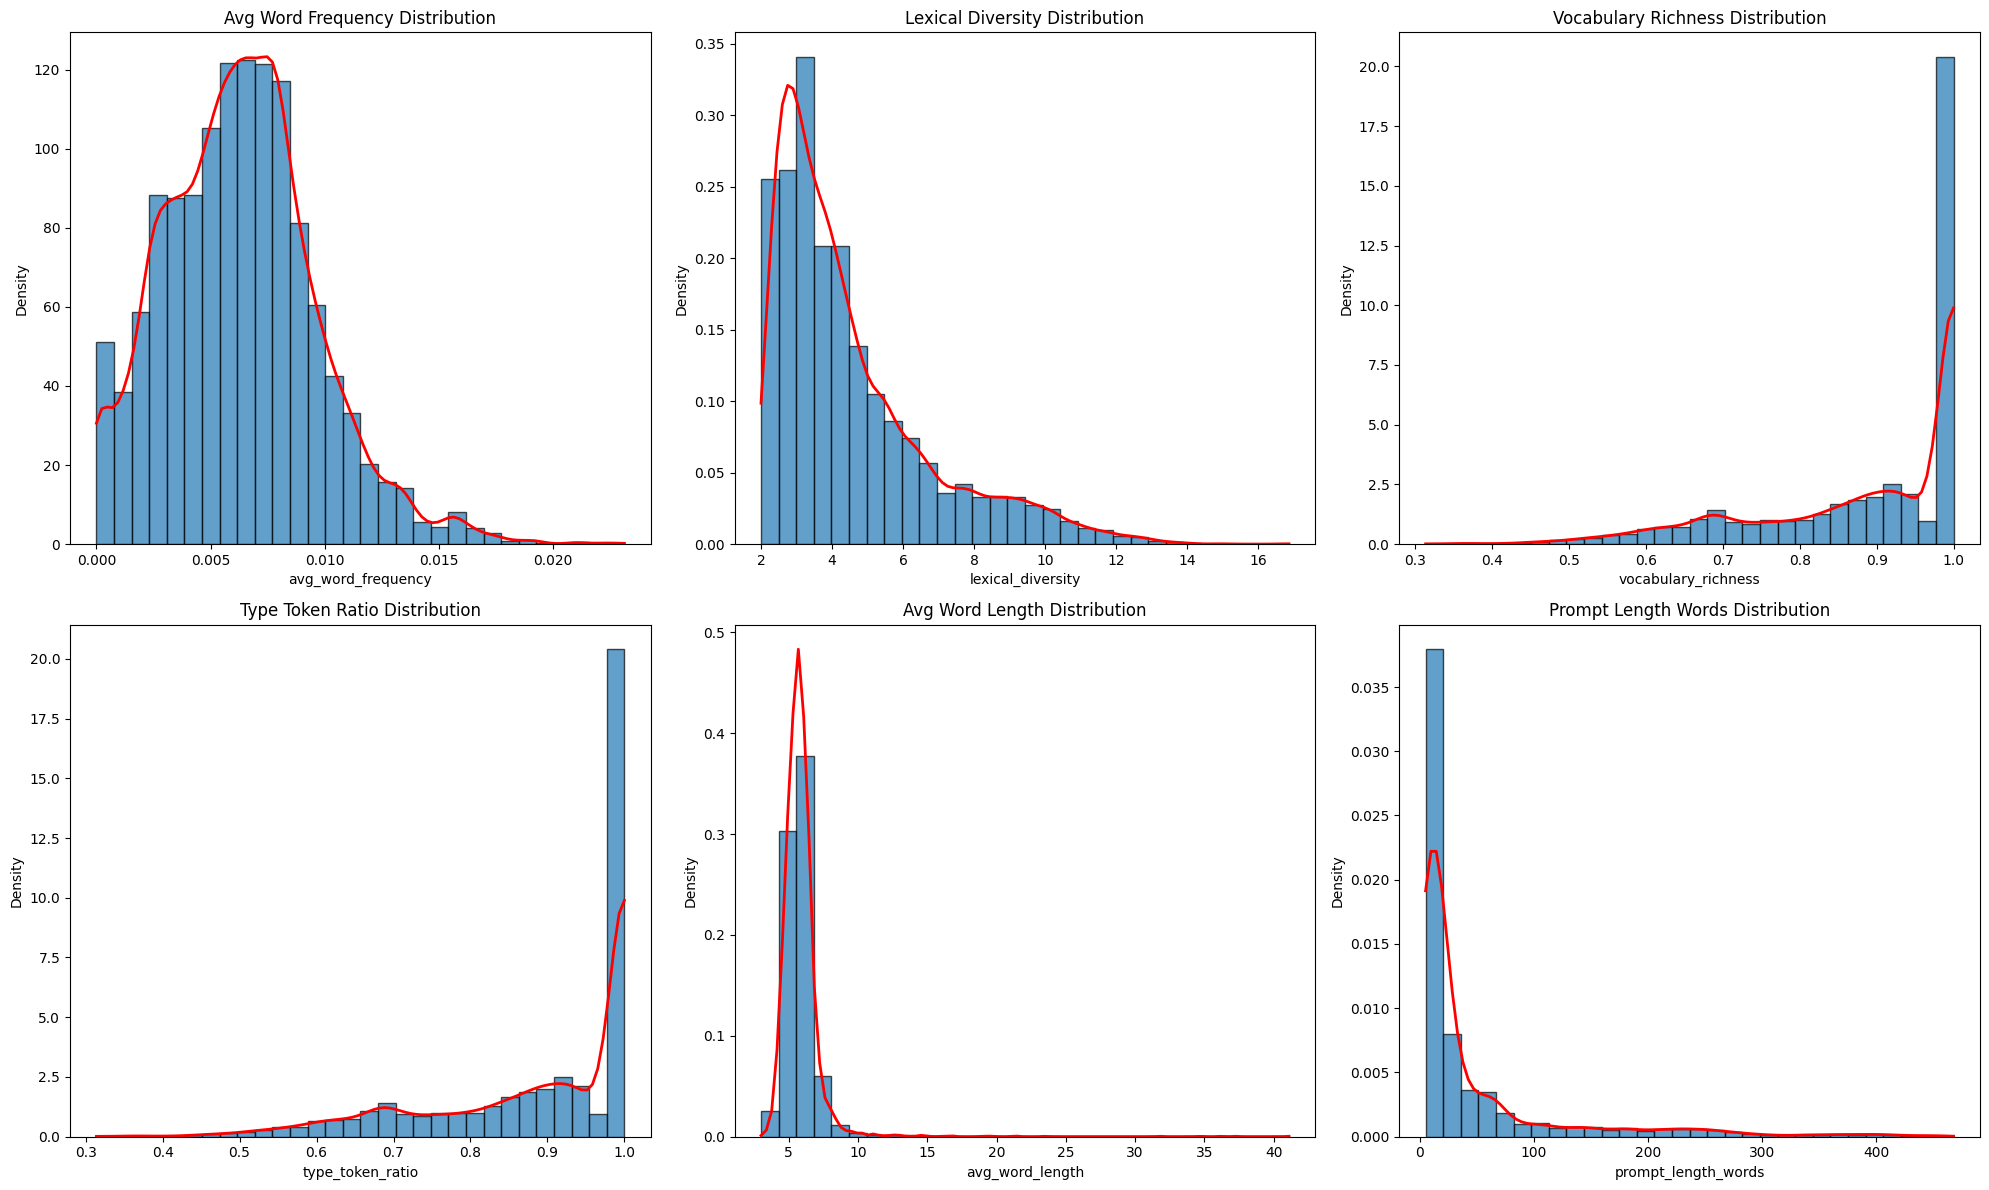

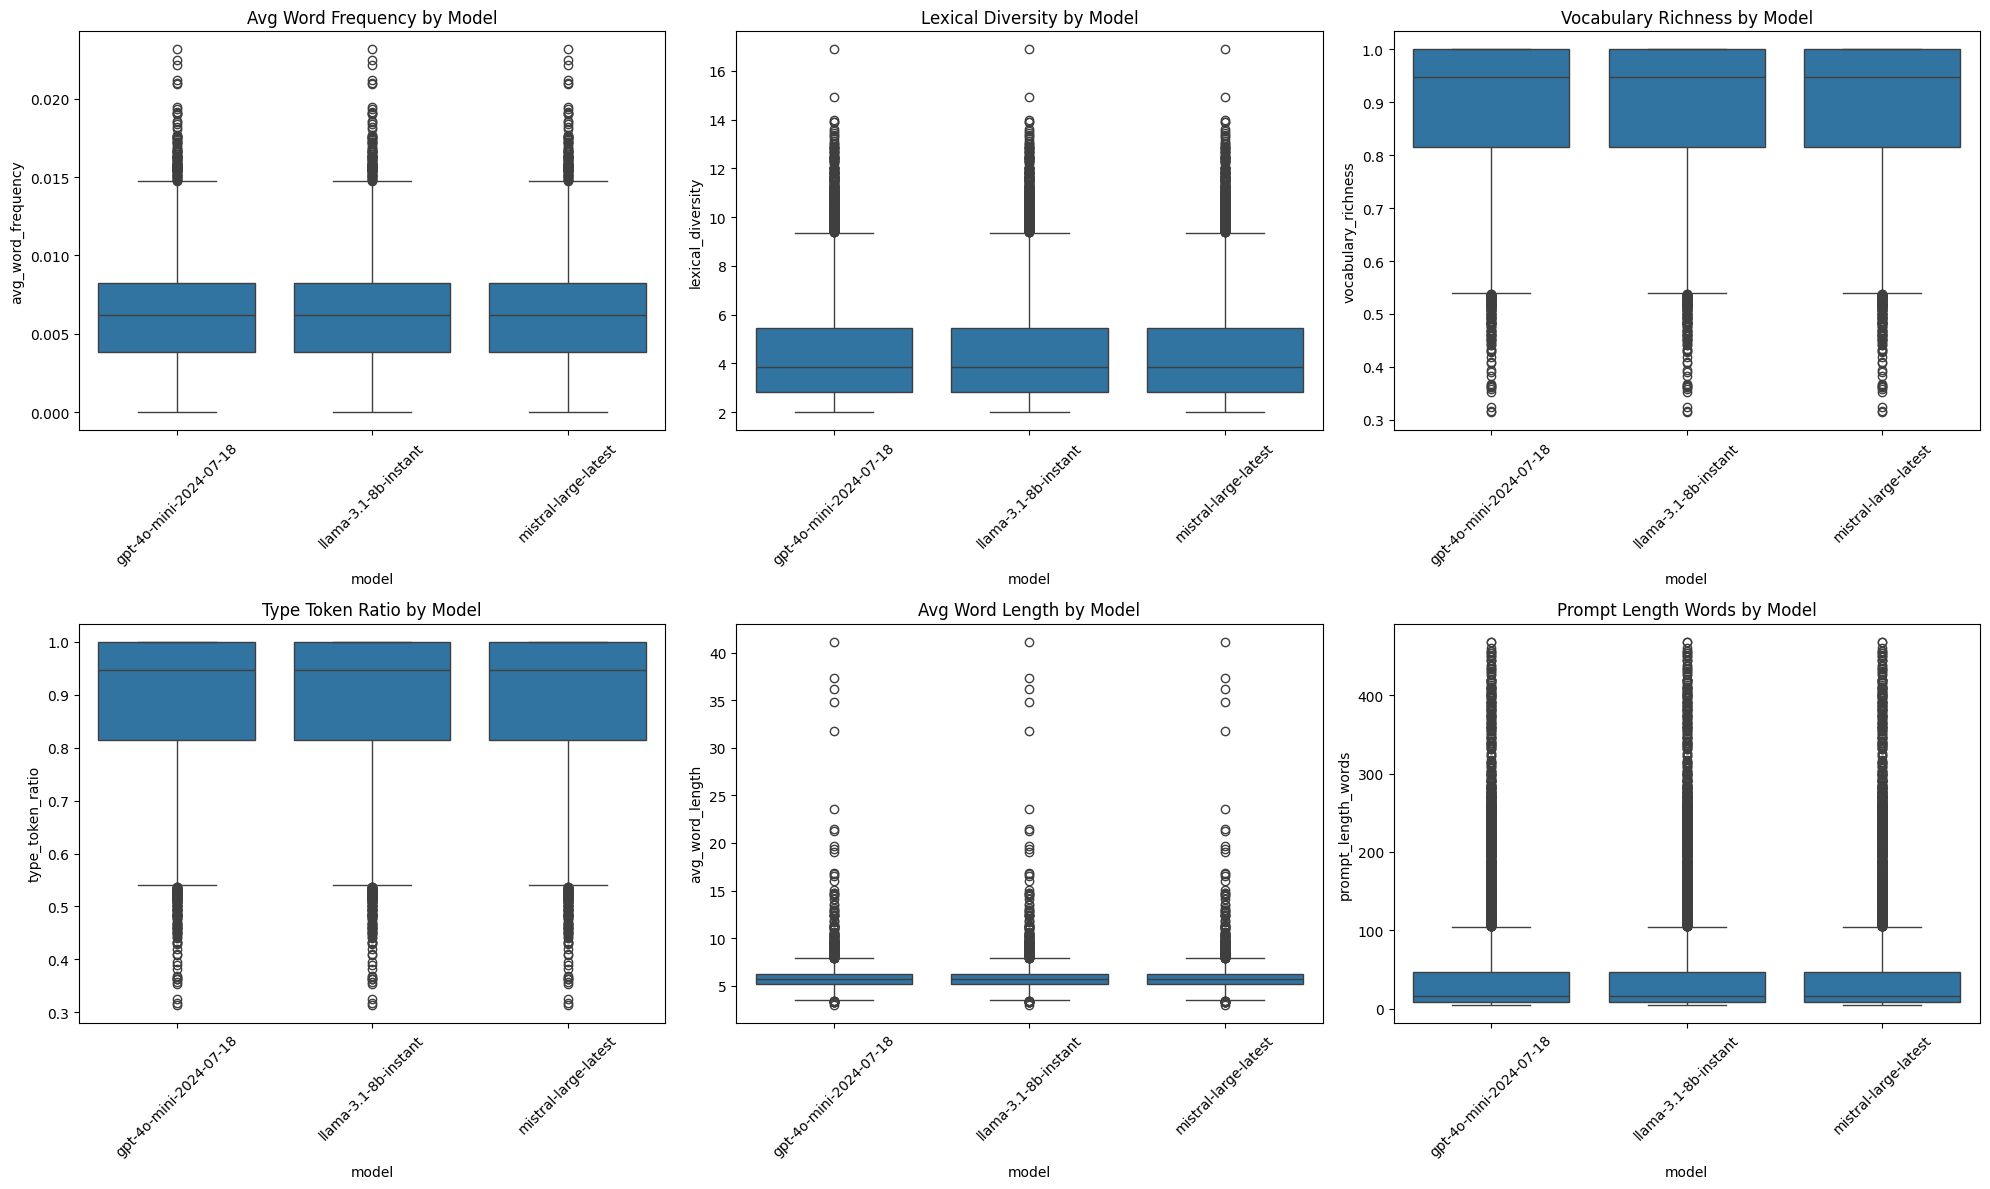

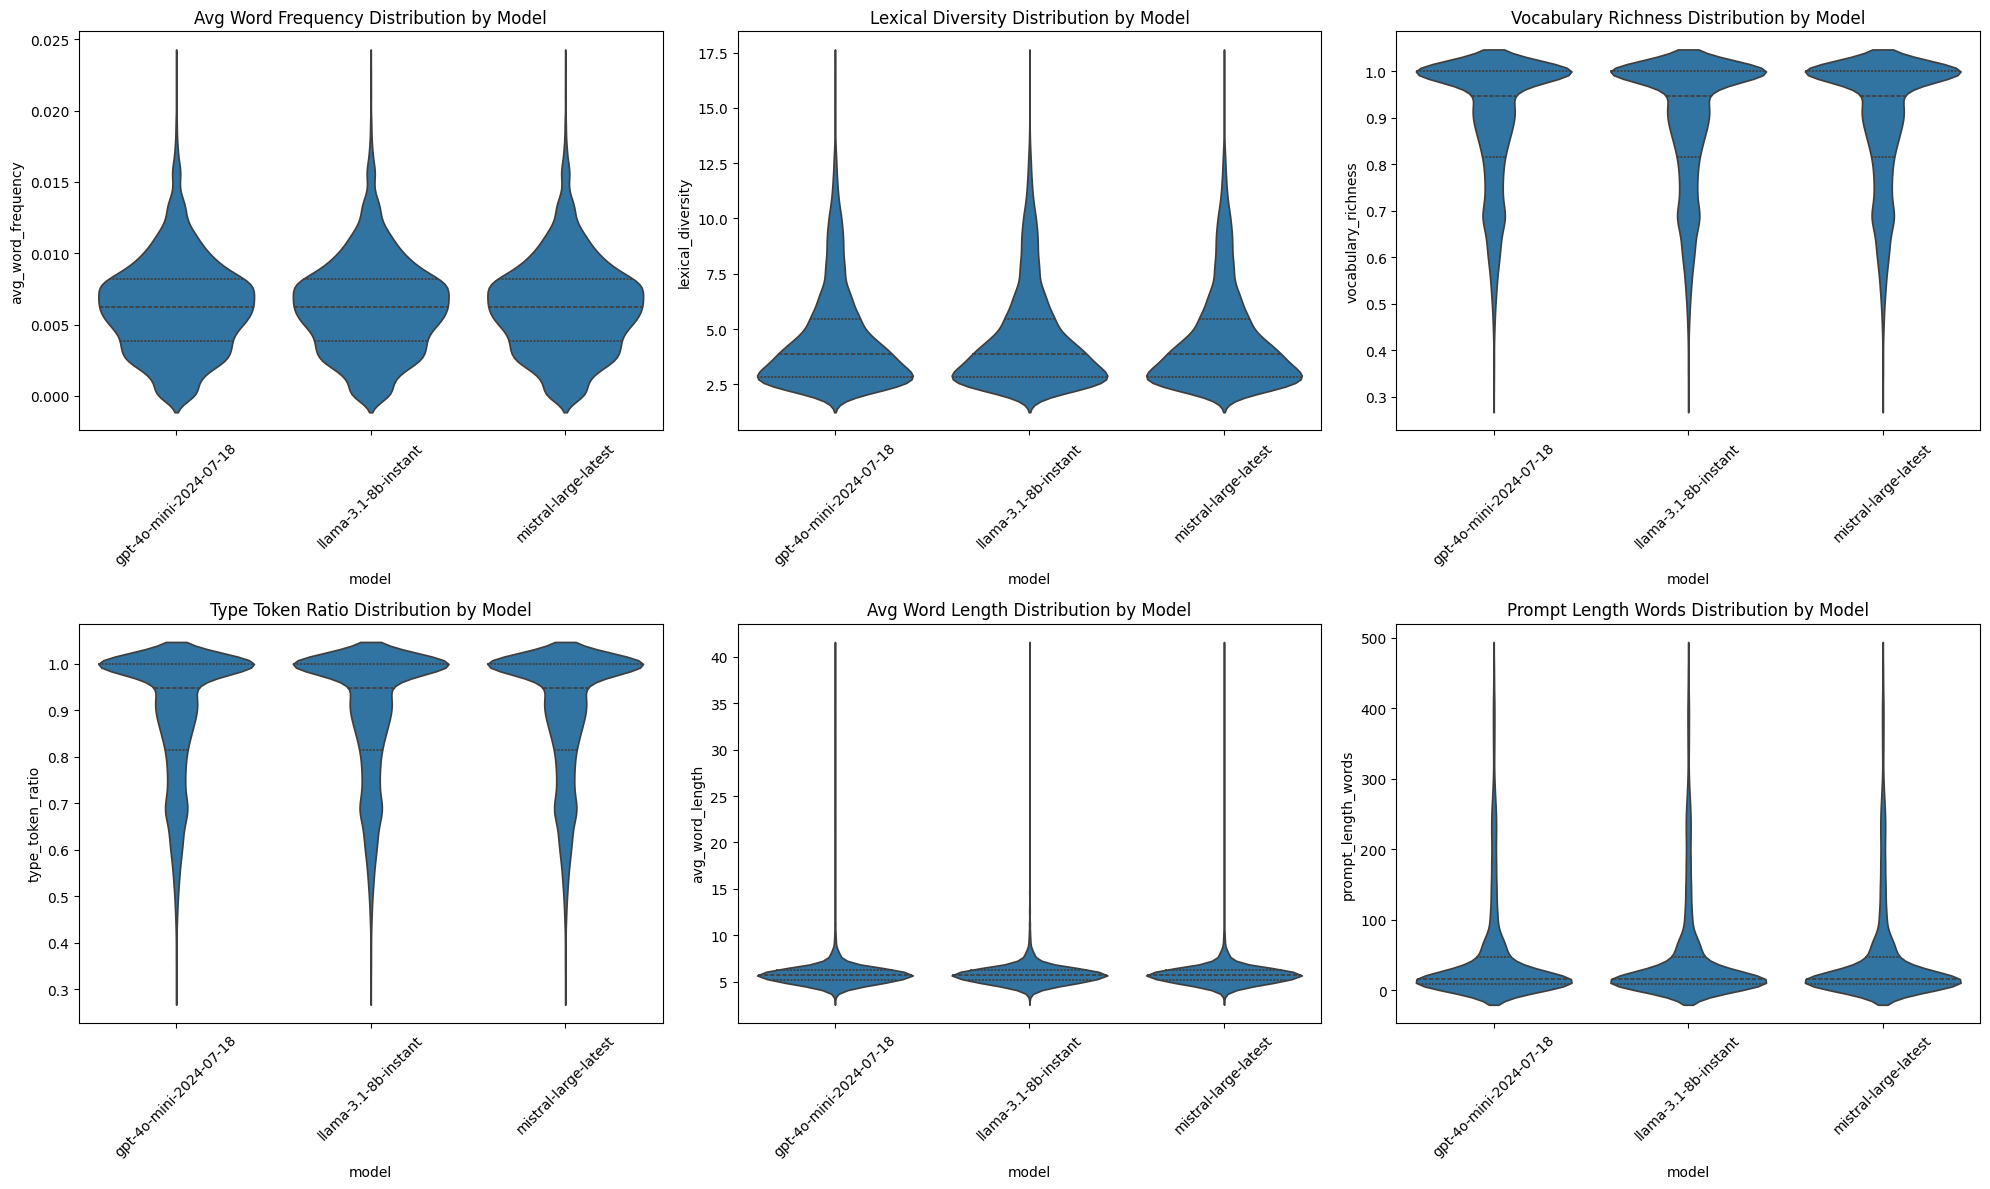

In [ ]:
# Comprehensive lexical features analysis including distribution, correlation, and model comparisons
lexical_features = ['avg_word_frequency', 'lexical_diversity', 'vocabulary_richness', 'type_token_ratio', 'avg_word_length', 'prompt_length_words']
available_lexical = [f for f in lexical_features if f in data.columns]

complexity_stats = data[available_lexical].describe()
complexity_stats

n_features = len(available_lexical)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

for i, feature in enumerate(available_lexical):
    axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

n_plot_features = min(len(available_lexical), 6)
n_cols = 3
n_rows = (n_plot_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_lexical[:n_plot_features], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data, x='model', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_lexical[:n_plot_features], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.violinplot(data=data, x='model', y=feature, inner='quartile')
    plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


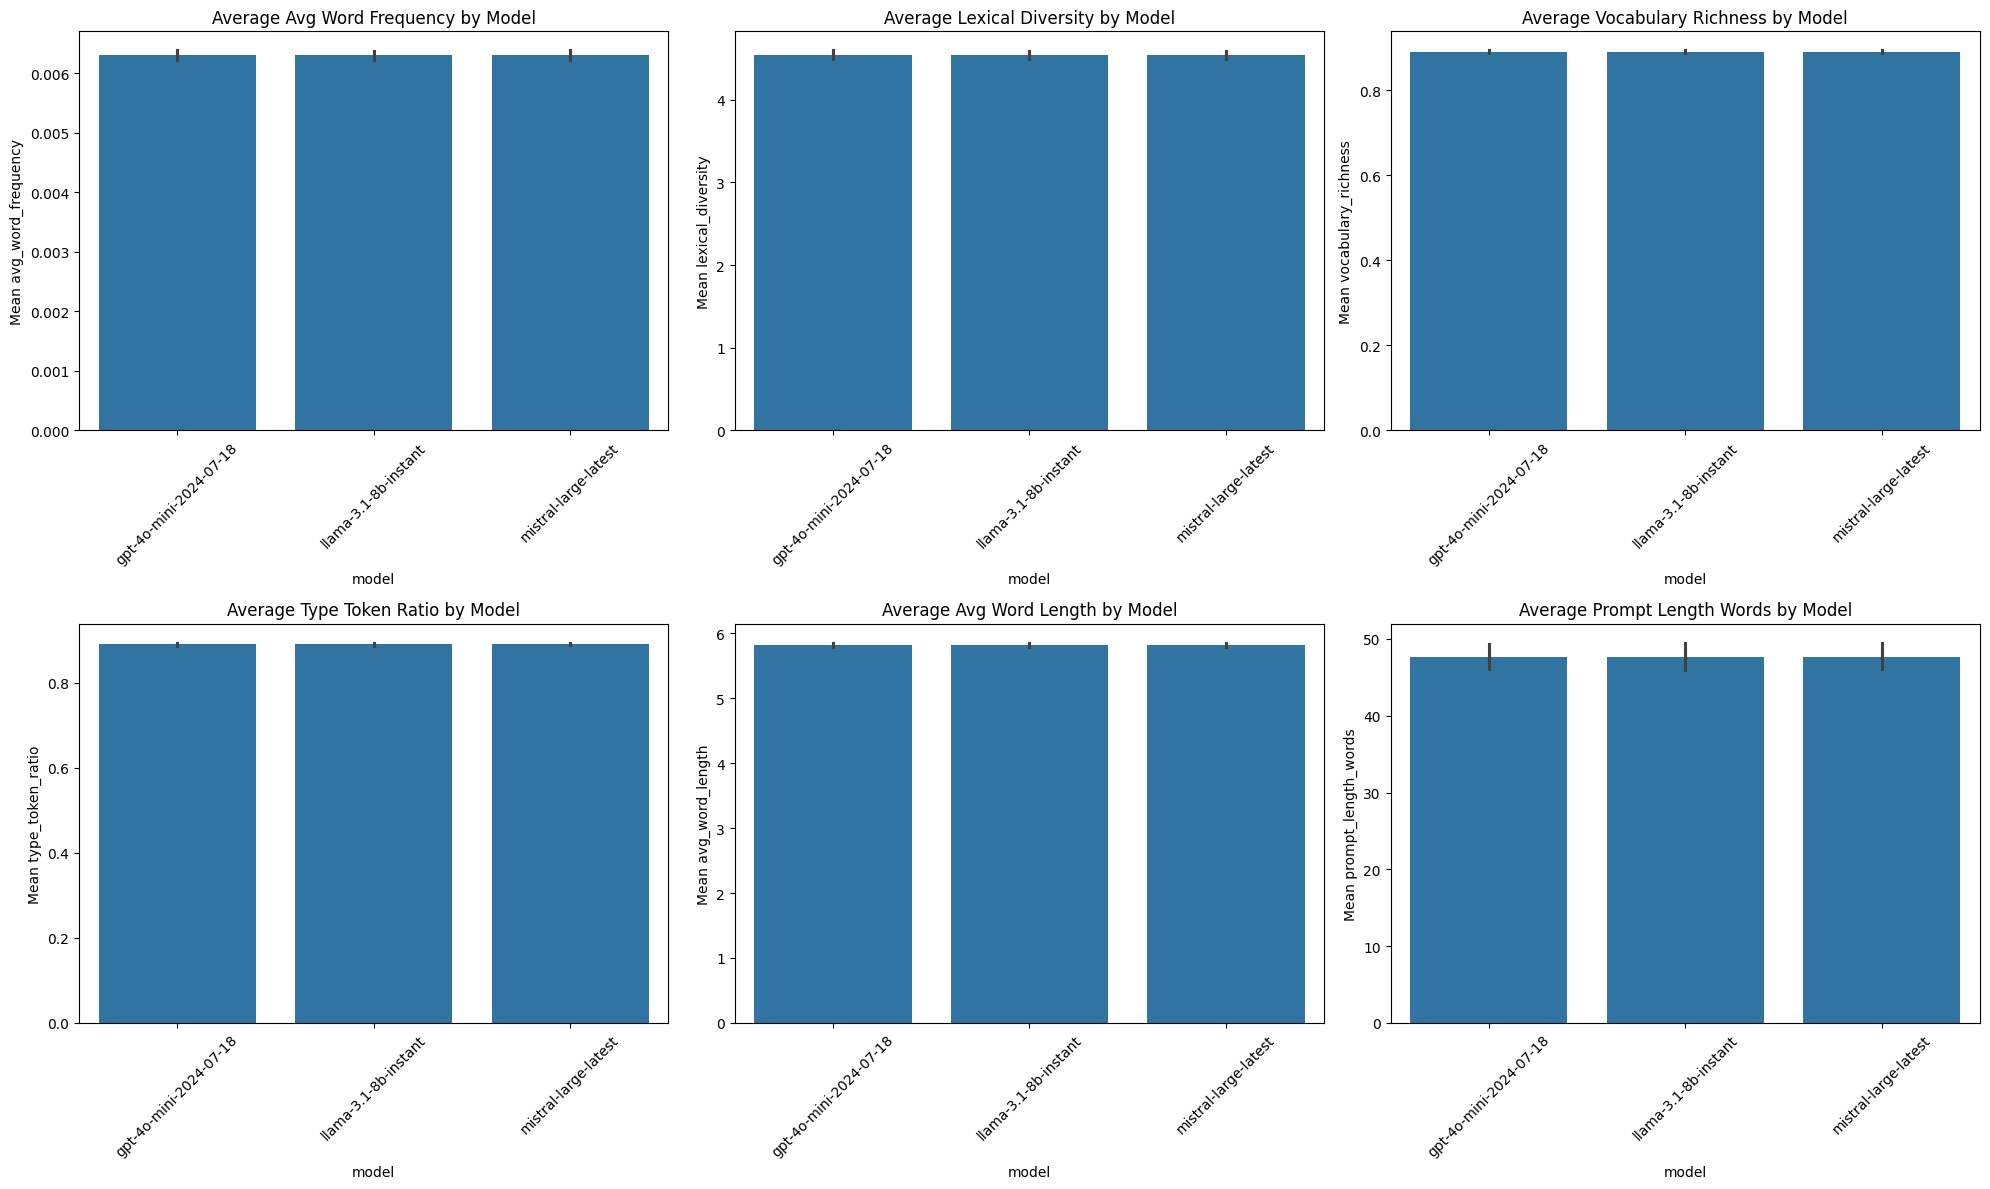

In [ ]:
# Model-wise statistical analysis and significance testing for lexical features
model_lexical_stats = data.groupby('model')[available_lexical].agg(['mean', 'std', 'min', 'max']).round(3)
model_lexical_stats

n_features = min(len(available_lexical), 6)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_lexical[:n_features], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
    plt.title(f'Average {feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
    plt.ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

from scipy.stats import f_oneway, kruskal

for feature in available_lexical:
    groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
    f_stat, p_value_anova = f_oneway(*groups)
    h_stat, p_value_kw = kruskal(*groups)


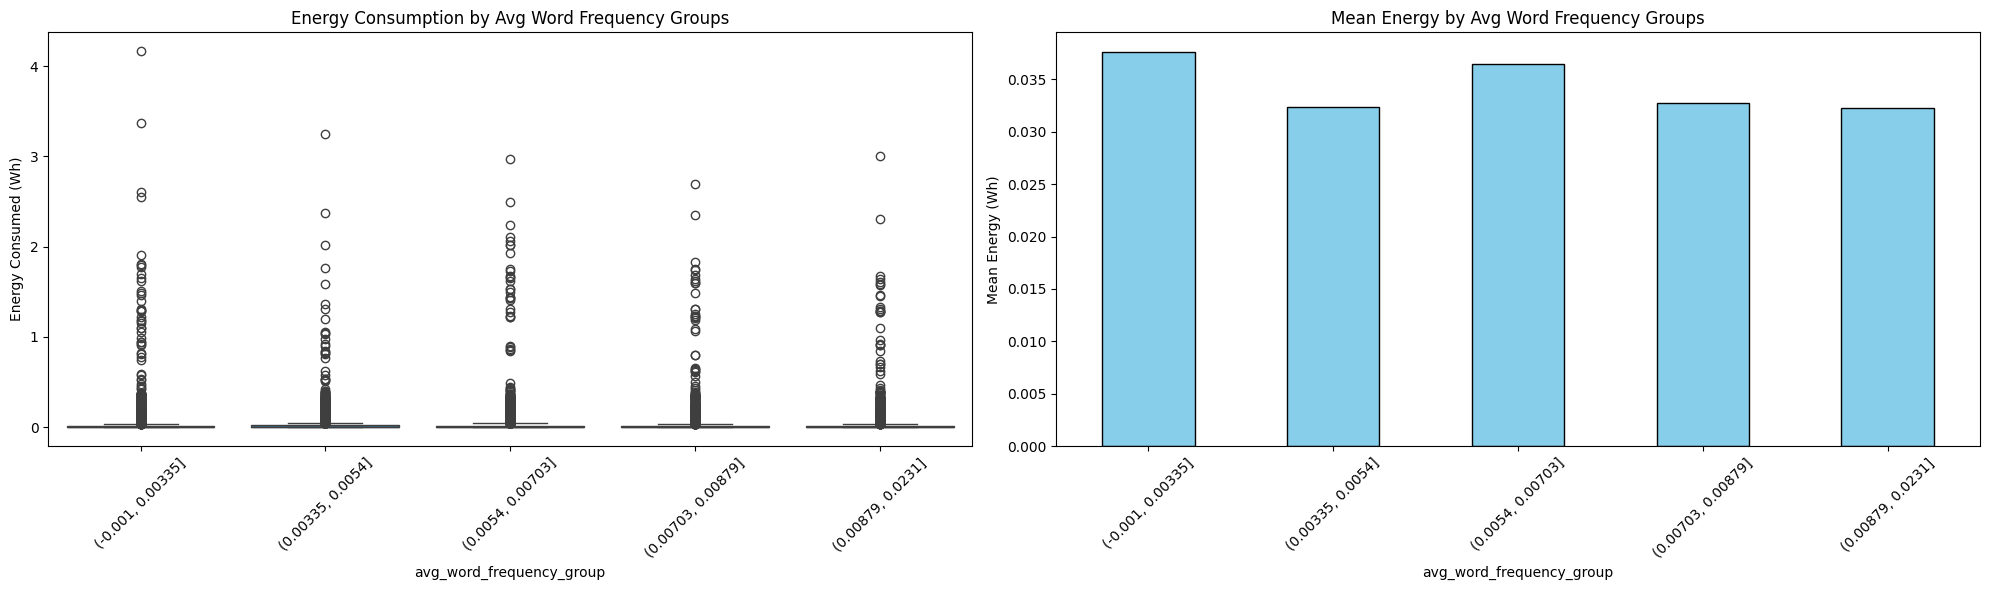

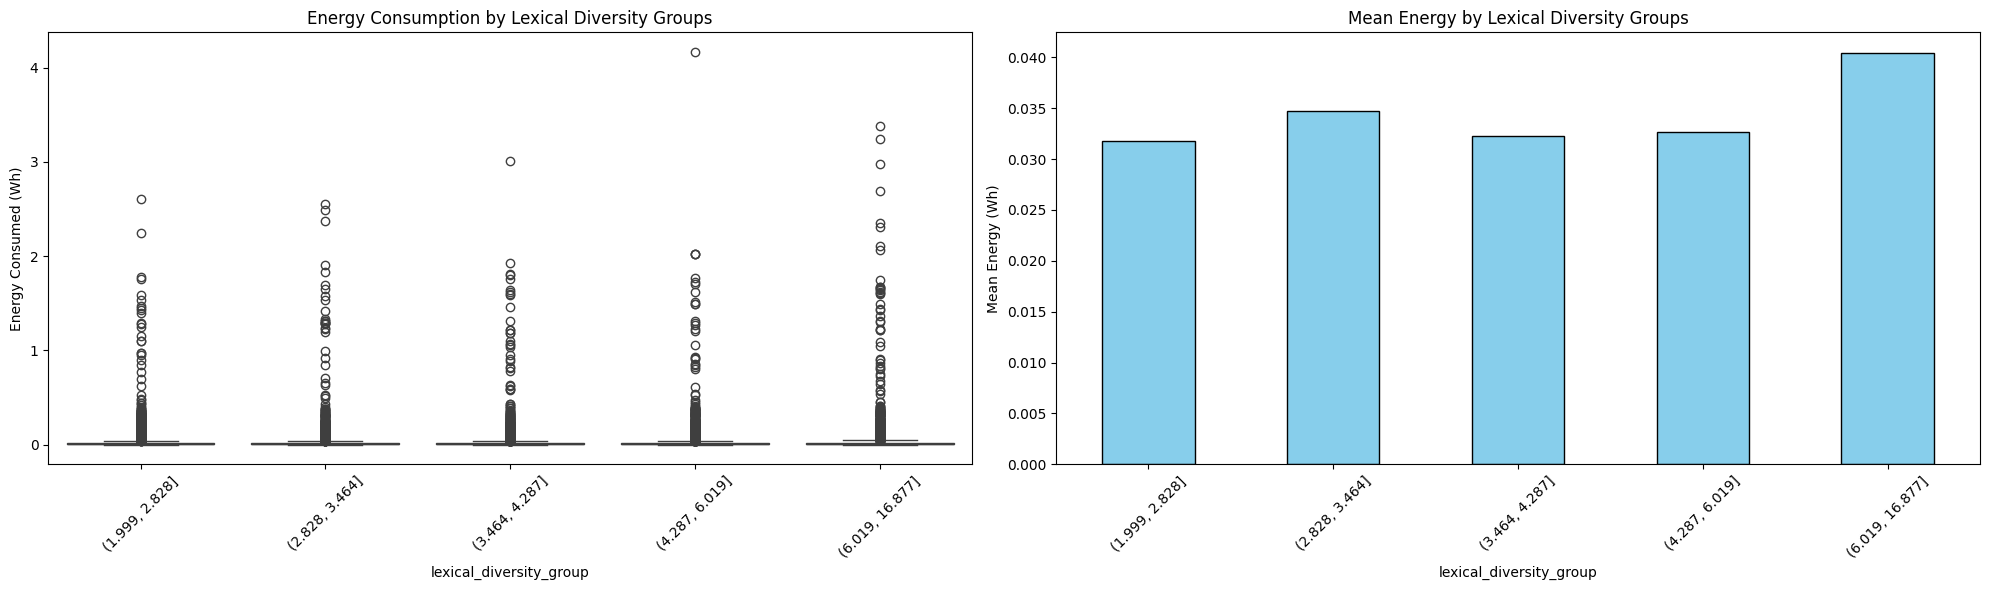

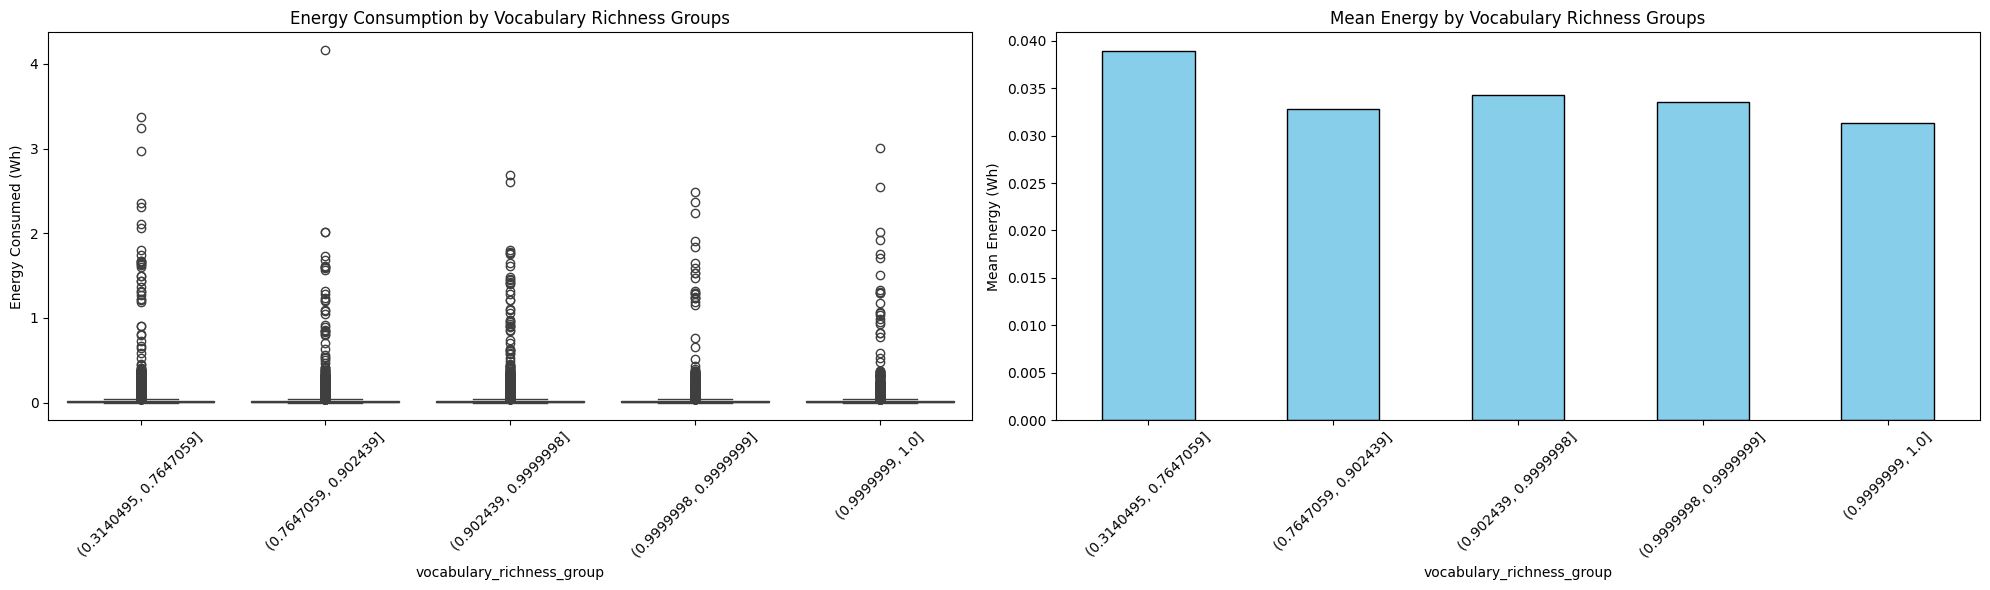

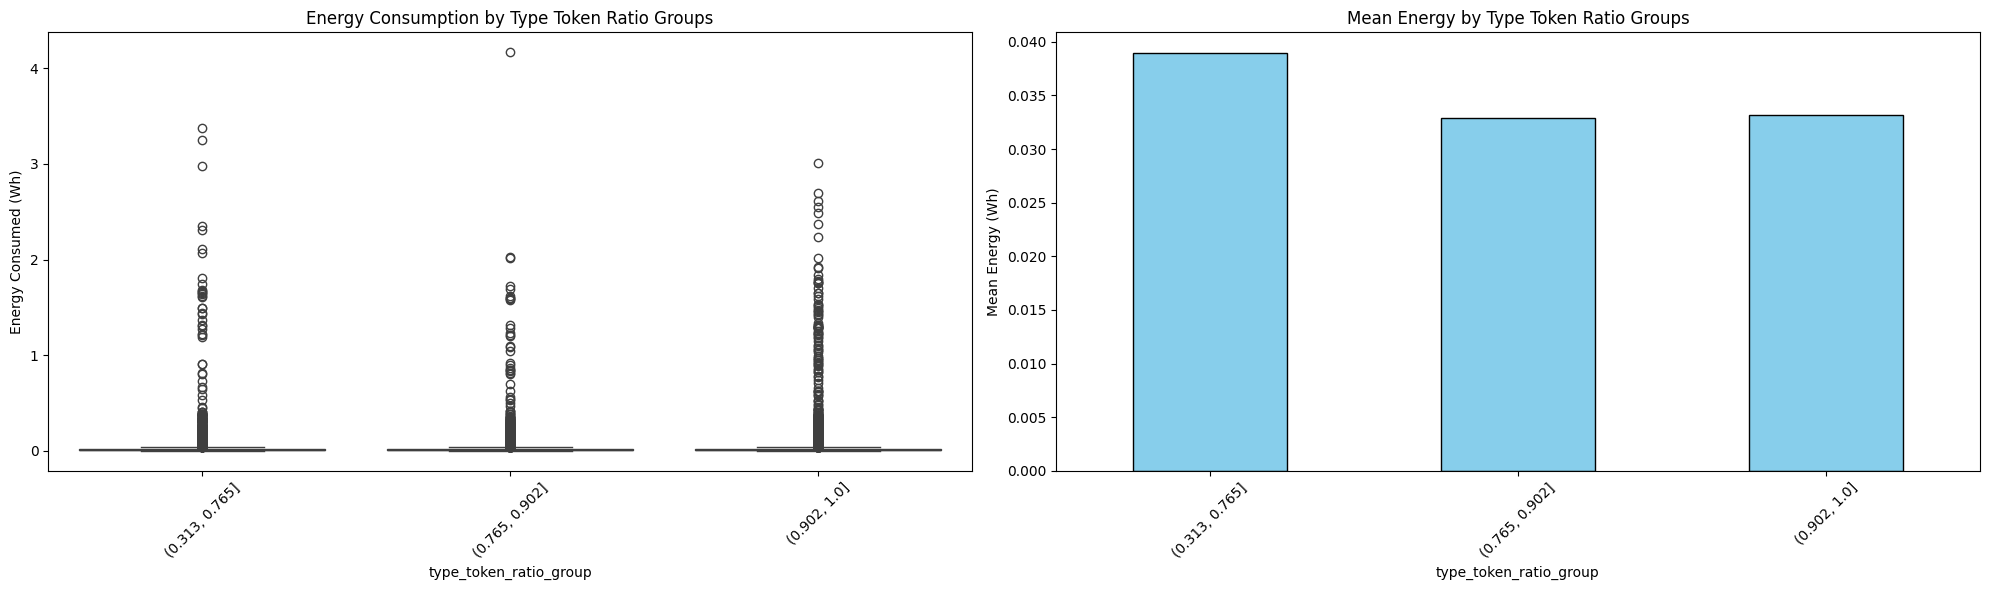

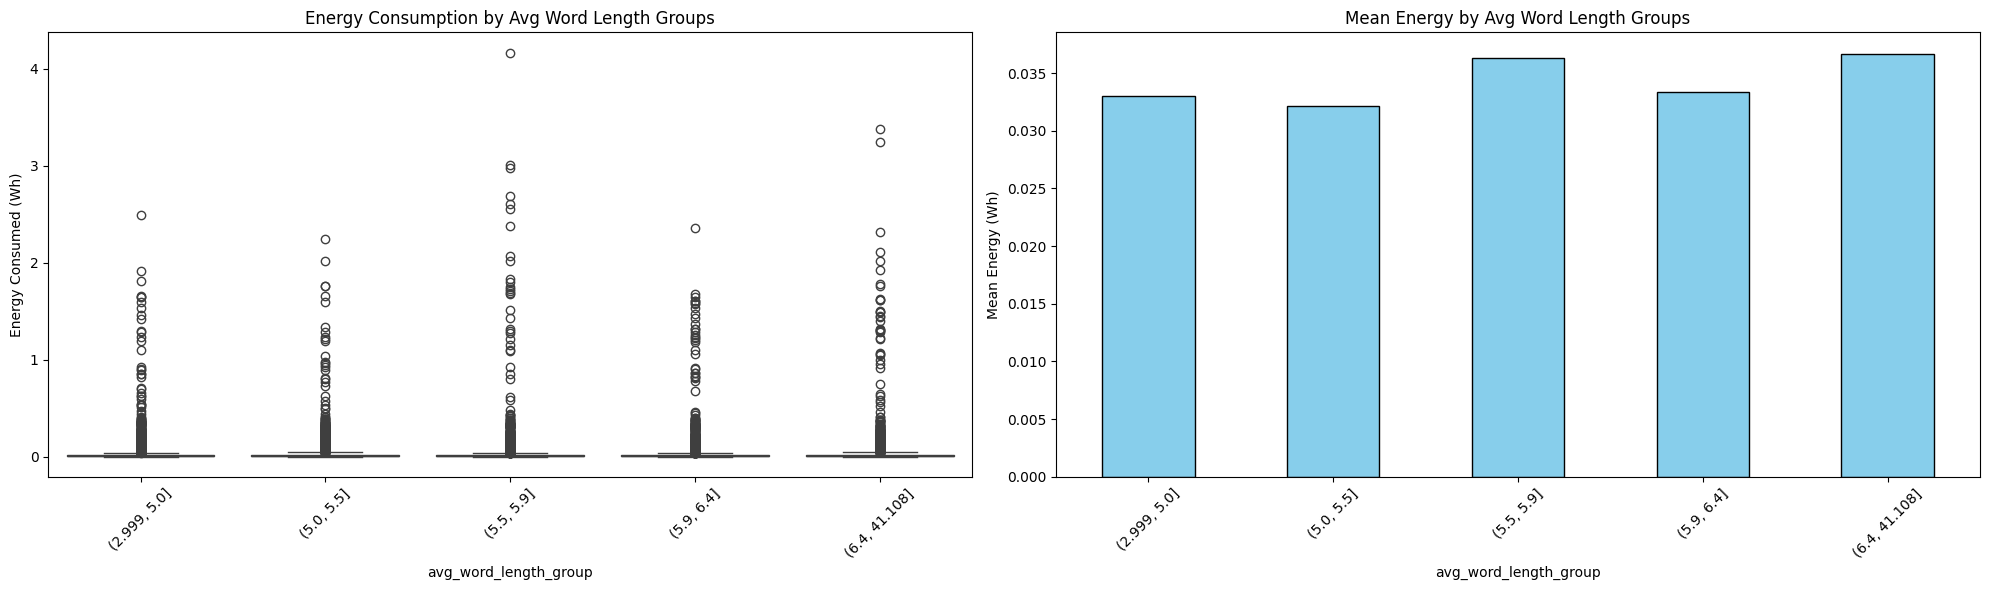

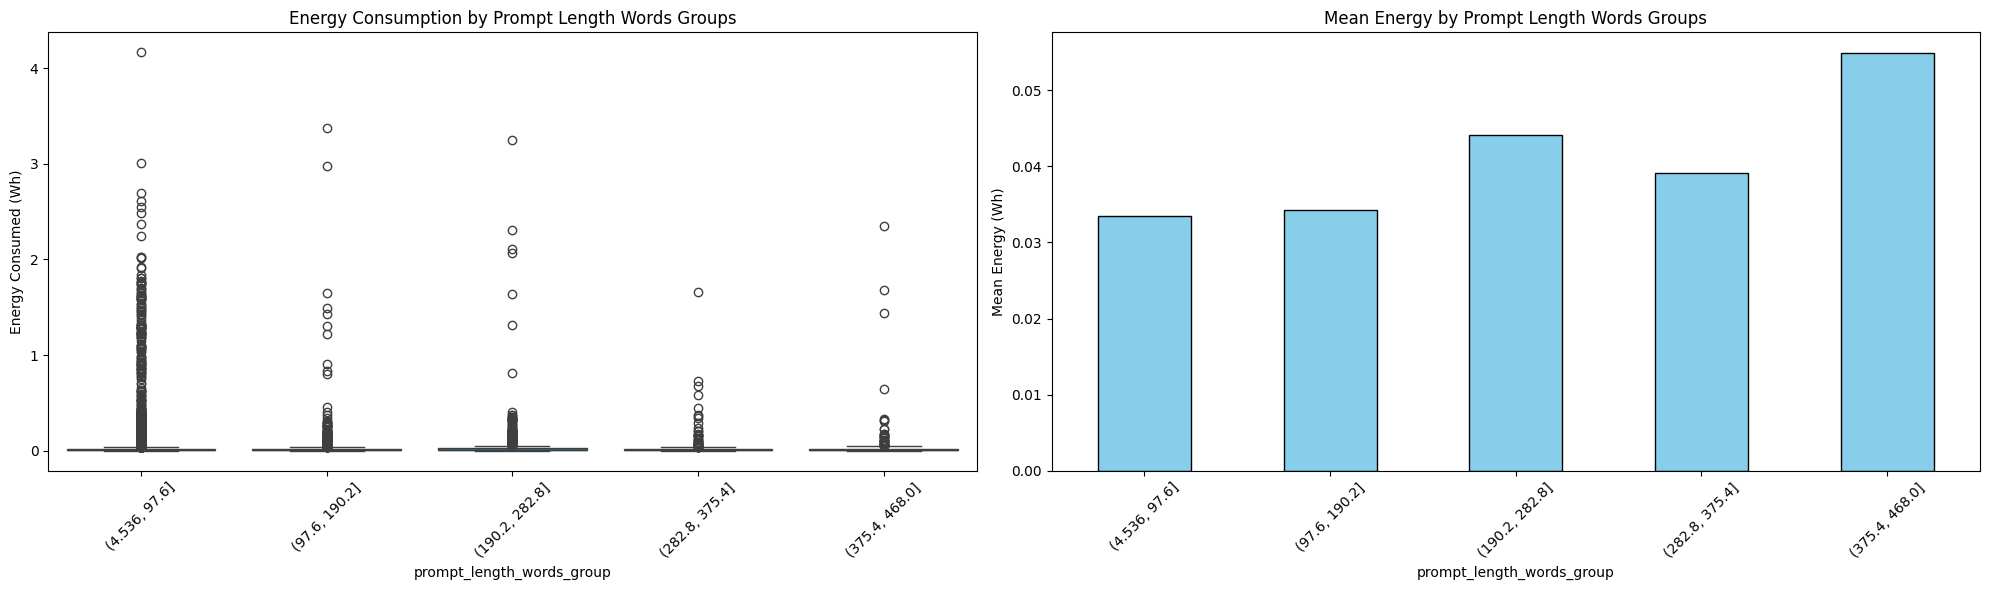

In [ ]:
# Energy consumption analysis by lexical feature ranges with visualizations
for feature in available_lexical:
    try:
        if feature in ['prompt_length_words']:
            data[f'{feature}_group'] = pd.cut(data[feature], bins=5, include_lowest=True)
        else:
            data[f'{feature}_group'] = pd.qcut(data[feature], q=5, duplicates='drop')
        
        energy_by_group = data.groupby(f'{feature}_group')['energy_consumed_wh'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
        
        plt.figure(figsize=(20, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=f'{feature}_group', y='energy_consumed_wh')
        plt.title(f'Energy Consumption by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Energy Consumed (Wh)')
        
        plt.subplot(1, 2, 2)
        energy_means = data.groupby(f'{feature}_group')['energy_consumed_wh'].mean()
        energy_means.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Mean Energy by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Mean Energy (Wh)')
        
        plt.tight_layout()
        plt.show()
        
        data.drop(f'{feature}_group', axis=1, inplace=True)
        
    except Exception as e:
        continue


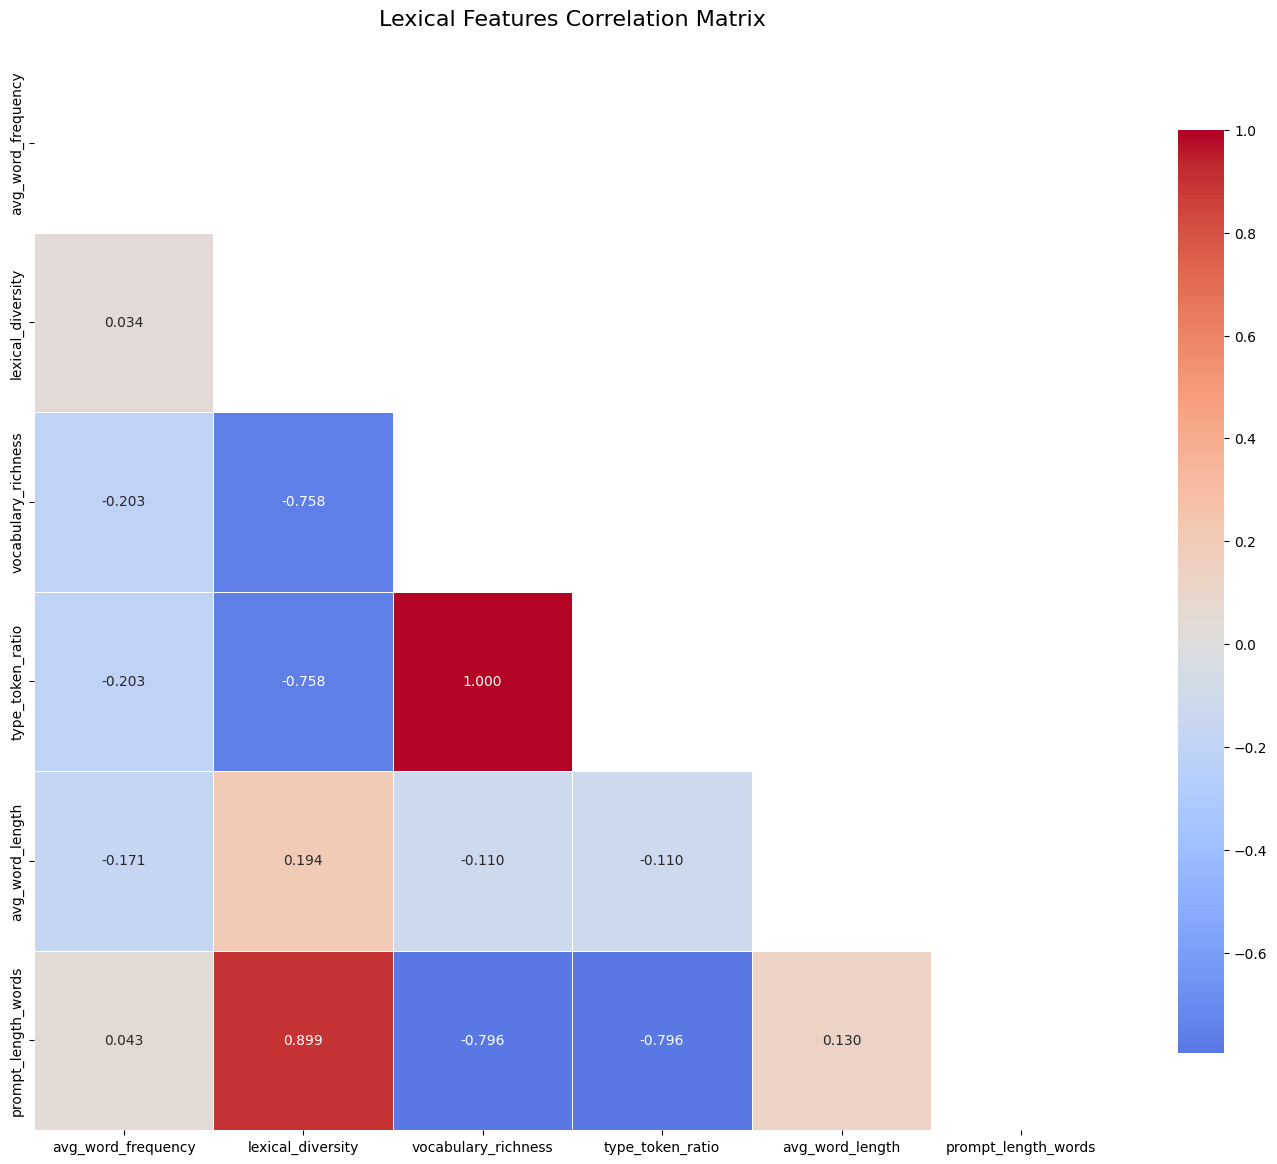

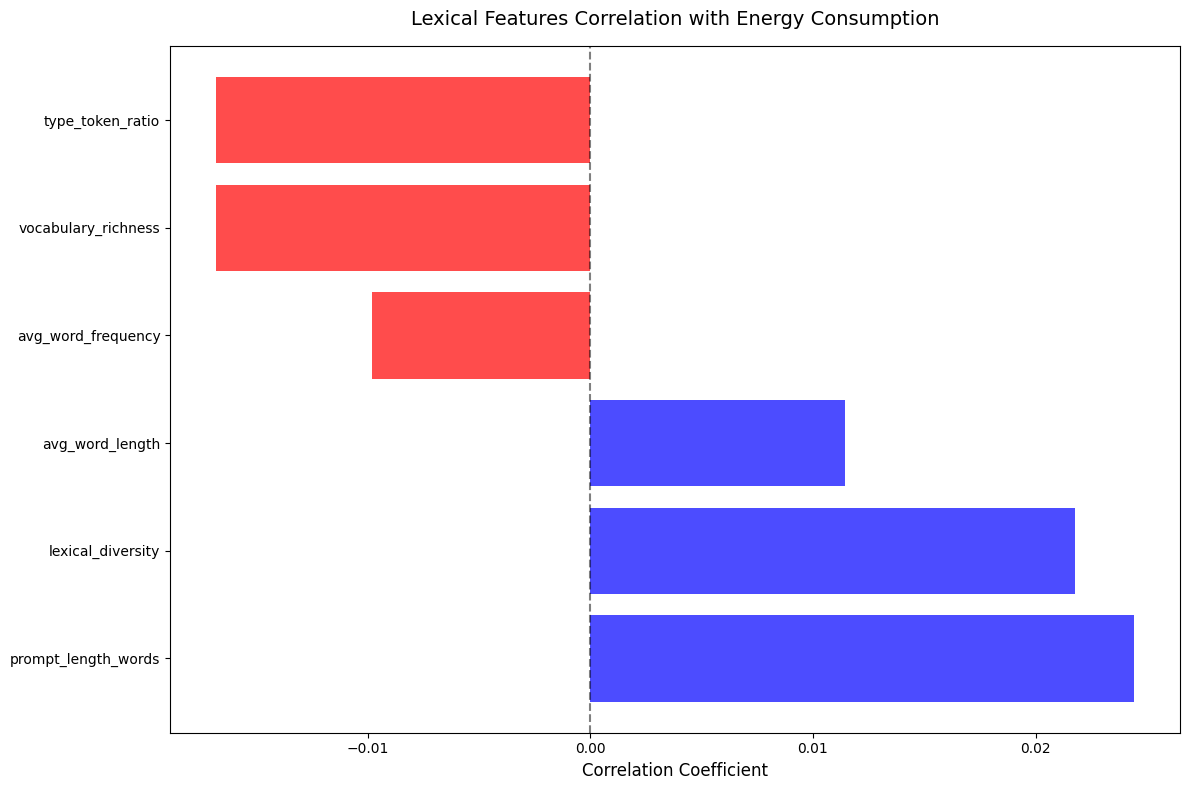

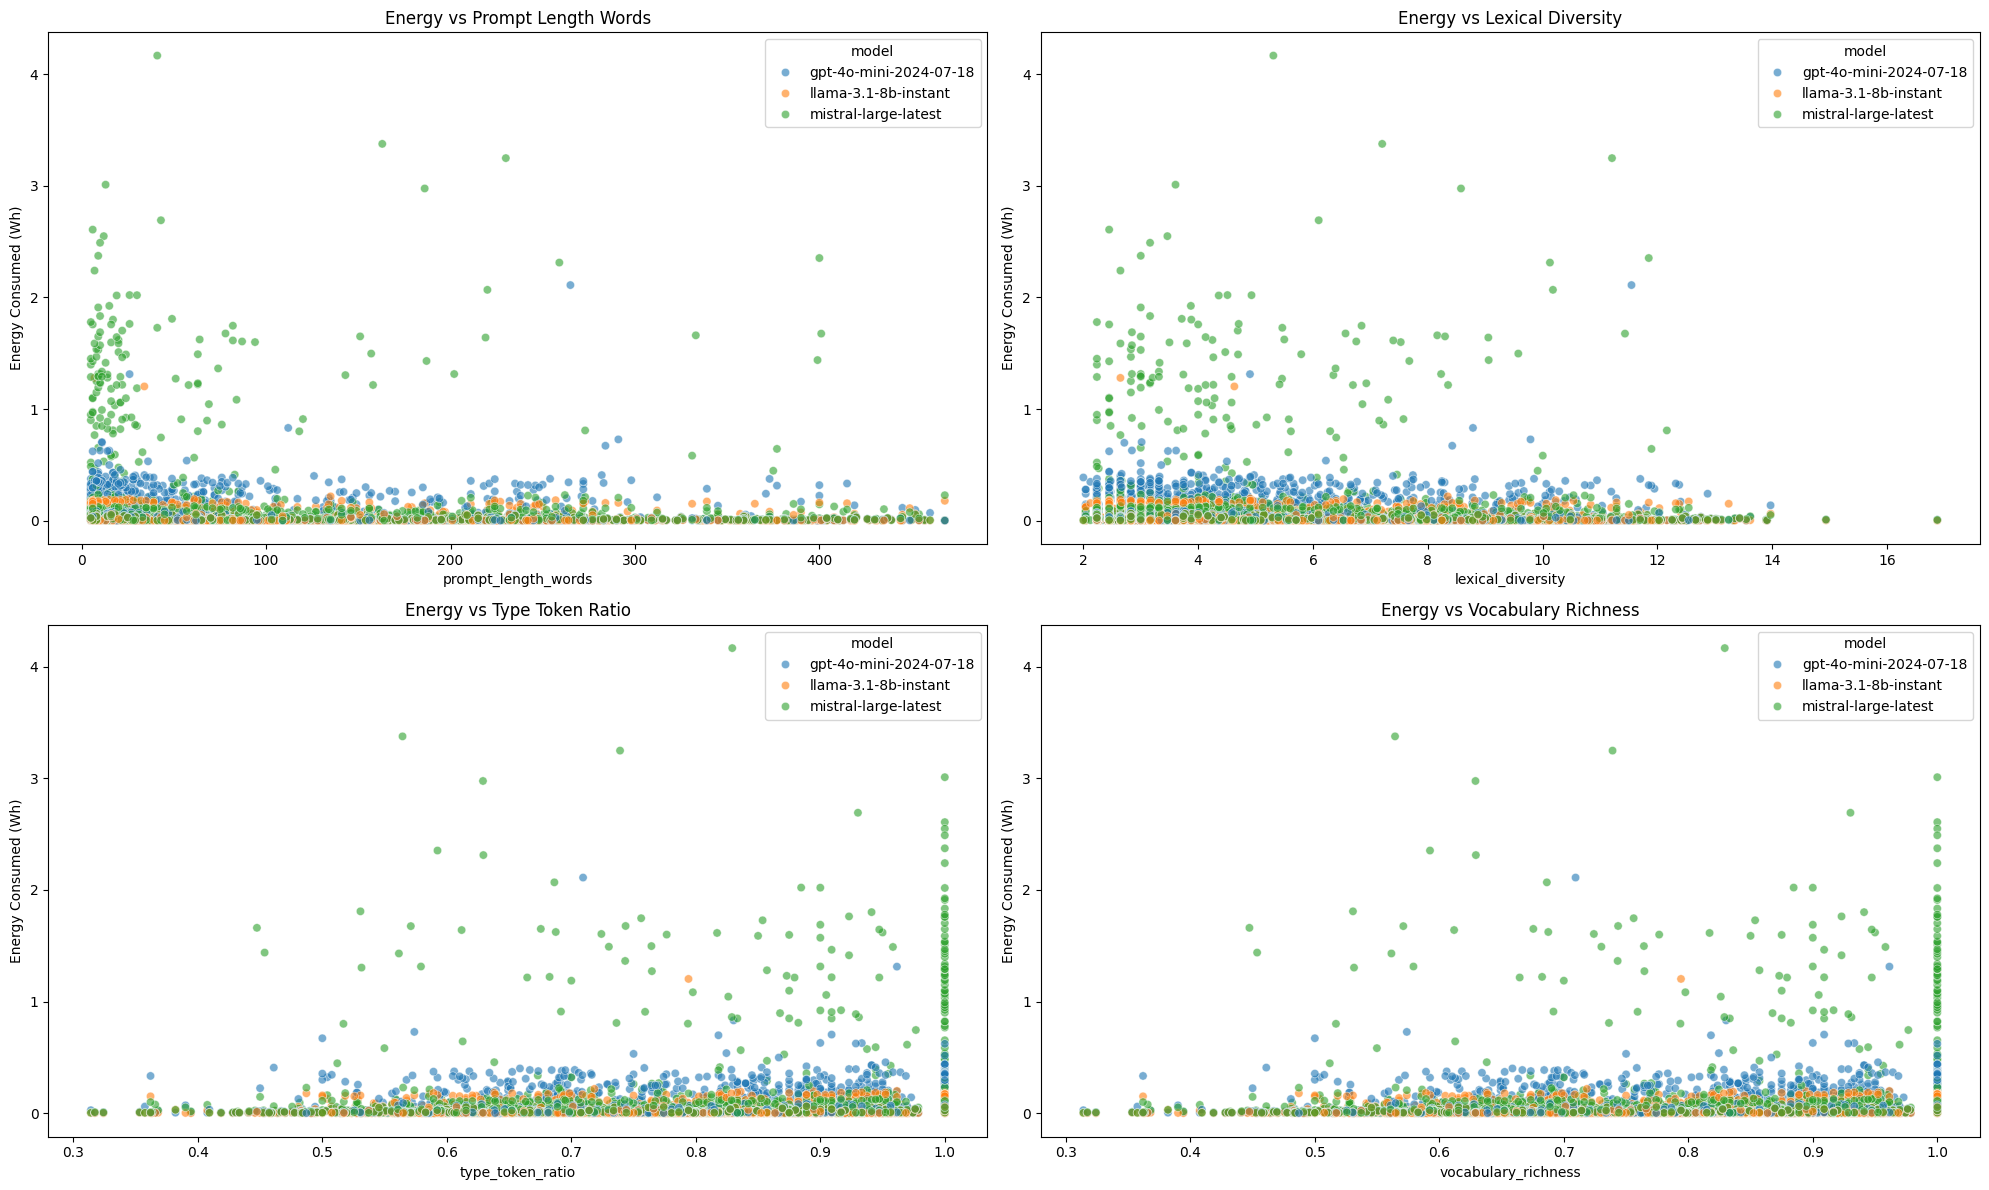

In [ ]:
# Correlation analysis and feature importance for lexical features
lexical_corr = data[available_lexical].corr()

plt.figure(figsize=(20, 12))
mask = np.triu(np.ones_like(lexical_corr, dtype=bool))
sns.heatmap(lexical_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Lexical Features Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

energy_lexical_corr = data[['energy_consumed_wh'] + available_lexical].corr()
energy_correlations = energy_lexical_corr['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 8))
energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Lexical Features Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top_correlated = energy_correlations_clean.abs().nlargest(4).index.tolist()

if len(top_correlated) > 0:
    n_plots = min(len(top_correlated), 4)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    plt.figure(figsize=(20, 6*n_rows))
    for i, feature in enumerate(top_correlated[:n_plots], 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
        plt.title(f'Energy vs {feature.replace("_", " ").title()}')
        plt.xlabel(feature)
        plt.ylabel('Energy Consumed (Wh)')
    
    plt.tight_layout()
    plt.show()


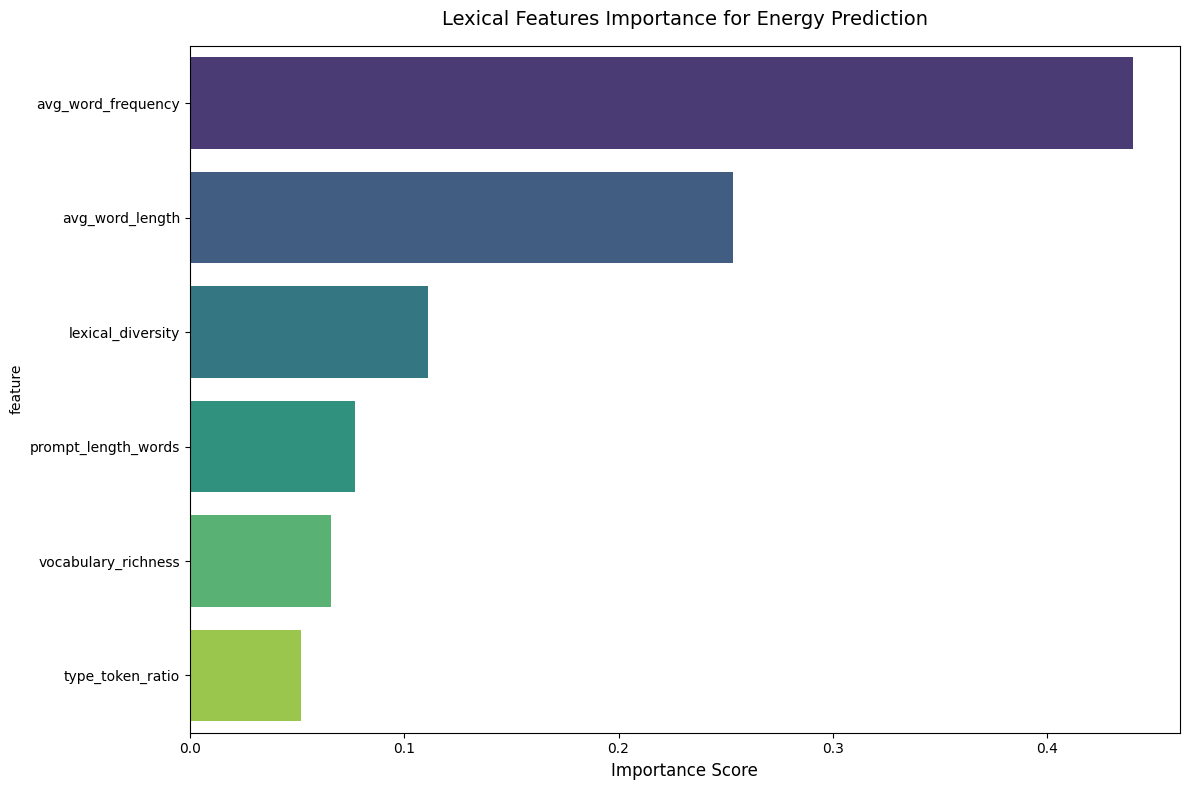

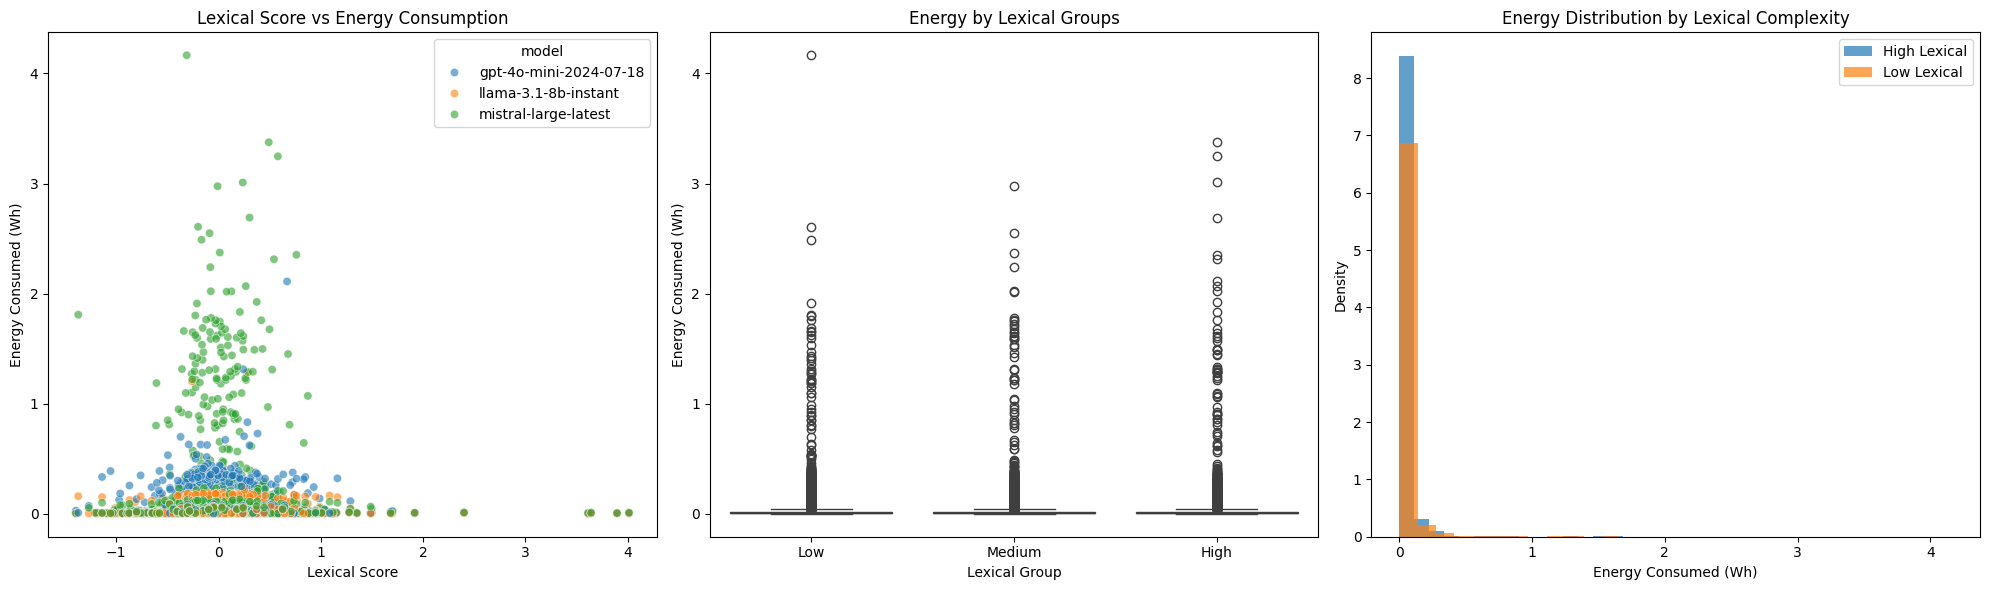

In [ ]:
# Feature importance and insights for lexical features
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = data[available_lexical].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': available_lexical,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

plt.figure(figsize=(20, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Lexical Features Importance for Energy Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

y_pred = rf.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

lexical_score = data[available_lexical].apply(lambda x: (x - x.mean()) / x.std()).mean(axis=1)
data['lexical_score'] = lexical_score

high_lexical = data[data['lexical_score'] > data['lexical_score'].quantile(0.75)]
low_lexical = data[data['lexical_score'] < data['lexical_score'].quantile(0.25)]

high_energy_mean = high_lexical['energy_consumed_wh'].mean()
low_energy_mean = low_lexical['energy_consumed_wh'].mean()

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(high_lexical['energy_consumed_wh'], low_lexical['energy_consumed_wh'])

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='lexical_score', y='energy_consumed_wh', hue='model', alpha=0.6)
plt.title('Lexical Score vs Energy Consumption')
plt.xlabel('Lexical Score')
plt.ylabel('Energy Consumed (Wh)')

plt.subplot(1, 3, 2)
data['lexical_group'] = pd.qcut(data['lexical_score'], q=3, labels=['Low', 'Medium', 'High'])
sns.boxplot(data=data, x='lexical_group', y='energy_consumed_wh')
plt.title('Energy by Lexical Groups')
plt.xlabel('Lexical Group')
plt.ylabel('Energy Consumed (Wh)')

plt.subplot(1, 3, 3)
plt.hist(high_lexical['energy_consumed_wh'], alpha=0.7, label='High Lexical', bins=30, density=True)
plt.hist(low_lexical['energy_consumed_wh'], alpha=0.7, label='Low Lexical', bins=30, density=True)
plt.title('Energy Distribution by Lexical Complexity')
plt.xlabel('Energy Consumed (Wh)')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

data.drop(['lexical_score', 'lexical_group'], axis=1, inplace=True, errors='ignore')


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

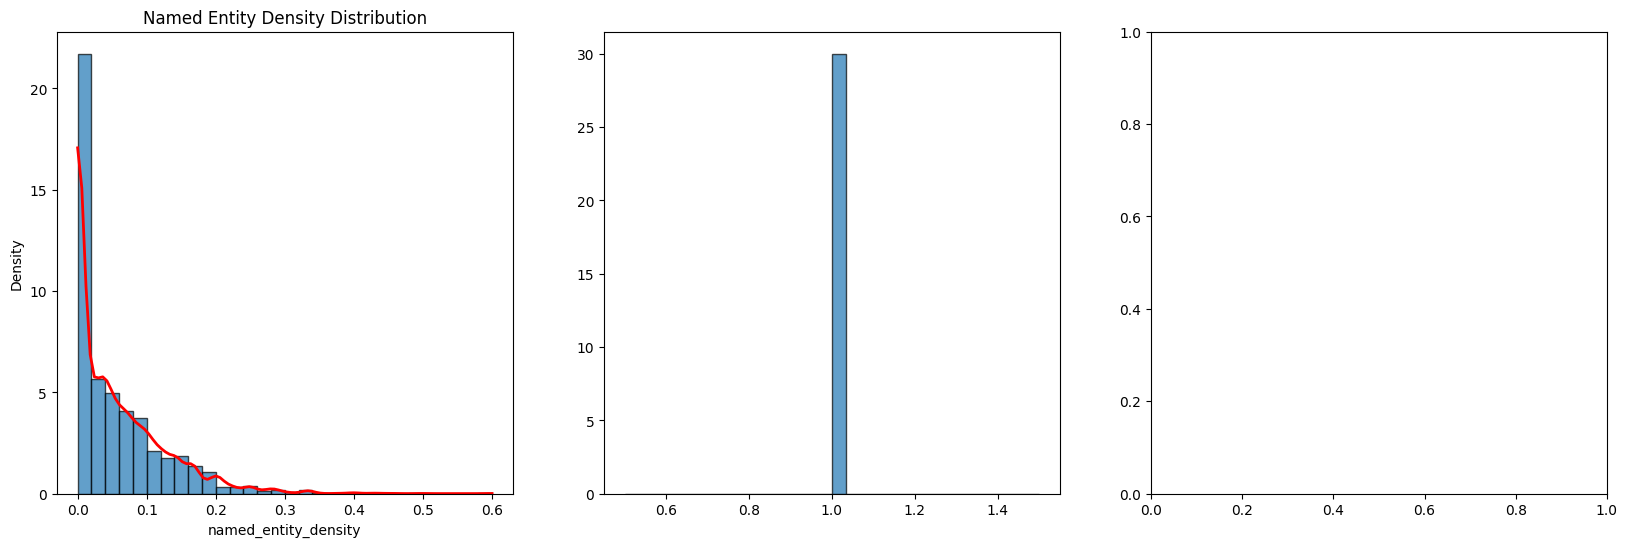

In [ ]:
# Comprehensive semantic features analysis including entity density and category diversity
semantic_features = ['named_entity_density', 'semantic_category_diversity', 'information_density']
available_semantic = [f for f in semantic_features if f in data.columns]

semantic_stats = data[available_semantic].describe()
semantic_stats

n_features = len(available_semantic)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

for i, feature in enumerate(available_semantic):
    axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

n_cols = 3
n_rows = (len(available_semantic) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_semantic, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data, x='model', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_semantic, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.violinplot(data=data, x='model', y=feature, inner='quartile')
    plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Model-wise semantic features analysis with statistical testing and energy relationships
model_semantic_stats = data.groupby('model')[available_semantic].agg(['mean', 'std', 'min', 'max']).round(3)
model_semantic_stats

n_features = len(available_semantic)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_semantic, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
    plt.title(f'Average {feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
    plt.ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

from scipy.stats import f_oneway, kruskal

for feature in available_semantic:
    groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
    f_stat, p_value_anova = f_oneway(*groups)
    h_stat, p_value_kw = kruskal(*groups)

for feature in available_semantic:
    try:
        data[f'{feature}_group'] = pd.qcut(data[feature], q=5, duplicates='drop')
        
        energy_by_group = data.groupby(f'{feature}_group')['energy_consumed_wh'].agg(['count', 'mean', 'std']).round(4)
        
        plt.figure(figsize=(20, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=f'{feature}_group', y='energy_consumed_wh')
        plt.title(f'Energy Consumption by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Energy Consumed (Wh)')
        
        plt.subplot(1, 2, 2)
        energy_means = data.groupby(f'{feature}_group')['energy_consumed_wh'].mean()
        energy_means.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Mean Energy by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Mean Energy (Wh)')
        
        plt.tight_layout()
        plt.show()
        
        data.drop(f'{feature}_group', axis=1, inplace=True)
        
    except Exception as e:
        continue


In [ ]:
# Correlation and feature importance analysis for semantic features
semantic_corr = data[available_semantic].corr()

plt.figure(figsize=(20, 10))
mask = np.triu(np.ones_like(semantic_corr, dtype=bool))
sns.heatmap(semantic_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Semantic Features Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

energy_semantic_corr = data[['energy_consumed_wh'] + available_semantic].corr()
energy_correlations = energy_semantic_corr['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 8))
energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Semantic Features Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top_correlated = energy_correlations_clean.abs().nlargest(min(4, len(energy_correlations_clean))).index.tolist()

if len(top_correlated) > 0:
    n_plots = len(top_correlated)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    plt.figure(figsize=(20, 6*n_rows))
    for i, feature in enumerate(top_correlated, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
        plt.title(f'Energy vs {feature.replace("_", " ").title()}')
        plt.xlabel(feature)
        plt.ylabel('Energy Consumed (Wh)')
    
    plt.tight_layout()
    plt.show()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[available_semantic].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': available_semantic,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

plt.figure(figsize=(20, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Semantic Features Importance for Energy Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive sentiment features analysis with distribution and model comparisons
sentiment_features = ['sentiment_polarity', 'sentiment_intensity']
available_sentiment = [f for f in sentiment_features if f in data.columns]

sentiment_stats = data[available_sentiment].describe()
sentiment_stats

n_features = len(available_sentiment)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
if n_rows == 1 and n_cols > 1:
    axes = axes.reshape(1, -1)
if n_features == 1:
    axes = np.array([axes])
axes = axes.ravel()

for i, feature in enumerate(available_sentiment):
    axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
for i, feature in enumerate(available_sentiment, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=data, x='model', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
for i, feature in enumerate(available_sentiment, 1):
    plt.subplot(1, 2, i)
    sns.violinplot(data=data, x='model', y=feature, inner='quartile')
    plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Statistical analysis and energy relationships for sentiment features
model_sentiment_stats = data.groupby('model')[available_sentiment].agg(['mean', 'std', 'min', 'max']).round(3)
model_sentiment_stats

plt.figure(figsize=(20, 6))
for i, feature in enumerate(available_sentiment, 1):
    plt.subplot(1, 2, i)
    sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
    plt.title(f'Average {feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
    plt.ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

from scipy.stats import f_oneway, kruskal

for feature in available_sentiment:
    groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
    f_stat, p_value_anova = f_oneway(*groups)
    h_stat, p_value_kw = kruskal(*groups)

for feature in available_sentiment:
    try:
        data[f'{feature}_group'] = pd.qcut(data[feature], q=5, duplicates='drop')
        
        energy_by_group = data.groupby(f'{feature}_group')['energy_consumed_wh'].agg(['count', 'mean', 'std']).round(4)
        
        plt.figure(figsize=(20, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=f'{feature}_group', y='energy_consumed_wh')
        plt.title(f'Energy Consumption by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Energy Consumed (Wh)')
        
        plt.subplot(1, 2, 2)
        energy_means = data.groupby(f'{feature}_group')['energy_consumed_wh'].mean()
        energy_means.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Mean Energy by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Mean Energy (Wh)')
        
        plt.tight_layout()
        plt.show()
        
        data.drop(f'{feature}_group', axis=1, inplace=True)
        
    except Exception as e:
        continue


In [ ]:
# Correlation and feature importance for sentiment features
if len(available_sentiment) > 1:
    sentiment_corr = data[available_sentiment].corr()
    
    plt.figure(figsize=(20, 8))
    sns.heatmap(sentiment_corr, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
    plt.title("Sentiment Features Correlation Matrix", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

energy_sentiment_corr = data[['energy_consumed_wh'] + available_sentiment].corr()
energy_correlations = energy_sentiment_corr['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 6))
energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Sentiment Features Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
for i, feature in enumerate(available_sentiment, 1):
    plt.subplot(1, 2, i)
    sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
    plt.title(f'Energy vs {feature.replace("_", " ").title()}')
    plt.xlabel(feature)
    plt.ylabel('Energy Consumed (Wh)')

plt.tight_layout()
plt.show()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[available_sentiment].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': available_sentiment,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

plt.figure(figsize=(20, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Sentiment Features Importance for Energy Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive topic keyword density analysis with distributions and correlations
topic_features = ['tech_ai_density', 'business_finance_density', 'health_medical_density', 
                  'education_learning_density', 'science_research_density', 'social_relationships_density',
                  'entertainment_culture_density', 'travel_lifestyle_density']
available_topic = [f for f in topic_features if f in data.columns]

topic_stats = data[available_topic].describe()
topic_stats

n_features = len(available_topic)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
axes = axes.ravel()

for i, feature in enumerate(available_topic):
    axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

n_cols = 4
n_rows = (len(available_topic) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_topic, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data, x='model', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_topic, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.violinplot(data=data, x='model', y=feature, inner='quartile')
    plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Model-wise topic density analysis with statistical testing
model_topic_stats = data.groupby('model')[available_topic].agg(['mean', 'std', 'min', 'max']).round(3)
model_topic_stats

n_features = min(len(available_topic), 8)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_topic[:n_features], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
    plt.title(f'Average {feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
    plt.ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

from scipy.stats import f_oneway, kruskal

for feature in available_topic:
    groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
    f_stat, p_value_anova = f_oneway(*groups)
    h_stat, p_value_kw = kruskal(*groups)


In [ ]:
# Correlation and feature importance for topic keyword densities
topic_corr = data[available_topic].corr()

plt.figure(figsize=(20, 14))
mask = np.triu(np.ones_like(topic_corr, dtype=bool))
sns.heatmap(topic_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Topic Keyword Density Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

energy_topic_corr = data[['energy_consumed_wh'] + available_topic].corr()
energy_correlations = energy_topic_corr['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 10))
energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Topic Densities Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top_correlated = energy_correlations_clean.abs().nlargest(4).index.tolist()

if len(top_correlated) > 0:
    n_plots = len(top_correlated)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    plt.figure(figsize=(20, 6*n_rows))
    for i, feature in enumerate(top_correlated, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
        plt.title(f'Energy vs {feature.replace("_", " ").title()}')
        plt.xlabel(feature)
        plt.ylabel('Energy Consumed (Wh)')
    
    plt.tight_layout()
    plt.show()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[available_topic].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': available_topic,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

plt.figure(figsize=(20, 10))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Topic Density Features Importance for Energy Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive concept density analysis with distributions and model comparisons
concept_features = ['abstract_thinking_density', 'problem_solving_density', 'communication_density',
                    'emotional_psychological_density', 'decision_making_density', 'time_change_density']
available_concept = [f for f in concept_features if f in data.columns]

concept_stats = data[available_concept].describe()
concept_stats

n_features = len(available_concept)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
axes = axes.ravel()

for i, feature in enumerate(available_concept):
    axes[i].hist(data[feature].dropna(), bins=30, alpha=0.7, edgecolor='black', density=True)
    from scipy import stats
    kde = stats.gaussian_kde(data[feature].dropna())
    x_range = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2)
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

n_cols = 3
n_rows = (len(available_concept) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_concept, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data, x='model', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_concept, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.violinplot(data=data, x='model', y=feature, inner='quartile')
    plt.title(f'{feature.replace("_", " ").title()} Distribution by Model')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Model-wise concept density analysis with statistical testing and energy relationships
model_concept_stats = data.groupby('model')[available_concept].agg(['mean', 'std', 'min', 'max']).round(3)
model_concept_stats

n_features = len(available_concept)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 6*n_rows))
for i, feature in enumerate(available_concept, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(data=data, x='model', y=feature, estimator='mean', ci=95)
    plt.title(f'Average {feature.replace("_", " ").title()} by Model')
    plt.xticks(rotation=45)
    plt.ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

from scipy.stats import f_oneway, kruskal

for feature in available_concept:
    groups = [data[data['model'] == model][feature].dropna() for model in data['model'].unique()]
    f_stat, p_value_anova = f_oneway(*groups)
    h_stat, p_value_kw = kruskal(*groups)

for feature in available_concept:
    try:
        data[f'{feature}_group'] = pd.qcut(data[feature], q=5, duplicates='drop')
        
        energy_by_group = data.groupby(f'{feature}_group')['energy_consumed_wh'].agg(['count', 'mean', 'std']).round(4)
        
        plt.figure(figsize=(20, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=f'{feature}_group', y='energy_consumed_wh')
        plt.title(f'Energy Consumption by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Energy Consumed (Wh)')
        
        plt.subplot(1, 2, 2)
        energy_means = data.groupby(f'{feature}_group')['energy_consumed_wh'].mean()
        energy_means.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Mean Energy by {feature.replace("_", " ").title()} Groups')
        plt.xticks(rotation=45)
        plt.ylabel('Mean Energy (Wh)')
        
        plt.tight_layout()
        plt.show()
        
        data.drop(f'{feature}_group', axis=1, inplace=True)
        
    except Exception as e:
        continue


In [ ]:
# Correlation and feature importance for concept densities
concept_corr = data[available_concept].corr()

plt.figure(figsize=(20, 12))
mask = np.triu(np.ones_like(concept_corr, dtype=bool))
sns.heatmap(concept_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Concept Density Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

energy_concept_corr = data[['energy_consumed_wh'] + available_concept].corr()
energy_correlations = energy_concept_corr['energy_consumed_wh'].sort_values(ascending=False)

plt.figure(figsize=(20, 10))
energy_correlations_clean = energy_correlations.drop('energy_consumed_wh')
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_clean.values]
bars = plt.barh(range(len(energy_correlations_clean)), energy_correlations_clean.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_clean)), energy_correlations_clean.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Concept Densities Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top_correlated = energy_correlations_clean.abs().nlargest(4).index.tolist()

if len(top_correlated) > 0:
    n_plots = len(top_correlated)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    plt.figure(figsize=(20, 6*n_rows))
    for i, feature in enumerate(top_correlated, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(data=data, x=feature, y='energy_consumed_wh', hue='model', alpha=0.6)
        plt.title(f'Energy vs {feature.replace("_", " ").title()}')
        plt.xlabel(feature)
        plt.ylabel('Energy Consumed (Wh)')
    
    plt.tight_layout()
    plt.show()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[available_concept].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': available_concept,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

plt.figure(figsize=(20, 10))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Concept Density Features Importance for Energy Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive correlation analysis of all numeric features
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = data[numeric_features].corr()

energy_correlations = correlation_matrix['energy_consumed_wh'].sort_values(ascending=False)
energy_correlations.head(20)

top_features = energy_correlations.head(15).index.tolist()
plt.figure(figsize=(20, 16))
top_corr_matrix = data[top_features].corr()
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))
sns.heatmap(top_corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title("Top 15 Features Most Correlated with Energy Consumption", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

strong_corr = energy_correlations[(energy_correlations.abs() > 0.5) & (energy_correlations.index != 'energy_consumed_wh')]
strong_corr

plt.figure(figsize=(20, 12))
energy_correlations_plot = energy_correlations.drop('energy_consumed_wh').head(20)
colors = ['red' if x < 0 else 'blue' for x in energy_correlations_plot.values]
bars = plt.barh(range(len(energy_correlations_plot)), energy_correlations_plot.values, color=colors, alpha=0.7)
plt.yticks(range(len(energy_correlations_plot)), energy_correlations_plot.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Top 20 Features Correlation with Energy Consumption', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

numeric_cols = data.select_dtypes(include=[np.number]).columns
skewness = data[numeric_cols].skew().sort_values(ascending=False)
skewness.head(10)


In [ ]:
# Comprehensive statistical summaries for key metrics
model_stats = data.groupby('model').agg({
    'energy_consumed_wh': ['count', 'mean', 'std', 'min', 'max'],
    'total_tokens': ['mean', 'std'],
    'duration': ['mean', 'std'],
    'tokens_per_second': ['mean', 'std'],
    'efficiency_score': ['mean', 'std']
}).round(3)
model_stats

percentiles = [10, 25, 50, 75, 90, 95, 99]
energy_percentiles = data['energy_consumed_wh'].quantile([p/100 for p in percentiles])
pd.DataFrame({'Percentile': percentiles, 'Energy (Wh)': energy_percentiles.values})

efficiency_analysis = data.groupby('model').agg({
    'energy_consumed_wh': 'mean',
    'total_tokens': 'mean',
    'efficiency_score': 'mean',
    'speed_score': 'mean'
}).round(3)
efficiency_analysis['energy_per_token'] = efficiency_analysis['energy_consumed_wh'] / efficiency_analysis['total_tokens']
efficiency_analysis.sort_values('efficiency_score', ascending=False)

energy_median = data['energy_consumed_wh'].median()
high_energy = data[data['energy_consumed_wh'] > energy_median]
low_energy = data[data['energy_consumed_wh'] <= energy_median]

key_features = ['total_tokens', 'duration', 'tokens_per_second', 'prompt_length_words', 'sentence_count']
comparison = pd.DataFrame({
    'High Energy Mean': high_energy[key_features].mean(),
    'Low Energy Mean': low_energy[key_features].mean(),
    'Difference': high_energy[key_features].mean() - low_energy[key_features].mean()
}).round(3)
comparison

data.select_dtypes(include=["number"]).describe()


In [ ]:
# Model-wise energy consumption distribution and efficiency visualizations
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.violinplot(x="model", y="energy_consumed_wh", data=data, inner="quartile", cut=0)
plt.ylim(0, data["energy_consumed_wh"].quantile(0.95))
plt.title("Energy Consumption Distribution by Model", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Energy Consumed (Wh)")
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
data.groupby("model")["energy_per_token"].mean().sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Average Energy per Token by Model', fontsize=14)
plt.xlabel('Energy per Token (Wh/token)')

plt.subplot(1, 3, 3)
data.groupby("model")["efficiency_score"].mean().sort_values().plot(kind='barh', color='green', edgecolor='black', alpha=0.7)
plt.title('Average Efficiency Score by Model', fontsize=14)
plt.xlabel('Efficiency Score (tokens/Wh)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
data.groupby("model")[["energy_consumed_wh", "duration", "tokens_per_second"]].mean().plot(kind='bar', rot=45, ax=plt.gca())
plt.title('Average Performance Metrics per Model', fontsize=14)
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(loc='best')

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='total_tokens', y='energy_consumed_wh', hue='model', alpha=0.6)
plt.title('Energy vs Total Tokens by Model', fontsize=14)
plt.xlabel('Total Tokens')
plt.ylabel('Energy Consumed (Wh)')

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='duration', y='energy_consumed_wh', hue='model', alpha=0.6)
plt.title('Energy vs Duration by Model', fontsize=14)
plt.xlabel('Duration (s)')
plt.ylabel('Energy Consumed (Wh)')

plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive insights analysis: low vs high energy consuming prompts
lowest_energy = data.nsmallest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]]
lowest_energy

highest_energy = data.nlargest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]]
highest_energy

low_energy_group = data[data["energy_consumed_wh"] <= data["energy_consumed_wh"].quantile(0.25)]
high_energy_group = data[data["energy_consumed_wh"] >= data["energy_consumed_wh"].quantile(0.75)]

energy_feature_comparison = (
    pd.DataFrame({
        "Low Energy Mean": low_energy_group.mean(numeric_only=True),
        "High Energy Mean": high_energy_group.mean(numeric_only=True),
        "Difference": high_energy_group.mean(numeric_only=True) - low_energy_group.mean(numeric_only=True)
    })
    .sort_values("Difference", ascending=False)
)

energy_feature_comparison.head(20)

plt.figure(figsize=(20, 12))

plt.subplot(2, 3, 1)
comparison_features = energy_feature_comparison.head(10)
comparison_features['Difference'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Differences (High vs Low Energy)', fontsize=12)
plt.xlabel('Difference')

plt.subplot(2, 3, 2)
plt.hist(high_energy_group['energy_consumed_wh'], alpha=0.7, label='High Energy (Q4)', bins=30, density=True, color='red')
plt.hist(low_energy_group['energy_consumed_wh'], alpha=0.7, label='Low Energy (Q1)', bins=30, density=True, color='green')
plt.title('Energy Distribution: High vs Low Groups', fontsize=12)
plt.xlabel('Energy Consumed (Wh)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 3, 3)
high_energy_group.groupby('model').size().plot(kind='bar', color='orange', edgecolor='black', alpha=0.7)
plt.title('High Energy Group by Model', fontsize=12)
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
low_energy_group.groupby('model').size().plot(kind='bar', color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Low Energy Group by Model', fontsize=12)
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
comparison_data = pd.DataFrame({
    'High Energy': [high_energy_group['total_tokens'].mean(), high_energy_group['duration'].mean(), high_energy_group['tokens_per_second'].mean()],
    'Low Energy': [low_energy_group['total_tokens'].mean(), low_energy_group['duration'].mean(), low_energy_group['tokens_per_second'].mean()]
}, index=['Total Tokens', 'Duration', 'Tokens/Sec'])
comparison_data.plot(kind='bar', ax=plt.gca(), rot=45)
plt.title('Performance Metrics Comparison', fontsize=12)
plt.ylabel('Value')

plt.subplot(2, 3, 6)
feature_list = ['prompt_length_words', 'sentence_count', 'syntactic_tree_depth', 'clause_count']
comparison_complexity = pd.DataFrame({
    'High Energy': [high_energy_group[f].mean() for f in feature_list],
    'Low Energy': [low_energy_group[f].mean() for f in feature_list]
}, index=feature_list)
comparison_complexity.plot(kind='bar', ax=plt.gca(), rot=45)
plt.title('Text Complexity Metrics Comparison', fontsize=12)
plt.ylabel('Average Value')

plt.tight_layout()
plt.show()


In [ ]:
# Feature importance for overall energy prediction across all feature categories
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

all_features = (available_lexical + available_semantic + available_sentiment + 
                available_topic + available_concept + available_features)
all_features = list(set(all_features))
available_all = [f for f in all_features if f in data.columns]

X = data[available_all].fillna(0)
y = data['energy_consumed_wh']

rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
rf.fit(X, y)

feature_importance_all = pd.DataFrame({
    'feature': available_all,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_all.head(20)

plt.figure(figsize=(20, 12))
top_features_plot = feature_importance_all.head(20)
sns.barplot(data=top_features_plot, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features for Energy Prediction (All Categories)', fontsize=16, pad=15)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()
plt.show()

y_pred = rf.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

pd.DataFrame({
    'Metric': ['R² Score', 'Mean Squared Error', 'Root Mean Squared Error'],
    'Value': [r2, mse, rmse]
})

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Energy (Wh)', fontsize=12)
plt.ylabel('Predicted Energy (Wh)', fontsize=12)
plt.title(f'Actual vs Predicted Energy (R²={r2:.4f})', fontsize=14)

plt.subplot(1, 3, 2)
residuals = y - y_pred
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Residuals Distribution', fontsize=14)

plt.subplot(1, 3, 3)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Energy (Wh)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted', fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
# Key insights summary and recommendations
corr = data.corr(numeric_only=True)
energy_corr = corr["energy_consumed_wh"].sort_values(ascending=False)

energy_corr.head(10)

energy_corr.tail(10)

feature_categories = {
    'Text Complexity': available_features,
    'Lexical': available_lexical,
    'Semantic': available_semantic,
    'Sentiment': available_sentiment,
    'Topic': available_topic,
    'Concept': available_concept
}

category_importance = {}
for category, features in feature_categories.items():
    category_features = [f for f in features if f in feature_importance_all['feature'].values]
    if category_features:
        importance_sum = feature_importance_all[feature_importance_all['feature'].isin(category_features)]['importance'].sum()
        category_importance[category] = importance_sum

category_importance_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Total Importance']).sort_values('Total Importance', ascending=False)
category_importance_df

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
category_importance_df.plot(kind='barh', x='Category', y='Total Importance', ax=plt.gca(), color='steelblue', edgecolor='black', legend=False)
plt.title('Feature Category Importance for Energy Prediction', fontsize=14)
plt.xlabel('Total Importance Score', fontsize=12)
plt.ylabel('Feature Category', fontsize=12)

plt.subplot(2, 2, 2)
model_energy_means = data.groupby('model')['energy_consumed_wh'].mean().sort_values()
model_energy_means.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Average Energy Consumption by Model', fontsize=14)
plt.xlabel('Mean Energy (Wh)', fontsize=12)

plt.subplot(2, 2, 3)
model_efficiency = data.groupby('model')['efficiency_score'].mean().sort_values(ascending=False)
model_efficiency.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Average Efficiency by Model', fontsize=14)
plt.xlabel('Efficiency Score (tokens/Wh)', fontsize=12)

plt.subplot(2, 2, 4)
outlier_count = {}
for model in data['model'].unique():
    model_data = data[data['model'] == model]['energy_consumed_wh']
    Q1 = model_data.quantile(0.25)
    Q3 = model_data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = model_data[(model_data < Q1 - 1.5*IQR) | (model_data > Q3 + 1.5*IQR)]
    outlier_count[model] = len(outliers)

pd.Series(outlier_count).plot(kind='bar', color='orange', edgecolor='black', alpha=0.7)
plt.title('Energy Outliers by Model', fontsize=14)
plt.ylabel('Number of Outliers', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Average energy consumption by clause count
data.groupby("clause_count")["energy_consumed_wh"].mean()


clause_count
0      0.034125
1      0.035212
2      0.026000
3      0.034724
4      0.032871
         ...   
86     0.008833
87     0.010467
92     0.011183
93     0.012117
102    0.005233
Name: energy_consumed_wh, Length: 85, dtype: float64

In [ ]:
# Compare readability scores with average energy usage
data.groupby(pd.cut(data["flesch_kincaid_grade"], bins=5))["energy_consumed_wh"].mean()


flesch_kincaid_grade
(-2.807, 34.845]      0.034330
(34.845, 72.31]       0.024993
(72.31, 109.775]      0.022995
(109.775, 147.241]    0.085700
(147.241, 184.706]    0.005600
Name: energy_consumed_wh, dtype: float64

## 5. Lexical Features Analysis


In [ ]:
# Correlation between lexical features and energy consumption
data[["energy_consumed_wh", "avg_word_frequency", "lexical_diversity", "vocabulary_richness"]].corr()


,energy_consumed_wh,avg_word_frequency,lexical_diversity,vocabulary_richness
energy_consumed_wh,1.000000,-0.009788,0.021775,-0.016818
avg_word_frequency,-0.009788,1.000000,0.034090,-0.202800
lexical_diversity,0.021775,0.034090,1.000000,-0.757815
vocabulary_richness,-0.016818,-0.202800,-0.757815,1.000000


In [ ]:
# Average energy consumption by word frequency range
data.groupby(pd.qcut(data["avg_word_frequency"], q=5))["energy_consumed_wh"].mean()


avg_word_frequency
(-0.001, 0.00335]     0.037611
(0.00335, 0.0054]     0.032356
(0.0054, 0.00703]     0.036479
(0.00703, 0.00879]    0.032744
(0.00879, 0.0231]     0.032246
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Average energy consumption by lexical diversity range
data.groupby(pd.qcut(data["lexical_diversity"], q=5))["energy_consumed_wh"].mean()


lexical_diversity
(1.999, 2.828]     0.031783
(2.828, 3.464]     0.034746
(3.464, 4.287]     0.032310
(4.287, 6.019]     0.032638
(6.019, 16.877]    0.040429
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Compare vocabulary richness levels with mean energy usage
data.groupby(pd.qcut(data["vocabulary_richness"], q=5))["energy_consumed_wh"].mean()


vocabulary_richness
(0.3140495, 0.7647059]    0.038935
(0.7647059, 0.902439]     0.032849
(0.902439, 0.9999998]     0.034240
(0.9999998, 0.9999999]    0.033577
(0.9999999, 1.0]          0.031326
Name: energy_consumed_wh, dtype: float64

## 6. Semantic Features Analysis


In [ ]:
# Correlation between semantic features and energy consumption
data[["energy_consumed_wh", "named_entity_density", "semantic_category_diversity"]].corr()


,energy_consumed_wh,named_entity_density,semantic_category_diversity
energy_consumed_wh,1.000000,0.004251,NaN
named_entity_density,0.004251,1.000000,NaN
semantic_category_diversity,NaN,NaN,NaN


In [ ]:
# Average energy consumption by named entity density range
data.groupby(pd.qcut(data["named_entity_density"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


named_entity_density
(-0.001, 0.0141]    0.032725
(0.0141, 0.05]      0.034594
(0.05, 0.1]         0.037362
(0.1, 0.6]          0.033984
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Average energy consumption by semantic category diversity
data.groupby("semantic_category_diversity")["energy_consumed_wh"].mean()


semantic_category_diversity
1    0.034287
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Compare models on semantic features and energy usage
data.groupby("model")[["named_entity_density", "semantic_category_diversity", "energy_consumed_wh"]].mean()


,named_entity_density,semantic_category_diversity,energy_consumed_wh
model,,,
gpt-4o-mini-2024-07-18,0.054233,1.0,0.035223
llama-3.1-8b-instant,0.054230,1.0,0.015528
mistral-large-latest,0.054242,1.0,0.052107


## 7. Sentiment Features Analysis


In [ ]:
# Correlation between sentiment features and energy consumption
data[["energy_consumed_wh", "sentiment_polarity", "sentiment_intensity"]].corr()


,energy_consumed_wh,sentiment_polarity,sentiment_intensity
energy_consumed_wh,1.000000,-0.012905,-0.006665
sentiment_polarity,-0.012905,1.000000,0.261311
sentiment_intensity,-0.006665,0.261311,1.000000


In [ ]:
# Average energy consumption by sentiment polarity range
data.groupby(pd.qcut(data["sentiment_polarity"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


sentiment_polarity
(-1.0, 0.0]       0.035055
(0.0, 0.153]      0.033531
(0.153, 0.542]    0.033134
(0.542, 0.999]    0.033554
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Average energy consumption by sentiment intensity range
data.groupby(pd.qcut(data["sentiment_intensity"], q=5, duplicates="drop"))["energy_consumed_wh"].mean()


sentiment_intensity
(-0.001, 0.006]    0.033758
(0.006, 0.08]      0.036574
(0.08, 0.182]      0.034276
(0.182, 0.752]     0.033062
Name: energy_consumed_wh, dtype: float64

In [ ]:
# Compare models on sentiment and energy usage
data.groupby("model")[["sentiment_polarity", "sentiment_intensity", "energy_consumed_wh"]].mean()


,sentiment_polarity,sentiment_intensity,energy_consumed_wh
model,,,
gpt-4o-mini-2024-07-18,0.160038,0.093693,0.035223
llama-3.1-8b-instant,0.160133,0.093716,0.015528
mistral-large-latest,0.160110,0.093702,0.052107


## 8. Topic Keyword Density Analysis


In [ ]:
# Correlation between topic keyword densities and energy consumption
topic_cols = [
    "tech_ai_density", "business_finance_density", "health_medical_density",
    "education_learning_density", "science_research_density",
    "social_relationships_density", "entertainment_culture_density",
    "travel_lifestyle_density"
]
data[["energy_consumed_wh"] + topic_cols].corr()


,energy_consumed_wh,tech_ai_density,business_finance_density,health_medical_density,education_learning_density,science_research_density,social_relationships_density,entertainment_culture_density,travel_lifestyle_density
energy_consumed_wh,1.000000,0.007054,-0.001242,-0.002990,-0.003353,0.004061,0.008623,-0.001516,-0.009785
tech_ai_density,0.007054,1.000000,0.058790,0.035606,0.047155,0.179849,-0.006661,0.088446,0.218337
business_finance_density,-0.001242,0.058790,1.000000,0.016571,0.006523,0.119432,0.029237,0.062717,0.212727
health_medical_density,-0.002990,0.035606,0.016571,1.000000,0.035544,0.027622,0.084552,-0.000257,0.166348
education_learning_density,-0.003353,0.047155,0.006523,0.035544,1.000000,0.138662,0.032881,-0.012720,0.035300
science_research_density,0.004061,0.179849,0.119432,0.027622,0.138662,1.000000,0.067014,0.064286,0.061130
social_relationships_density,0.008623,-0.006661,0.029237,0.084552,0.032881,0.067014,1.000000,0.002770,0.048064
entertainment_culture_density,-0.001516,0.088446,0.062717,-0.000257,-0.012720,0.064286,0.002770,1.000000,0.114149
travel_lifestyle_density,-0.009785,0.218337,0.212727,0.166348,0.035300,0.061130,0.048064,0.114149,1.000000


## 9. Concept Density Analysis


In [ ]:
# Correlation between concept densities and energy consumption
concept_cols = [
    "abstract_thinking_density", "problem_solving_density", "communication_density",
    "emotional_psychological_density", "decision_making_density", "time_change_density"
]
data[["energy_consumed_wh"] + concept_cols].corr()


,energy_consumed_wh,abstract_thinking_density,problem_solving_density,communication_density,emotional_psychological_density,decision_making_density,time_change_density
energy_consumed_wh,1.000000,-0.005237,-0.001800,-0.011052,0.016639,-0.003092,0.009835
abstract_thinking_density,-0.005237,1.000000,0.140392,0.083753,0.025375,0.056582,0.051567
problem_solving_density,-0.001800,0.140392,1.000000,-0.057654,-0.017726,0.125970,0.061510
communication_density,-0.011052,0.083753,-0.057654,1.000000,0.051905,-0.056729,0.029016
emotional_psychological_density,0.016639,0.025375,-0.017726,0.051905,1.000000,0.013215,0.019884
decision_making_density,-0.003092,0.056582,0.125970,-0.056729,0.013215,1.000000,-0.004951
time_change_density,0.009835,0.051567,0.061510,0.029016,0.019884,-0.004951,1.000000


## 10. Correlation Analysis


In [ ]:
# Calculate correlation matrix for numeric features
corr = data.corr(numeric_only=True)


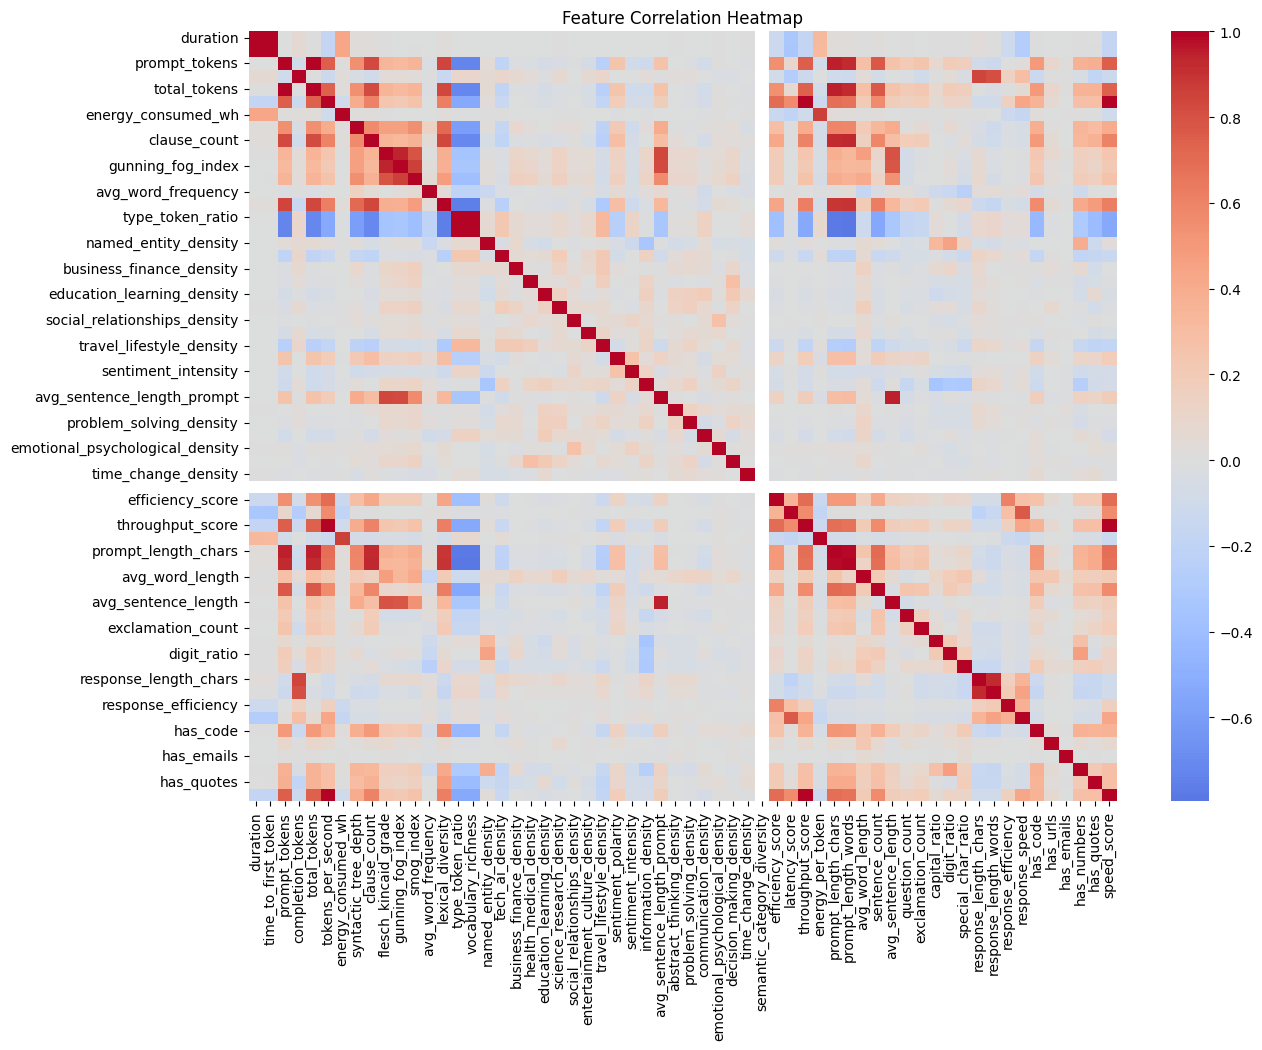

In [ ]:
# Visualize full correlation heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

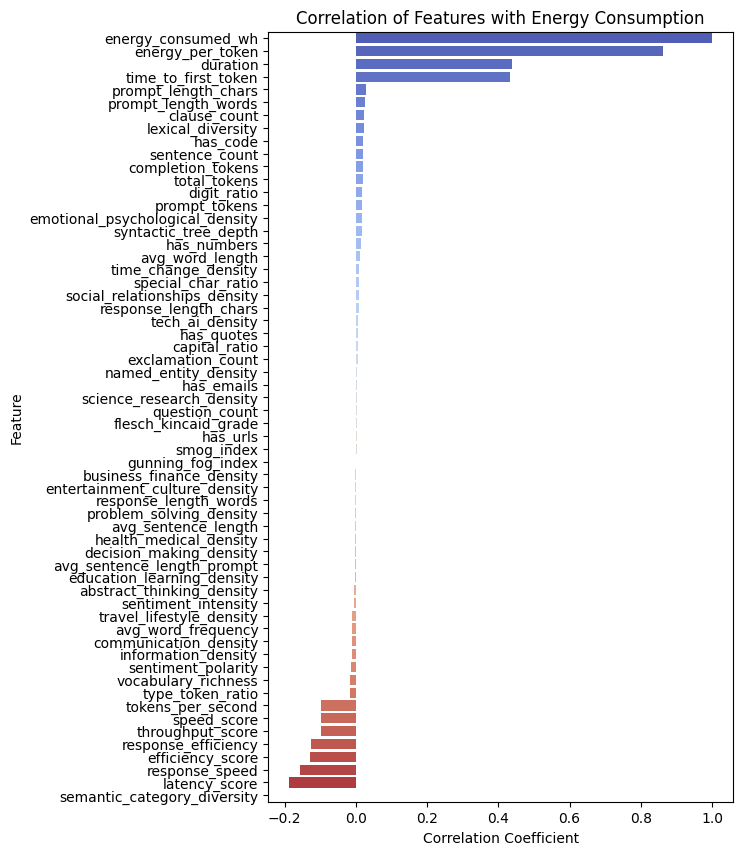

In [ ]:
# Visualize correlations specifically with energy consumption
energy_corr = corr["energy_consumed_wh"].sort_values(ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(x=energy_corr.values, y=energy_corr.index, palette="coolwarm")
plt.title("Correlation of Features with Energy Consumption")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()


## 11. Statistical Summaries


In [ ]:
# Summary statistics for key numeric features
data.select_dtypes(include=["number"]).describe()


,duration,time_to_first_token,prompt_tokens,completion_tokens,total_tokens,tokens_per_second,energy_consumed_wh,syntactic_tree_depth,clause_count,flesch_kincaid_grade,...,response_length_chars,response_length_words,response_efficiency,response_speed,has_code,has_urls,has_emails,has_numbers,has_quotes,speed_score
count,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,...,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000,20709.000000
mean,1.410409,1.407245,83.428992,45.168574,128.597566,152.426790,0.034287,5.563282,6.738809,7.772531,...,202.238640,32.107007,4776.449253,35.658149,0.254962,0.004056,0.000290,0.454585,0.312763,152.426790
std,2.678725,2.670026,118.680900,11.942494,118.146595,182.004568,0.132695,3.049273,11.922437,7.258165,...,65.792528,10.305763,7807.719819,25.469997,0.435850,0.063561,0.017019,0.497945,0.463630,182.004568
min,0.270000,0.271000,8.000000,1.000000,13.000000,1.400000,0.000100,1.000000,0.000000,-2.620000,...,1.000000,1.000000,0.694830,0.010039,0.000000,0.000000,0.000000,0.000000,0.000000,1.400000
25%,0.700000,0.699000,20.000000,50.000000,68.000000,50.900000,0.004800,3.000000,1.000000,3.890270,...,182.000000,29.000000,1335.504886,18.867925,0.000000,0.000000,0.000000,0.000000,0.000000,50.900000
50%,1.070000,1.069000,44.000000,50.000000,92.000000,85.100000,0.008400,5.000000,2.000000,6.960000,...,218.000000,35.000000,3474.576271,28.985507,0.000000,0.000000,0.000000,0.000000,0.000000,85.100000
75%,1.510000,1.511000,79.000000,50.000000,124.000000,206.000000,0.019700,7.000000,6.000000,10.315634,...,244.000000,39.000000,6406.250000,42.553191,1.000000,0.000000,0.000000,1.000000,1.000000,206.000000
max,298.840000,298.836000,1721.000000,50.000000,1771.000000,2900.400000,4.165300,73.000000,102.000000,184.705641,...,818.000000,49.000000,450000.000000,128.571429,1.000000,1.000000,1.000000,1.000000,1.000000,2900.400000


In [ ]:
# Model-wise summary statistics for energy consumption and token usage
data.groupby("model")[["energy_consumed_wh", "duration", "tokens_per_second", "total_tokens"]].describe()


energy_consumed_wh                                      \
                                    count      mean       std     min     25%   
model                                                                           
gpt-4o-mini-2024-07-18             6902.0  0.035223  0.077673  0.0001  0.0059   
llama-3.1-8b-instant               6903.0  0.015528  0.036513  0.0001  0.0032   
mistral-large-latest               6904.0  0.052107  0.211628  0.0001  0.0074   

                                               duration            ...  \
                           50%     75%     max    count      mean  ...   
model                                                              ...   
gpt-4o-mini-2024-07-18  0.0094  0.0204  2.1108   6902.0  1.369587  ...   
llama-3.1-8b-instant    0.0045  0.0095  1.2799   6903.0  0.628898  ...   
mistral-large-latest    0.0121  0.0284  4.1653   6904.0  2.232617  ...   

                       tokens_per_second         total_tokens              \
                                     75%     max        count        mean   
model                                                                       
gpt-4o-mini-2024-07-18             97.50  1330.1       6902.0  116.774993   
llama-3.1-8b-instant              287.75  2900.4       6903.0  147.363465   
mistral-large-latest               79.20  1369.5       6904.0  121.653534   

                                                                      
                               std   min   25%    50%    75%     max  
model                                                                 
gpt-4o-mini-2024-07-18  112.628476  16.0  66.0   75.0  110.0  1370.0  
llama-3.1-8b-instant    115.890523  43.0  94.0  103.0  141.0  1411.0  
mistral-large-latest    123.383658  13.0  64.0   75.0  112.0  1771.0  

[3 rows x 32 columns]

In [ ]:
# Average performance metrics per model
data.groupby("model")[["energy_consumed_wh", "duration", "tokens_per_second", "total_tokens"]].mean()


,energy_consumed_wh,duration,tokens_per_second,total_tokens
model,,,,
gpt-4o-mini-2024-07-18,0.035223,1.369587,106.649406,116.774993
llama-3.1-8b-instant,0.015528,0.628898,270.510648,147.363465
mistral-large-latest,0.052107,2.232617,80.124160,121.653534


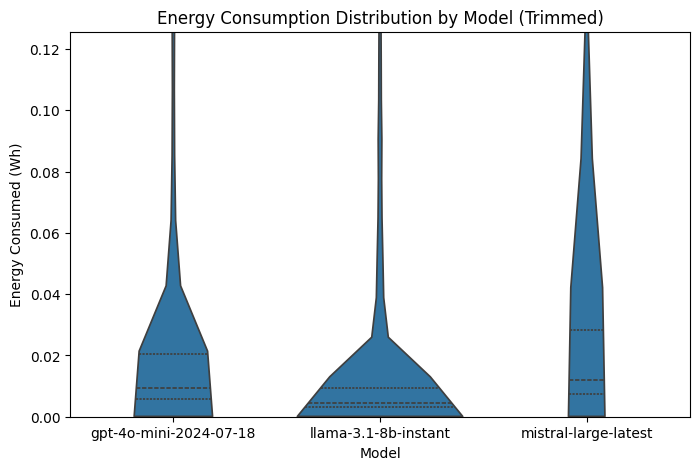

In [ ]:
# Visualize model-wise energy consumption distribution
plt.figure(figsize=(20, 5))
sns.violinplot(x="model", y="energy_consumed_wh", data=data, inner="quartile", cut=0)
plt.ylim(0, data["energy_consumed_wh"].quantile(0.95))  # cap at 95th percentile
plt.title("Energy Consumption Distribution by Model (Trimmed)")
plt.xlabel("Model")
plt.ylabel("Energy Consumed (Wh)")
plt.show()


In [ ]:
# Compare model efficiency (energy per token)
data["energy_per_token"] = data["energy_consumed_wh"] / data["total_tokens"]
data.groupby("model")["energy_per_token"].mean().sort_values()


model
llama-3.1-8b-instant      0.000137
gpt-4o-mini-2024-07-18    0.000434
mistral-large-latest      0.000599
Name: energy_per_token, dtype: float64

## 12. Key Insights and Patterns


In [ ]:
# Identify and document key insights about energy-efficient and energy-intensive prompt characteristics

# Lowest and highest energy-consuming prompts
display("Lowest Energy Prompts")
display(data.nsmallest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]])

display("Highest Energy Prompts")
display(data.nlargest(10, "energy_consumed_wh")[["prompt", "model", "energy_consumed_wh", "total_tokens"]])

# Compare mean feature values for low vs high energy groups
low_energy_group = data[data["energy_consumed_wh"] <= data["energy_consumed_wh"].quantile(0.25)]
high_energy_group = data[data["energy_consumed_wh"] >= data["energy_consumed_wh"].quantile(0.75)]

energy_feature_comparison = (
    pd.DataFrame({
        "Low Energy Mean": low_energy_group.mean(numeric_only=True),
        "High Energy Mean": high_energy_group.mean(numeric_only=True),
        "Difference": high_energy_group.mean(numeric_only=True) - low_energy_group.mean(numeric_only=True)
    })
    .sort_values("Difference", ascending=False)
)

display("Feature Comparison (Low vs High Energy)")
display(energy_feature_comparison)

# Correlation analysis for energy consumption
energy_corr = data.corr(numeric_only=True)["energy_consumed_wh"].sort_values(ascending=False)
display("Top Positive Correlations with Energy Consumption")
display(energy_corr.head(10))

display("Top Negative Correlations with Energy Consumption")
display(energy_corr.tail(10))


'Lowest Energy Prompts'

,prompt,model,energy_consumed_wh,total_tokens
983,what do you recommend to reduce bags under eyes,mistral-large-latest,0.0001,62
4238,Write an introduction of Fanzhi Pharmacy with ...,mistral-large-latest,0.0001,77
9087,et sur NAME_5 forêt ?,gpt-4o-mini-2024-07-18,0.0001,64
10228,How can I increase the stability of my perfume,llama-3.1-8b-instant,0.0001,94
18551,"Can you make the story longer, and include mor...",mistral-large-latest,0.0001,67
20497,They are a movie star. Proceed to question 2. ...,llama-3.1-8b-instant,0.0001,98
8512,"why ChatGLM data only stops at 2021, same as C...",llama-3.1-8b-instant,0.0002,103
11166,How can I configure Google Oauth to automatica...,gpt-4o-mini-2024-07-18,0.0002,75
16443,how much money would i need to invest in order...,gpt-4o-mini-2024-07-18,0.0002,88
20496,They are a movie star. Proceed to question 2. ...,gpt-4o-mini-2024-07-18,0.0004,65


'Highest Energy Prompts'

,prompt,model,energy_consumed_wh,total_tokens
15203,reword as one sentence: Sprout biomass increas...,mistral-large-latest,4.1653,135
17738,search for errors on my code: --Persistencia d...,mistral-large-latest,3.3750,1009
17963,You are MedicalControllerGPT. You analyze doct...,mistral-large-latest,3.2474,379
20636,type an email congratulating the CEO of a part...,mistral-large-latest,3.0095,67
20222,"In this activity, you’ll be asked a series of ...",mistral-large-latest,2.9756,279
16826,"I am reading a how-to page describing ""How to ...",mistral-large-latest,2.6911,108
14771,Do you know any famouse Slovenian?,mistral-large-latest,2.6072,62
18800,"""Eh, you've never used one before?"", said NAME...",mistral-large-latest,2.5488,73
20306,So it okay to talk about pain like that ?,mistral-large-latest,2.4896,63
16973,You are Brotherhood of NAME_1 from Fallout New...,mistral-large-latest,2.3730,67


'Feature Comparison (Low vs High Energy)'

,Low Energy Mean,High Energy Mean,Difference
response_length_chars,184.681182,206.605446,21.924264
completion_tokens,41.264915,46.390112,5.125197
response_length_words,30.028391,32.492082,2.463691
duration,0.653773,2.444208,1.790435
time_to_first_token,0.652210,2.435502,1.783292
energy_consumed_wh,0.003347,0.114858,0.111511
exclamation_count,0.079800,0.091927,0.012127
sentiment_polarity,0.156255,0.166940,0.010685
type_token_ratio,0.887169,0.891576,0.004407
vocabulary_richness,0.887168,0.891575,0.004407


'Top Positive Correlations with Energy Consumption'

energy_consumed_wh     1.000000
energy_per_token       0.863441
duration               0.437237
time_to_first_token    0.433325
prompt_length_chars    0.027317
prompt_length_words    0.024429
clause_count           0.022093
lexical_diversity      0.021775
has_code               0.019750
sentence_count         0.019455
Name: energy_consumed_wh, dtype: float64

'Top Negative Correlations with Energy Consumption'

vocabulary_richness           -0.016818
type_token_ratio              -0.016818
tokens_per_second             -0.097188
speed_score                   -0.097188
throughput_score              -0.097200
response_efficiency           -0.127088
efficiency_score              -0.130158
response_speed                -0.158330
latency_score                 -0.187152
semantic_category_diversity         NaN
Name: energy_consumed_wh, dtype: float64